In [1]:
import os
import pickle
import pprint
import itertools
import pathos
import functools
from functools import partial
from pathlib import Path

import pandas as pd
import numpy as np
from scipy import stats as st
from sklearn.feature_selection import mutual_info_regression as MI

import plotly.graph_objects as go
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

import sys
sys.path.append('/home/leonardo/git/bayesian_bss')
from src import MAPGradientAscentEstimator, MAPGradientAscentGraphPlotter

np.random.seed(2000)

In [2]:
# Whether or not to create folder structure
CREATE_FOLDER_STRUCTURE=True

# Whether or not to save graphs
SAVE_GRAPHS=True

# Whether or not to save source and mixture signals
SAVE_SIGNALS=True

# Whether or not to execute optimization
EXECUTE_OPTIMIZATION=True

# Number of sources and observations
NSOURCES=2
NOBS=1000

# Mixing matrix configuration
# A=np.random.normal(
#     loc=1,
#     scale=0.5,
#     size=(NSOURCES, NSOURCES)
# )
A = np.array([
    [1, 1],
    [-0.5, 0.5]
])

# Execution hyperparameters
N_INITIALIZATIONS = 10
N_WORKERS = os.cpu_count()

# Define initial conditions for optimizations
initial_B = np.random.normal(
    0,1,
    (NSOURCES, NSOURCES, N_INITIALIZATIONS)
)

# MCMC configs
STOPPING_THRESH=0.0005
MAX_IT=100000
LEARNING_RATE=1E-3

# Plot configs
NBINS=20

# Variável para armazenar erros de estimação em cada caso
errors = {
    'perfect_model': {},
    'slightly_misspecified_model': {}
}

In [3]:
# Folder which will contain output directory tree
OUTPUT_DIR='./output'
base_output_path=Path(OUTPUT_DIR)
if not base_output_path.is_dir():
    base_output_path.mkdir()

# Experiment params
EXPERIMENT_NAME='nobs_1k'
EXPERIMENT_DESCRIPTION="""
    Execute experiment with {} observations, deterministic A, stopping thresh {}, max_it {} and learning_rate {}.
""".format(
    NOBS,
    STOPPING_THRESH,
    MAX_IT,
    LEARNING_RATE
)

# Create experiment directory tree, if so specified
experiment_dir = base_output_path / EXPERIMENT_NAME
perfect_model_dir = experiment_dir / 'perfect_model'
slightly_misspecified_model_dir = experiment_dir / 'slightly_misspecified_model'
largely_misspecified_model_dir = experiment_dir / 'largely_misspecified_model'
if CREATE_FOLDER_STRUCTURE:
    if not experiment_dir.is_dir():
        experiment_dir.mkdir()
    if not perfect_model_dir.is_dir():
        perfect_model_dir.mkdir()
    if not slightly_misspecified_model_dir.is_dir():
        slightly_misspecified_model_dir.mkdir()
    if not largely_misspecified_model_dir.is_dir():
        largely_misspecified_model_dir.mkdir()

# Write experiment description
if EXECUTE_OPTIMIZATION:
    with (experiment_dir/'experiment_description.txt').open('w') as f:
        f.write(EXPERIMENT_DESCRIPTION)

# ENSAIO - SEPARAÇÃO DE FONTES POR CRITÉRIO MAP E OTIMIZAÇÃO GRADIENT ASCENT

#### Objetivos:
#### - Verificar o efeito da especificação da distribuição a priori bayesiana (boa ou ruim) sobre ponto de convergência de estimação de matriz de separação;
#### - Verificar o efeito da especificação da distribuição das fontes (boa ou ruim) sobre ponto de convergência de estimação de matriz de separação;

#### Para tal:
####  - Realizam-se otimizações com o objetivo de determinar a matriz de separação, simulando um cenário de separação de fontes.

# Função a ser otimizada (probabilidade a posteriori)

#### De Djafari, 2000
$$ \log P(\boldsymbol{B}|y) = T \log |det({B})| + \sum_{t} \sum_{i} \log p_{i}(y_{i}(t)) + \log P(\boldsymbol{B}) + cte$$

# Equação de otimização (derivada)

#### De Taylor, 2008
$$ \Delta \boldsymbol{B} \varpropto (\boldsymbol{B}^{-1})^{T} + \frac{1}{T} \sum_{T} g(\boldsymbol{Bx}) \boldsymbol{x}^{T} + \frac{1}{T} h(\boldsymbol{B})$$

# 1. PERFECT MODEL

In [4]:
model_dir = perfect_model_dir

## 1.1. Initialize Sources

In [5]:
def source_cumulative(x):
    return 1/(1+np.exp(-x))

def source_pdf(x):
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_generator(
    nsources,
    nobs,
    mu
):
    return np.random.logistic(
        loc=mu,
        scale=1,
        size=(nsources, nobs)
    )

In [6]:
MU=0.0

s = source_generator(
    nsources=NSOURCES,
    nobs=NOBS,
    mu=MU
)

print('-'*100)
print('NÚMERO DE FONTES: {}'.format(NSOURCES))
print('TAMANHO DOS SINAIS DAS FONTES: {}'.format(NOBS))
for i in range(s.shape[0]):
    print(
        'CURTOSE s{}: {}'.format(
            i,
            st.kurtosis(a=s[i,:])
        )
    )
    
print('-'*100)

----------------------------------------------------------------------------------------------------
NÚMERO DE FONTES: 2
TAMANHO DOS SINAIS DAS FONTES: 1000
CURTOSE s0: 1.2678587555753733
CURTOSE s1: 0.6743346318279451
----------------------------------------------------------------------------------------------------


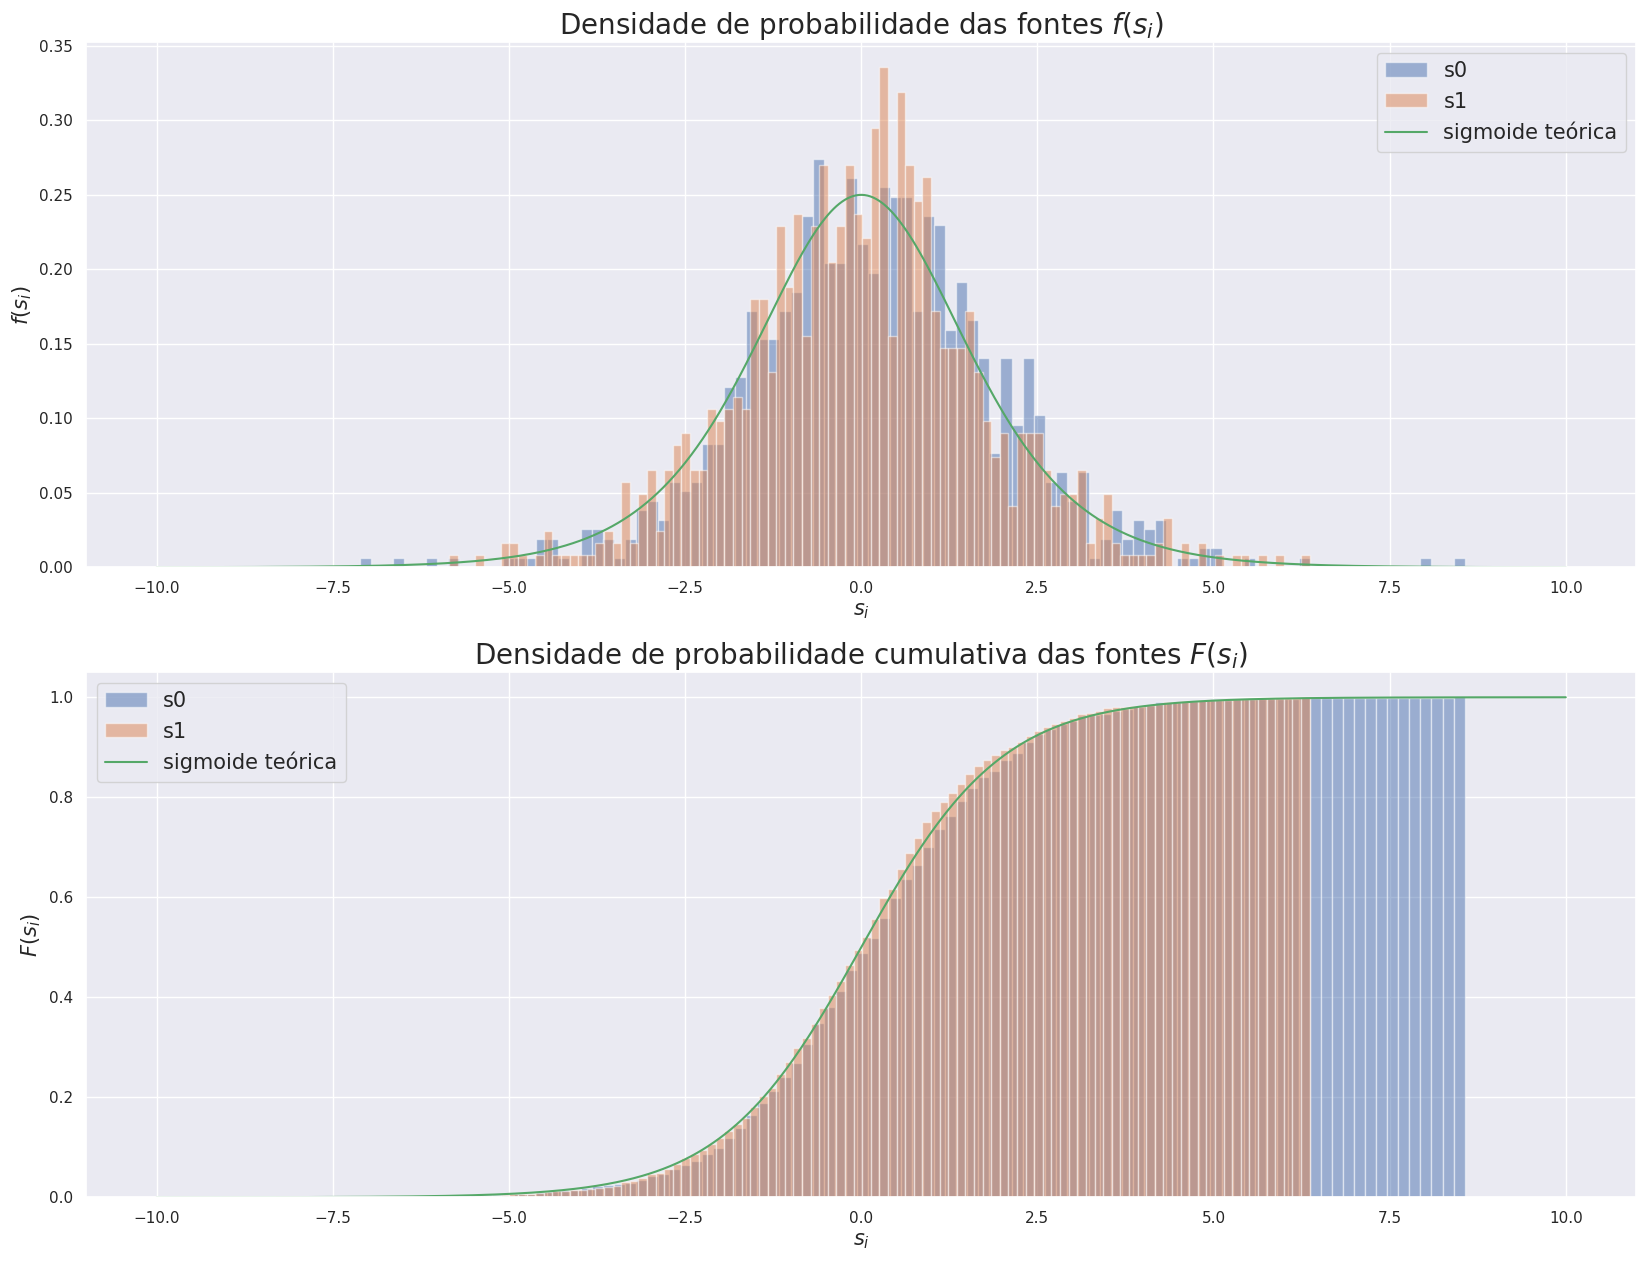

In [7]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)


for i in range(1, NSOURCES+1):
    ax1.hist(
        x=s[i-1,:],
        bins=100,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=s[i-1,:],
        bins=100,
        cumulative=True,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    
ax1.plot(
    np.linspace(-10,10,1000),
    [source_pdf(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)


ax2.plot(
    np.linspace(-10,10,1000),
    [source_cumulative(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)

ax1.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(s_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidade de probabilidade das fontes $f(s_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(s_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidade de probabilidade cumulativa das fontes $F(s_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

## 1.2. Mix sources and generate observations

In [8]:
# Mixing matrix
print('MIXING MATRIX A:')
print(A)

MIXING MATRIX A:
[[ 1.   1. ]
 [-0.5  0.5]]


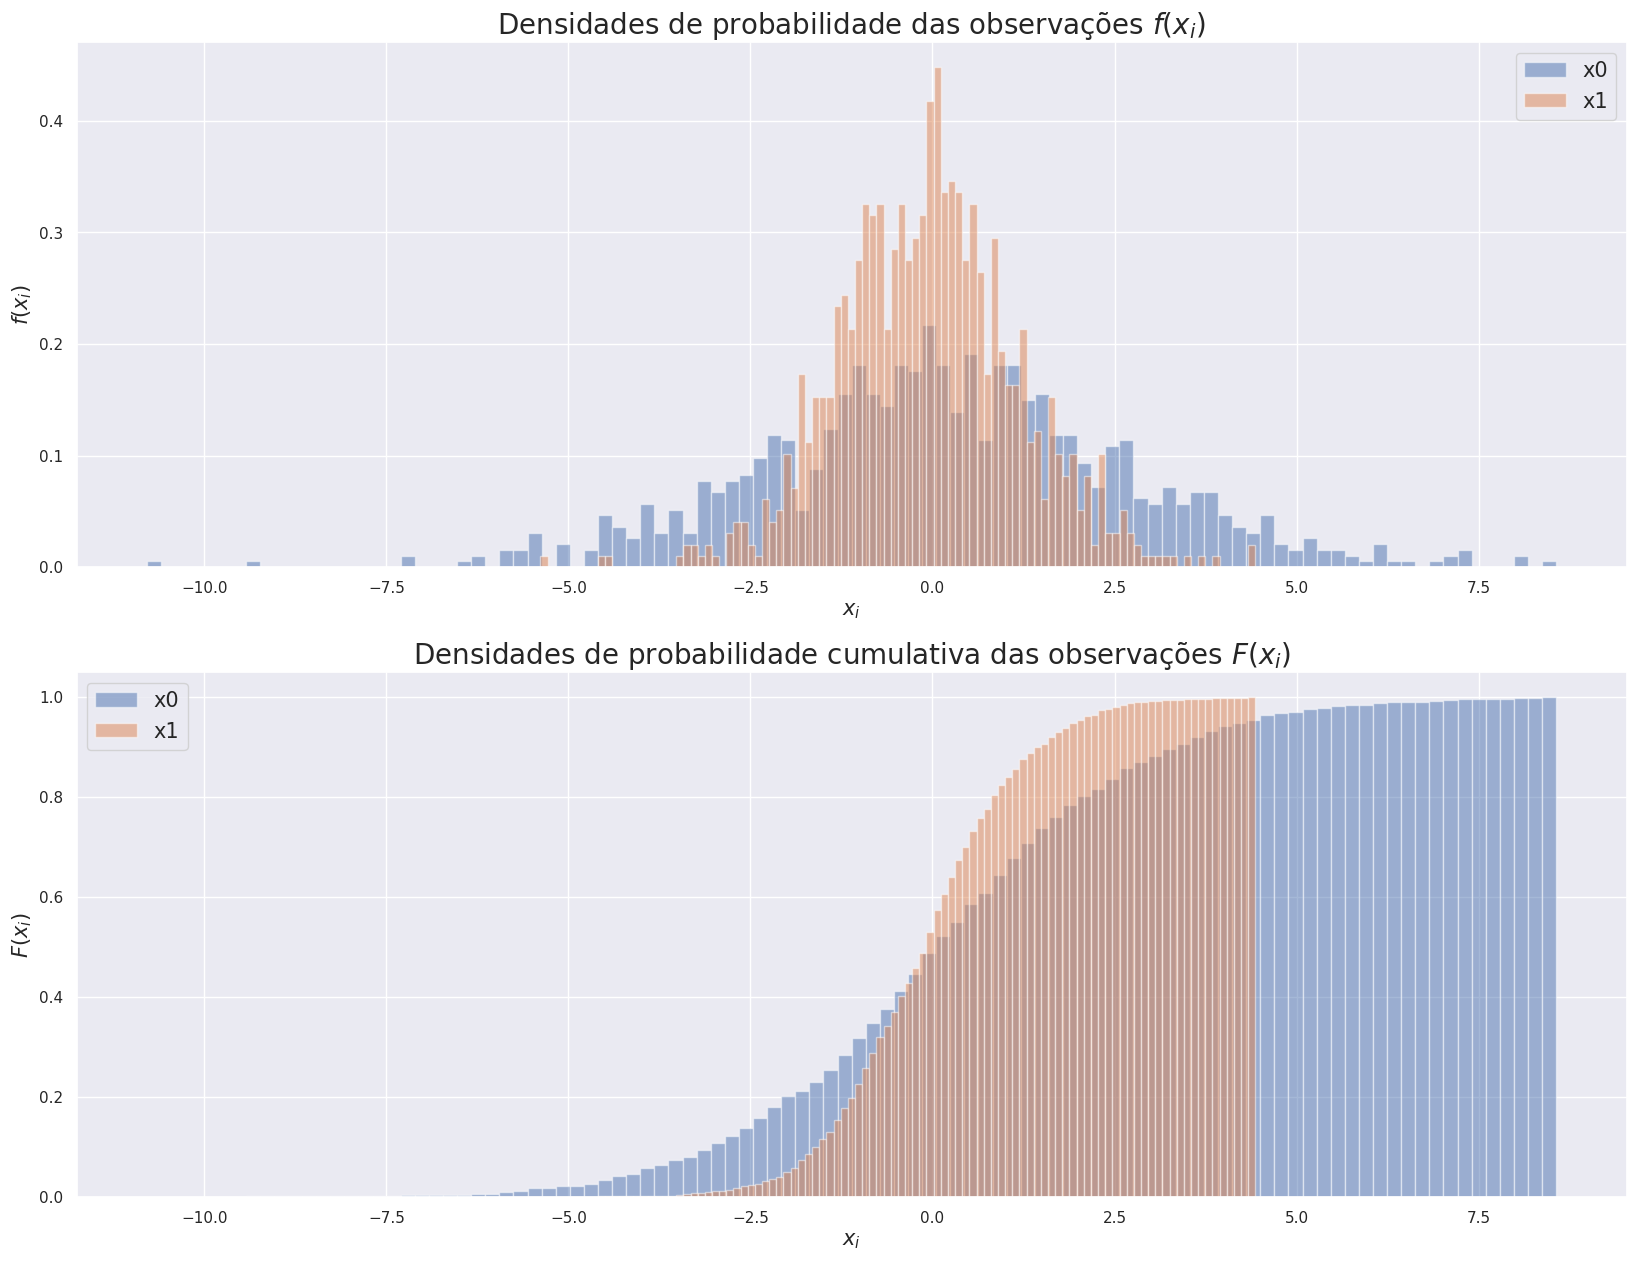

In [9]:
# Observed sources
x = A@s

fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)

for i in range(1, NSOURCES+1):
    ax1.hist(
        x=x[i-1,:],
        bins=100,
        density=True,
        label='x{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=x[i-1,:],
        bins=100,
        cumulative=True,
        density=True,
        label='x{}'.format(i-1),
        alpha=0.5
    )

ax1.set_xlabel(
    '$x_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(x_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidades de probabilidade das observações $f(x_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$x_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(x_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidades de probabilidade cumulativa das observações $F(x_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

In [10]:
signal_save_dir = model_dir / 'signals'
if CREATE_FOLDER_STRUCTURE:
    if not signal_save_dir.is_dir():
        signal_save_dir.mkdir()

if SAVE_SIGNALS:
    with (signal_save_dir / 'sources.pkl').open(mode='wb') as f:
        pickle.dump(s, f)

    with (signal_save_dir / 'mixtures.pkl').open(mode='wb') as f:
        pickle.dump(x, f)

## 1.3. Perform Analysis - LIKELIHOOD

#### Prior:
#### $p(\boldsymbol{B})=cte$

### 1.3.1 Execute Gradient Ascent Optimization

In [11]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))


def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])


def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    return 1

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    return np.zeros(
        shape=X.shape
    )

In [12]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'likelihood'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 260 ms, sys: 89.7 ms, total: 349 ms
Wall time: 9min 48s


/tmp/ipykernel_12038/1139053392.py:5: RuntimeWarning: overflow encountered in square
/home/leonardo/git/bayesian_bss/src/estimator.py:90: RuntimeWarning: divide by zero encountered in log
  posteriori += np.log(source_pdf(y[i,j]))
/home/leonardo/git/bayesian_bss/src/estimator.py:91: RuntimeWarning: divide by zero encountered in log
  posteriori += np.log(prior_pdf(B))
/home/leonardo/git/bayesian_bss/src/estimator.py:70: RuntimeWarning: divide by zero encountered in scalar divide
  deltaB = deltaB + (1/NOBS)*(prior_pdf_derivative(X=B)/prior_pdf(X=B))
/tmp/ipykernel_12038/1139053392.py:11: RuntimeWarning: overflow encountered in exp
/tmp/ipykernel_12038/1139053392.py:11: RuntimeWarning: overflow encountered in square
/tmp/ipykernel_12038/1139053392.py:11: RuntimeWarning: invalid value encountered in scalar subtract
/tmp/ipykernel_12038/1139053392.py:11: RuntimeWarning: overflow encountered in power
/tmp/ipykernel_12038/1139053392.py:11: RuntimeWarning: overflow encountered in scalar mult

### 1.3.2. Parse Optimization Results

In [13]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [14]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[-0.41519597  1.13965314]
 [-0.57859757 -0.88341677]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [15]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-3949.896825090223,
 -3960.200713678092,
 -3959.875466787971,
 -3949.651881624494,
 -3960.691320815295,
 -3960.5134895179685,
 -3960.5639073482366,
 -3949.1231479022963,
 -3956.974818013321,
 -3952.004204654239]

In [16]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 0.37970813,  1.30710399],
        [ 0.605553  , -0.70889247]]),
 array([[ 0.14939017, -1.41161878],
        [-0.69795432, -0.357884  ]]),
 array([[-0.16719255,  1.40586625],
        [-0.68942338, -0.38057437]]),
 array([[ 0.39885494, -1.16389222],
        [ 0.5898785 ,  0.85333695]]),
 array([[ 0.70769743, -0.00605902],
        [-0.03560322, -1.48614922]]),
 array([[-0.70733141,  0.02383394],
        [-0.04479438, -1.48590562]]),
 array([[ 0.03971889,  1.42562215],
        [-0.70749952,  0.01804168]]),
 array([[-0.41519597,  1.13965314],
        [-0.57859757, -0.88341677]]),
 array([[-0.68941048,  0.27280663],
        [ 0.17077014,  1.45520754]]),
 array([[-0.312211  , -1.37561578],
        [ 0.64198852, -0.5790955 ]])]

### 1.3.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


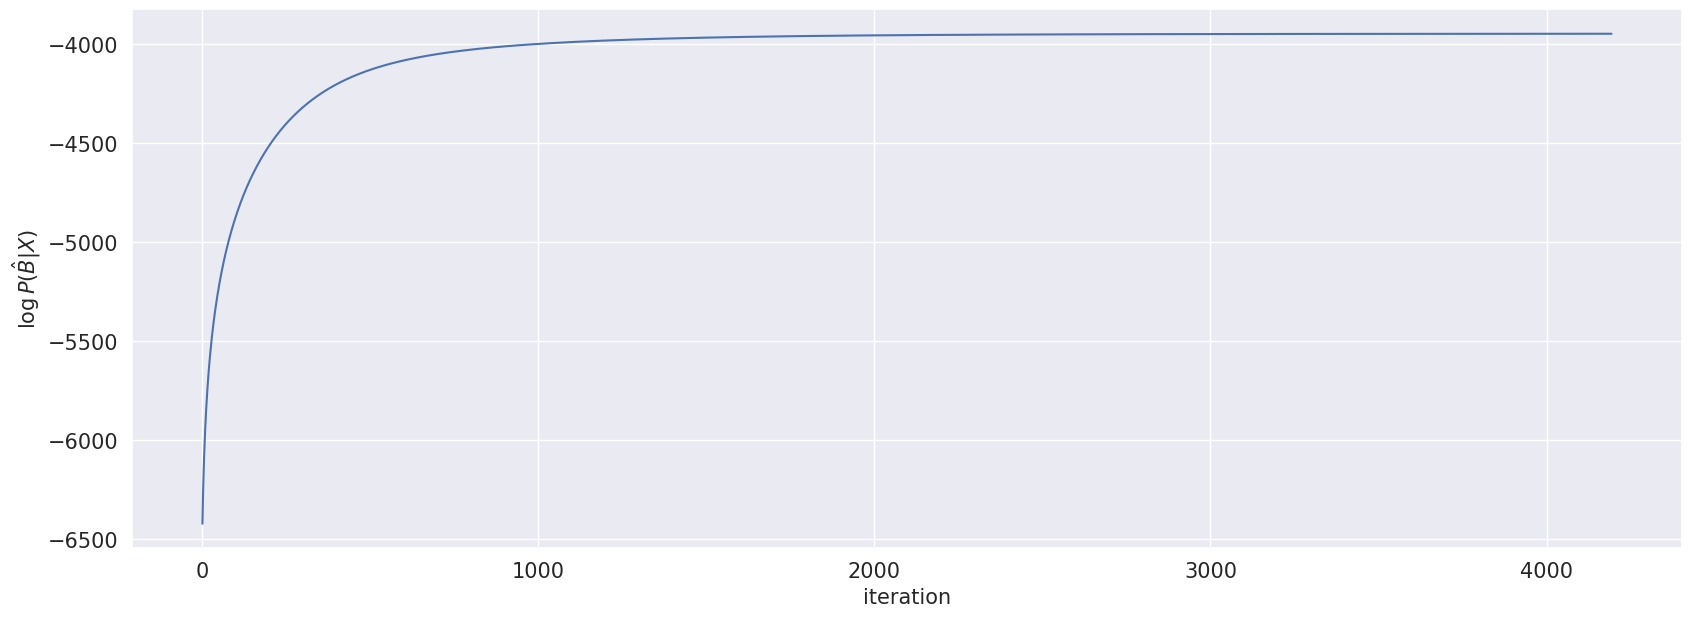

In [17]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 1.3.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


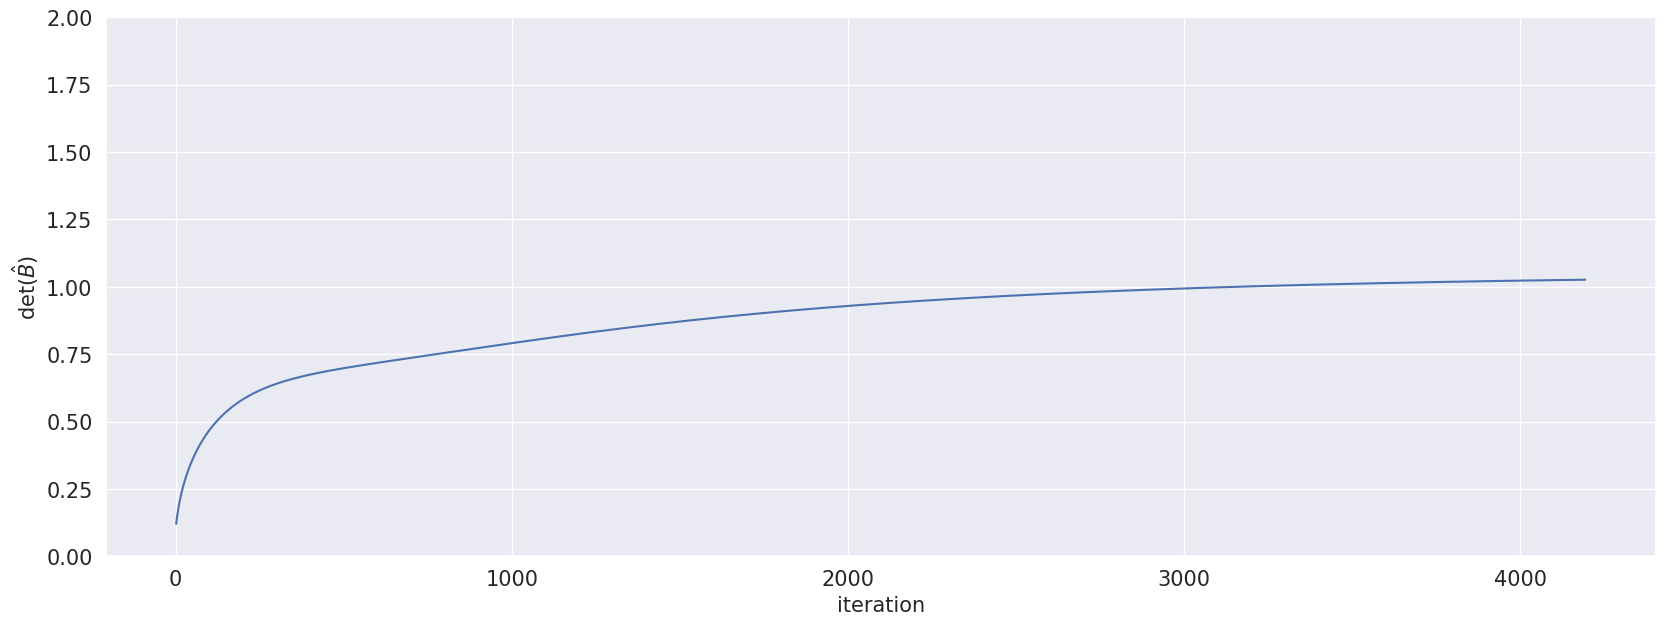

In [18]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=(0,2)
)

### 1.3.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


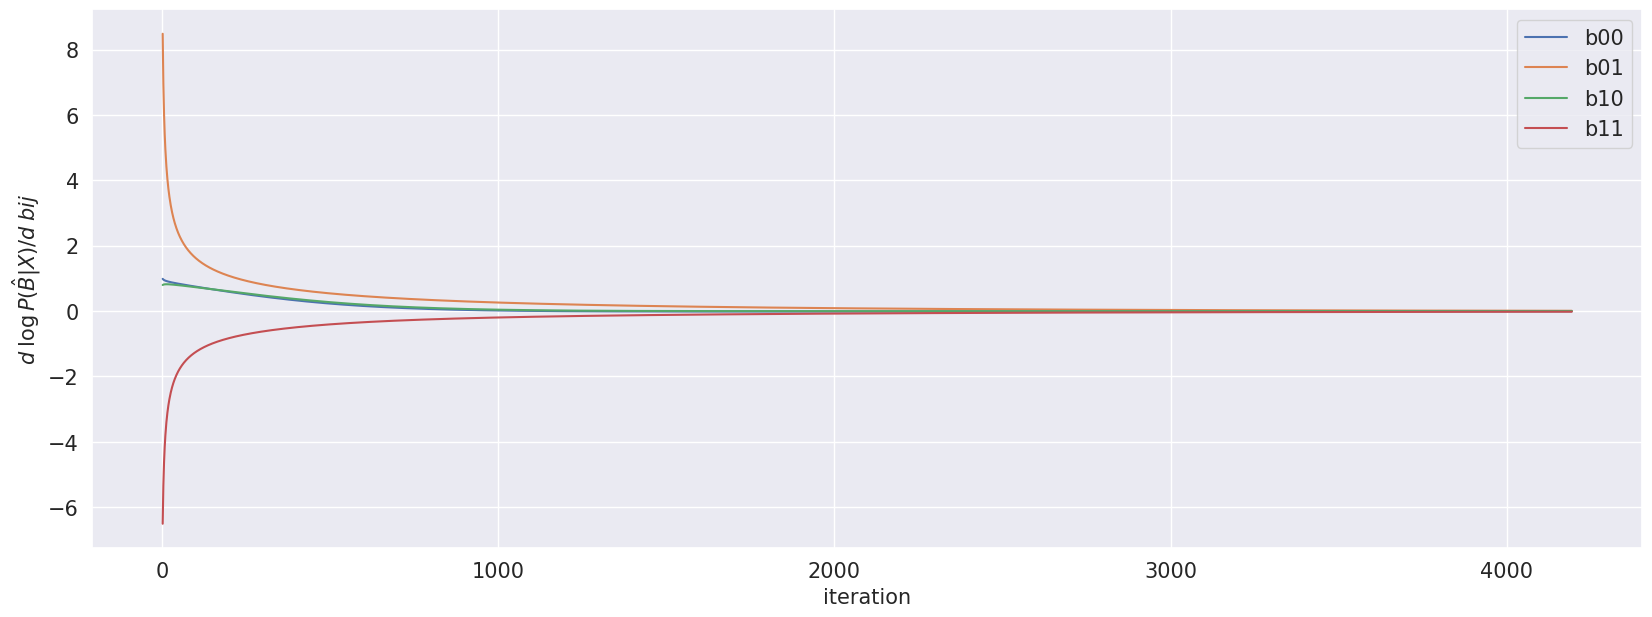

In [19]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 1.3.6. Plot source separation results

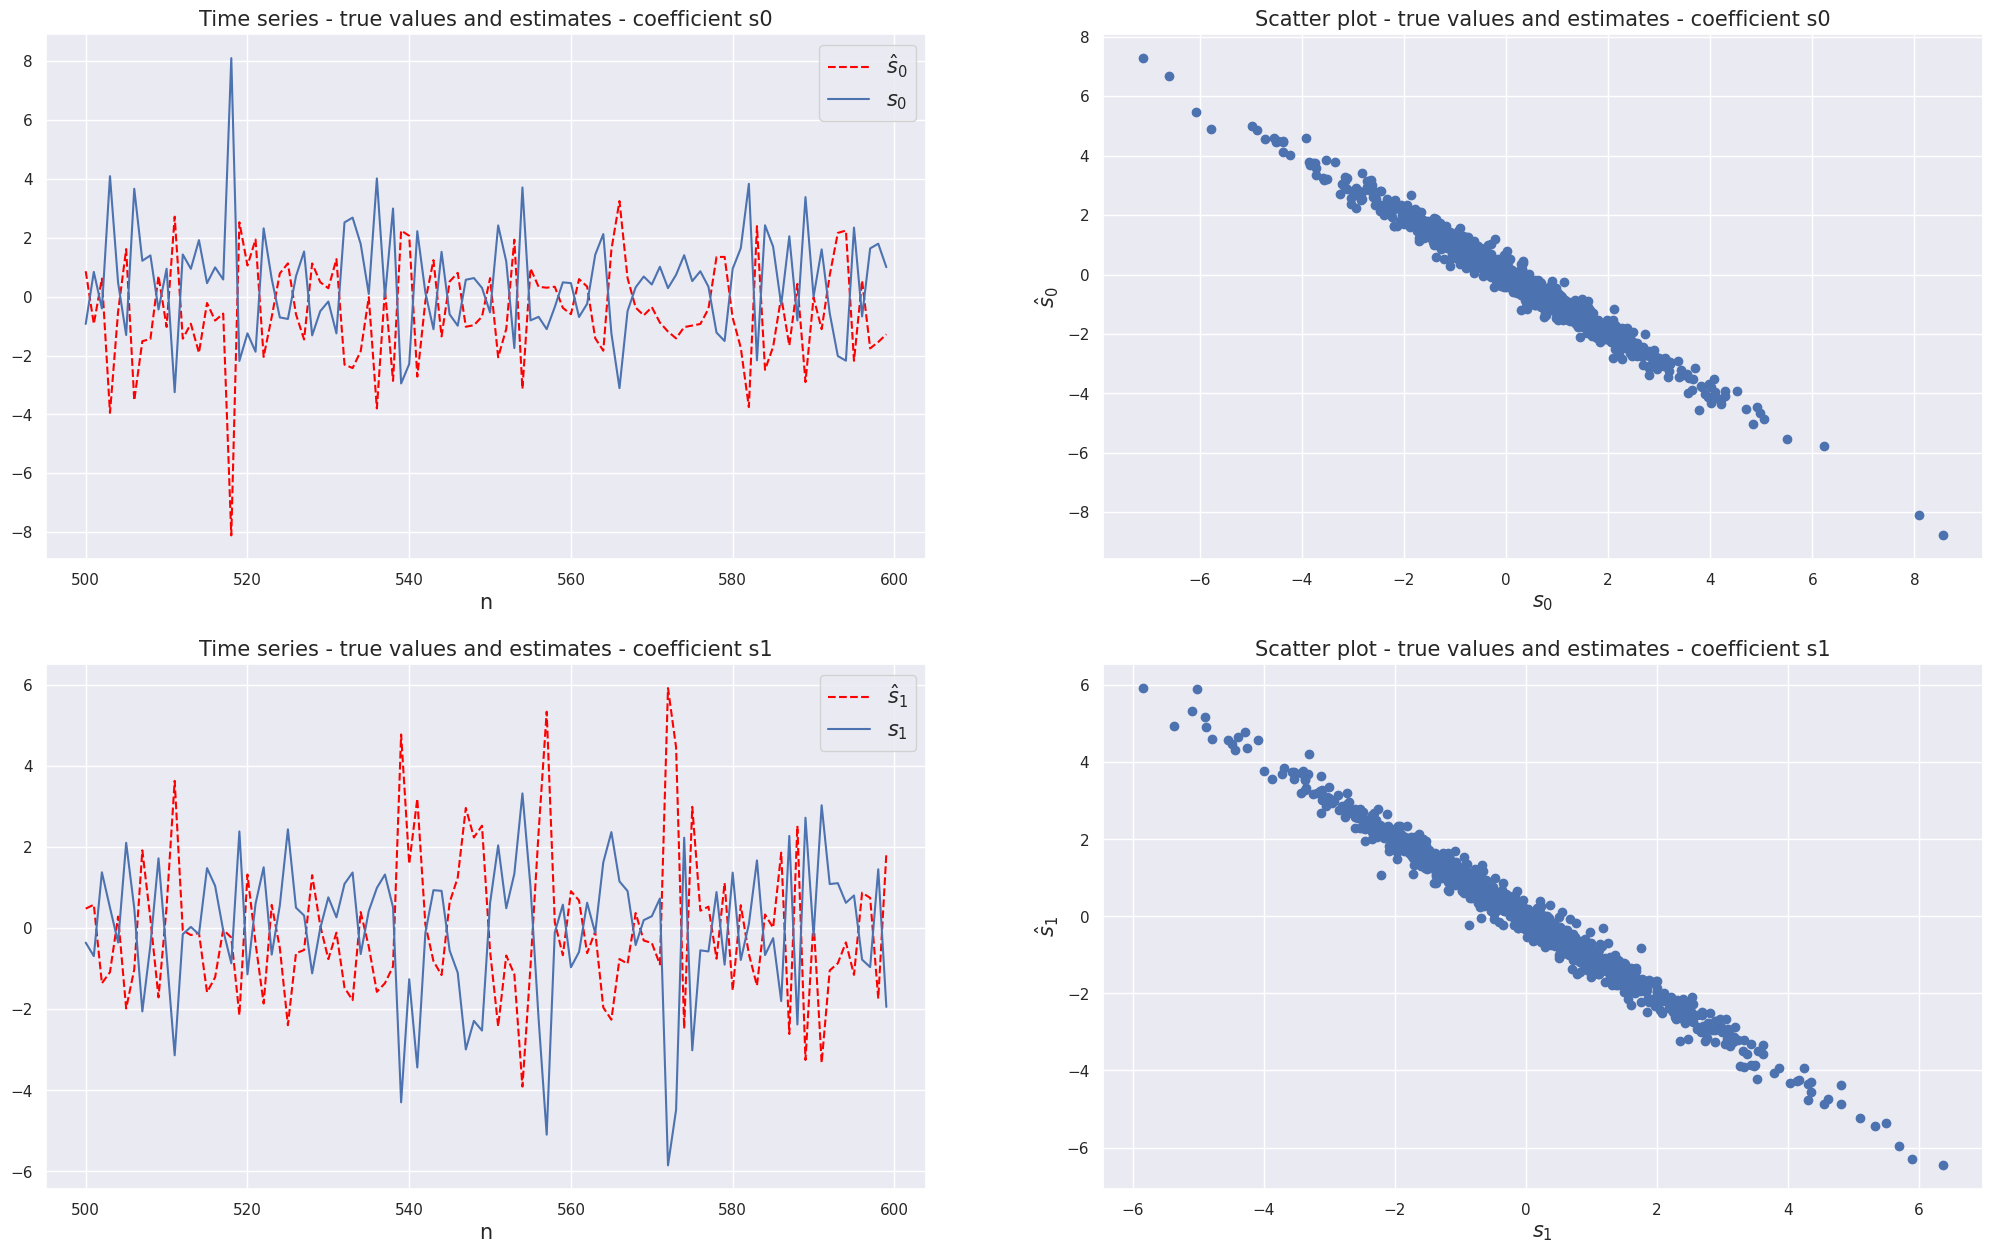

In [20]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [21]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.07904636993913178


## 1.4. Perform Analysis - DETERMINANT PRIOR
#### Prior:
$p(\boldsymbol{B}) \varpropto \exp \left[ -\frac{1}{2 \sigma^{2}} (det(\boldsymbol{B}) - 1)^2 \right]$

### 1.4.1 Execute Gradient Ascent Optimization

In [22]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])

def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    sig=1
    desired_det=1
    return (1/np.sqrt(2*np.pi*np.square(sig)))*np.exp(-np.square(np.linalg.det(X)-desired_det)/(2*np.square(sig)))

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    sig=1
    return -1*prior_pdf(X)*(np.linalg.det(X)-1)/np.square(sig)

In [23]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'determinant_prior'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 303 ms, sys: 24.5 ms, total: 327 ms
Wall time: 10min 5s


### 1.4.2. Parse Optimization Results

In [24]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [25]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[-0.41444901  1.14088568]
 [-0.57914643 -0.88195743]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [26]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-3960.1335016296084,
 -3964.127179707311,
 -3960.7473911588177,
 -3950.566543461546,
 -3964.733423742345,
 -inf,
 -3961.482277076494,
 -3950.06592616856,
 -3957.802850639689,
 -3952.9069718269493]

In [27]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 0.30455245,  1.46380763],
        [ 0.67046902, -0.49552133]]),
 array([[ 0.19819628, -1.3320543 ],
        [-0.66752597, -0.40302457]]),
 array([[-0.16876203,  1.40450418],
        [-0.68907752, -0.38378477]]),
 array([[ 0.39899389, -1.16360724],
        [ 0.58975698,  0.85361353]]),
 array([[ 0.72260883,  0.11541456],
        [ 0.03751483, -1.45790603]]),
 array([[nan, nan],
        [nan, nan]]),
 array([[ 0.03978027,  1.42559153],
        [-0.70749942,  0.01816889]]),
 array([[-0.41444901,  1.14088568],
        [-0.57914643, -0.88195743]]),
 array([[-0.61257379,  0.65157859],
        [ 0.36071332,  1.41929079]]),
 array([[-0.31281575, -1.37518428],
        [ 0.64167382, -0.58026177]])]

### 1.4.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


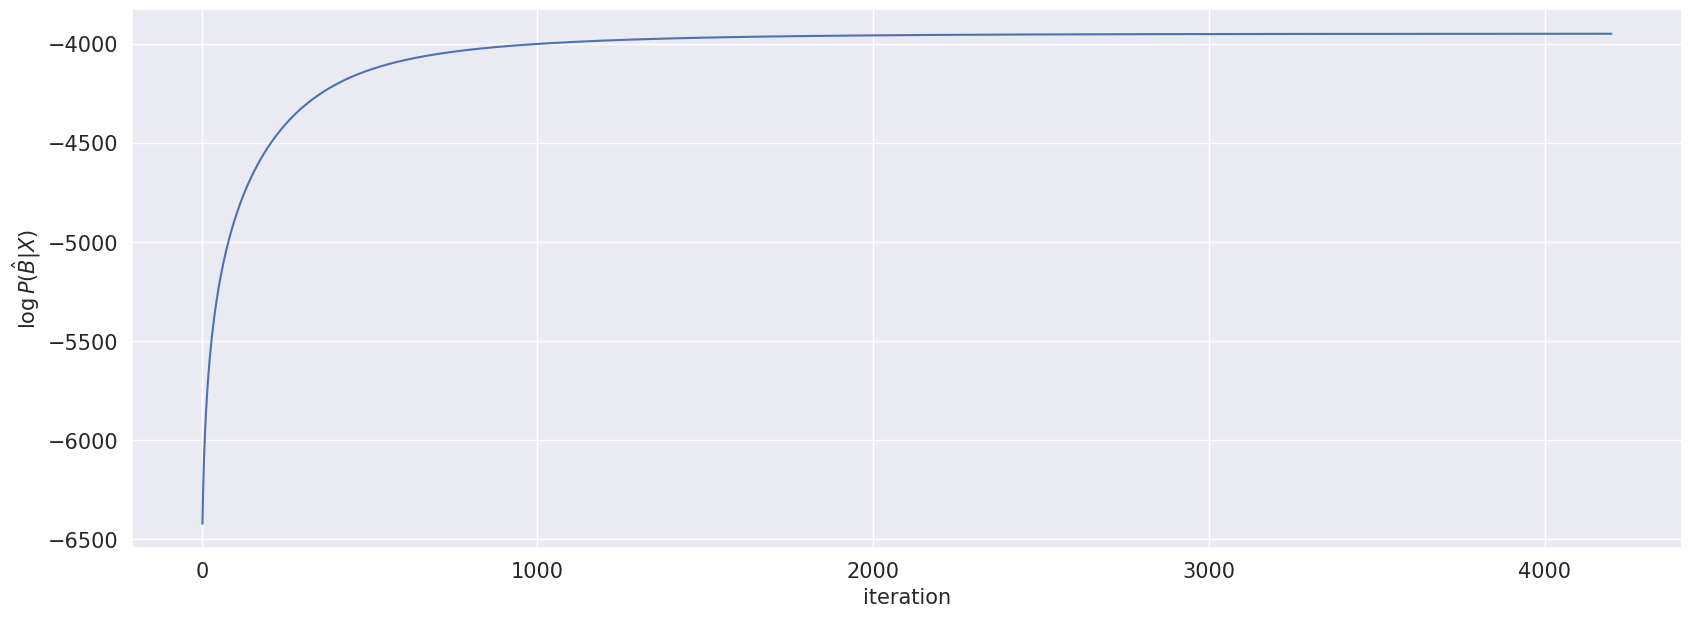

In [28]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 1.4.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


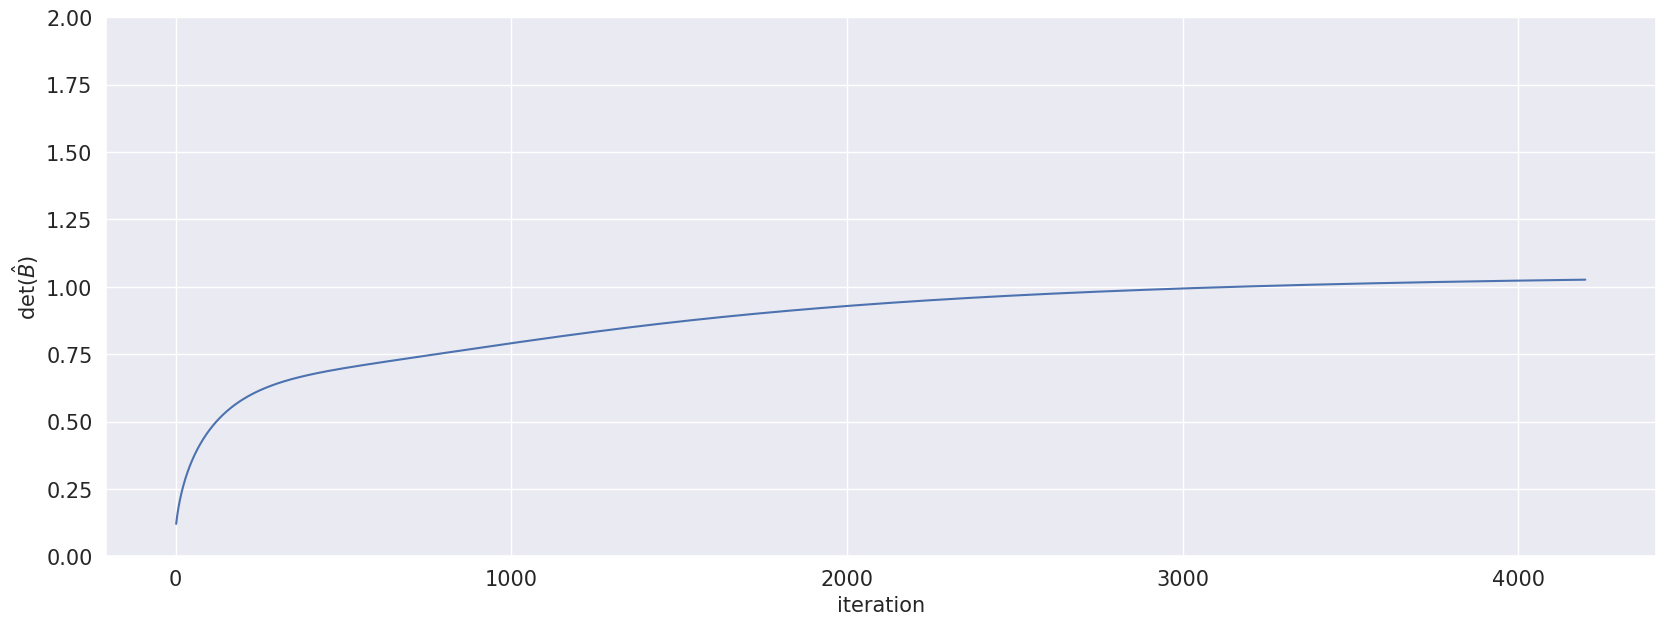

In [29]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=(0,2)
)

### 1.4.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


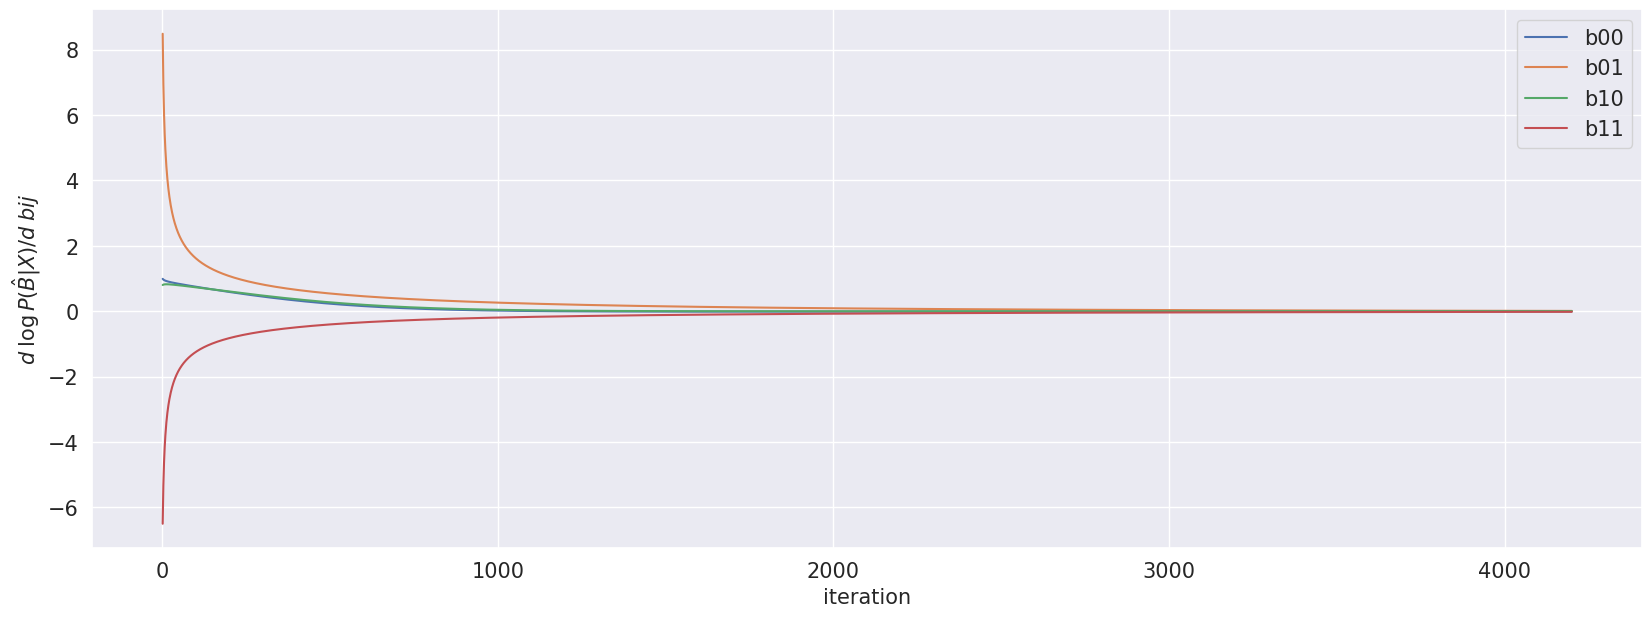

In [30]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 1.4.6. Plot source separation results

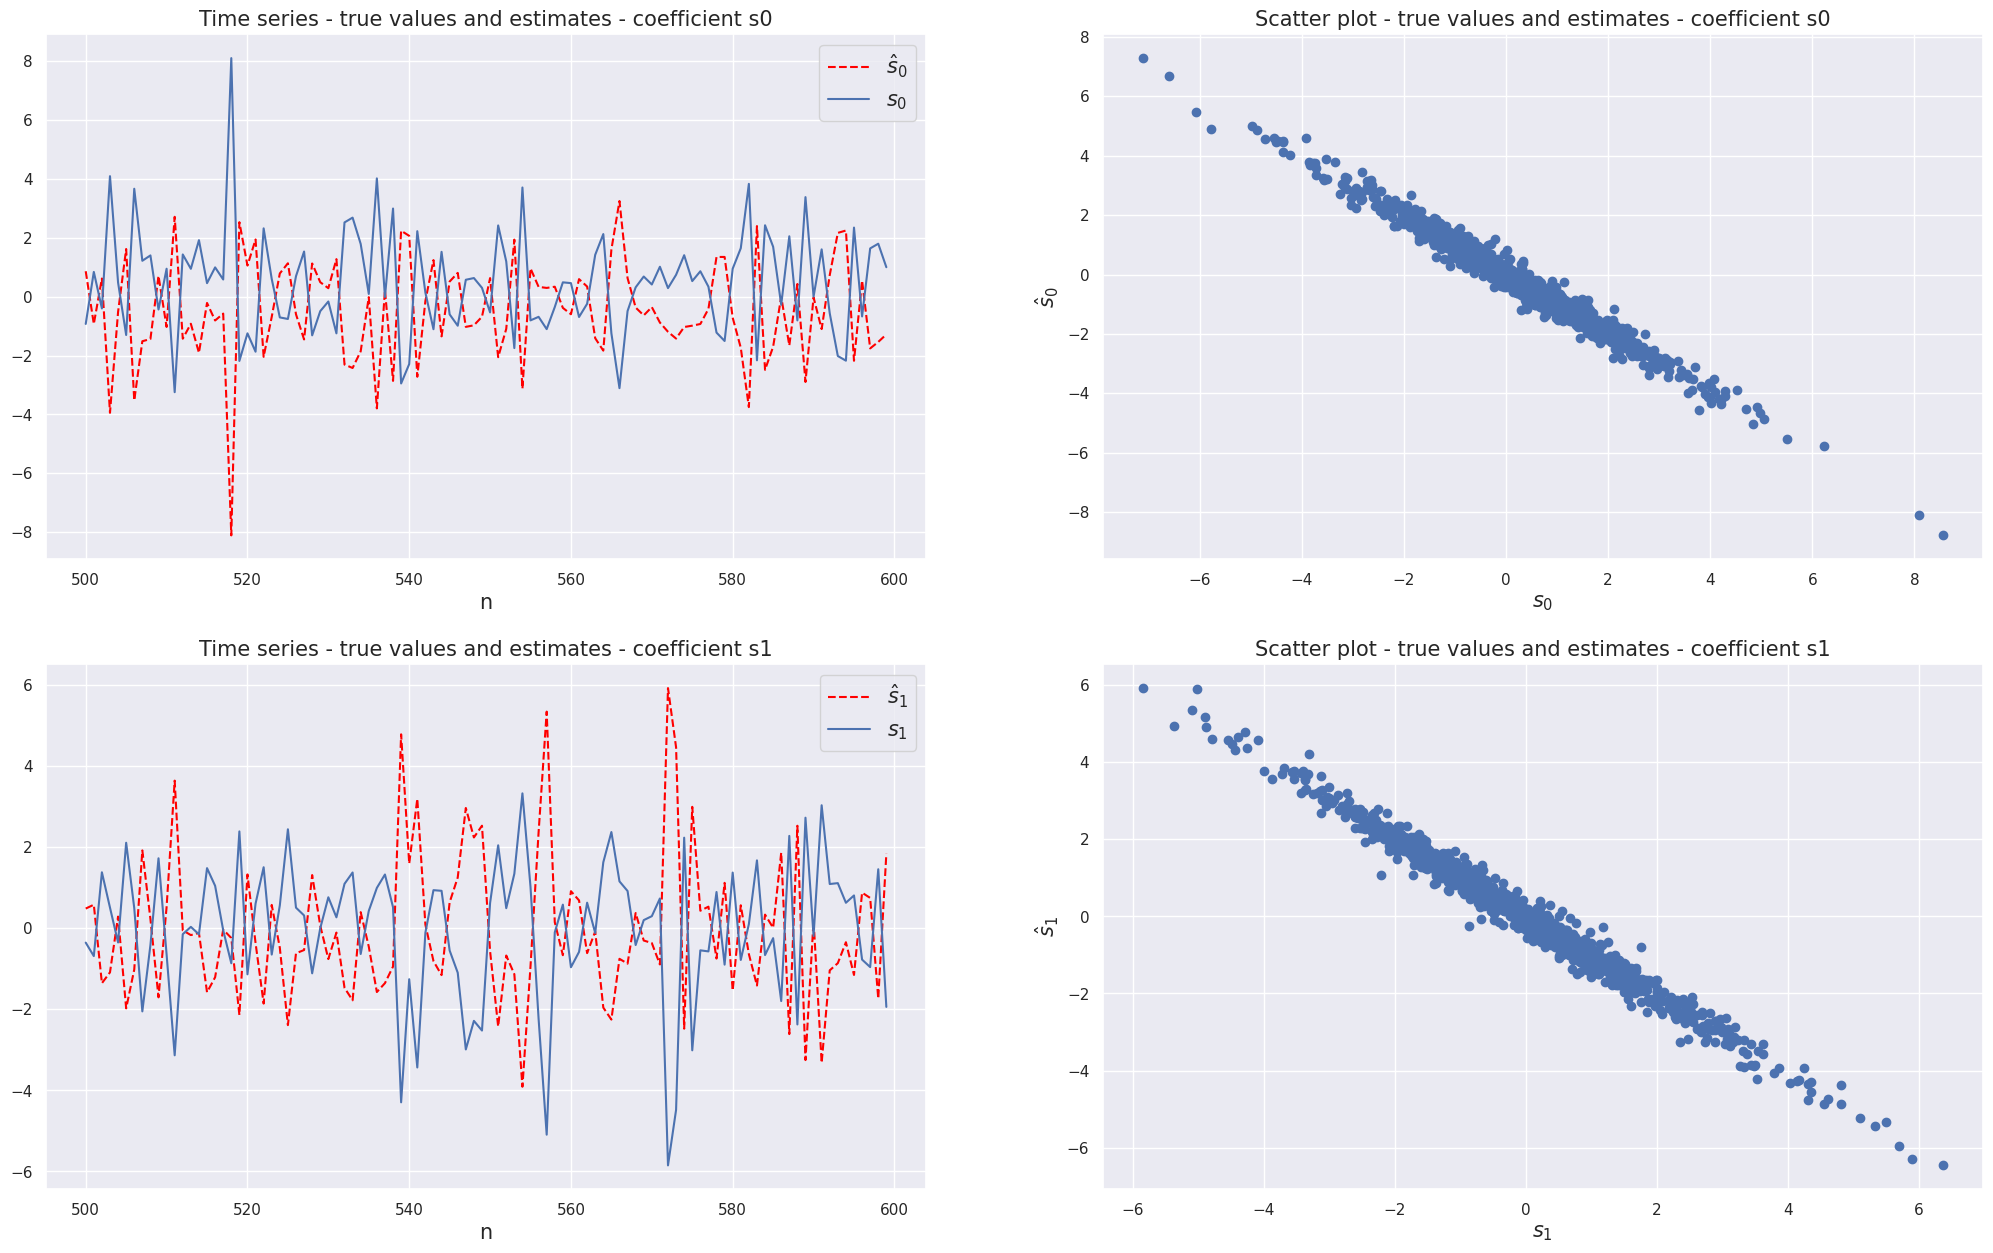

In [31]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [32]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.07904403964698428


## 1.5. Perform Analysis - near-identity transformation
#### Prior:
#### $p(\boldsymbol{B}) \varpropto \exp \left[ -\frac{1}{2 \sigma^{2}} ||\boldsymbol{B} - \boldsymbol{I}||^2 \right]$

### 1.5.1 Execute Gradient Ascent Optimization

In [33]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])

def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    sig=1
    return np.exp(
        (-1/2/np.square(sig))*np.linalg.norm(X-np.eye(X.shape[0]))
    )

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    sig=1
    der_X=np.empty(X.shape)
    I=np.eye(X.shape[0])
    for i, j in np.ndindex(X.shape):
        der_X[i, j] = prior_pdf(X)*(-1/np.square(sig))*(X[i,j]-I[i,j])
    return der_X

In [34]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'identity_transformation'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 325 ms, sys: 26.1 ms, total: 351 ms
Wall time: 9min 37s


### 1.5.2. Parse Optimization Results

In [35]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [36]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[ 0.4026552  -1.1587338 ]
 [ 0.58721966  0.8596695 ]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [37]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-3951.0493863041497,
 -3961.3714741232716,
 -3961.238322092726,
 -3950.250913893775,
 -3961.8421759556104,
 -3961.934325318535,
 -3961.49558495563,
 -3950.8138864442753,
 -3957.8571700996413,
 -3953.507631647229]

In [38]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 0.37946243,  1.30269327],
        [ 0.60489781, -0.70279194]]),
 array([[ 0.14923222, -1.40665469],
        [-0.69747322, -0.35228625]]),
 array([[-0.16138618,  1.40159443],
        [-0.690225  , -0.36703362]]),
 array([[ 0.4026552 , -1.1587338 ],
        [ 0.58721966,  0.8596695 ]]),
 array([[ 0.70807638, -0.00411829],
        [-0.03415794, -1.47980436]]),
 array([[-0.70475776,  0.01929427],
        [-0.04238351, -1.47821305]]),
 array([[ 0.04722152,  1.42413527],
        [-0.70646202,  0.03208305]]),
 array([[-0.40774007,  1.14273681],
        [-0.58142137, -0.86778755]]),
 array([[-0.68799475,  0.27223484],
        [ 0.17061424,  1.45391556]]),
 array([[-0.30337075, -1.37994586],
        [ 0.64454405, -0.56140575]])]

### 1.5.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


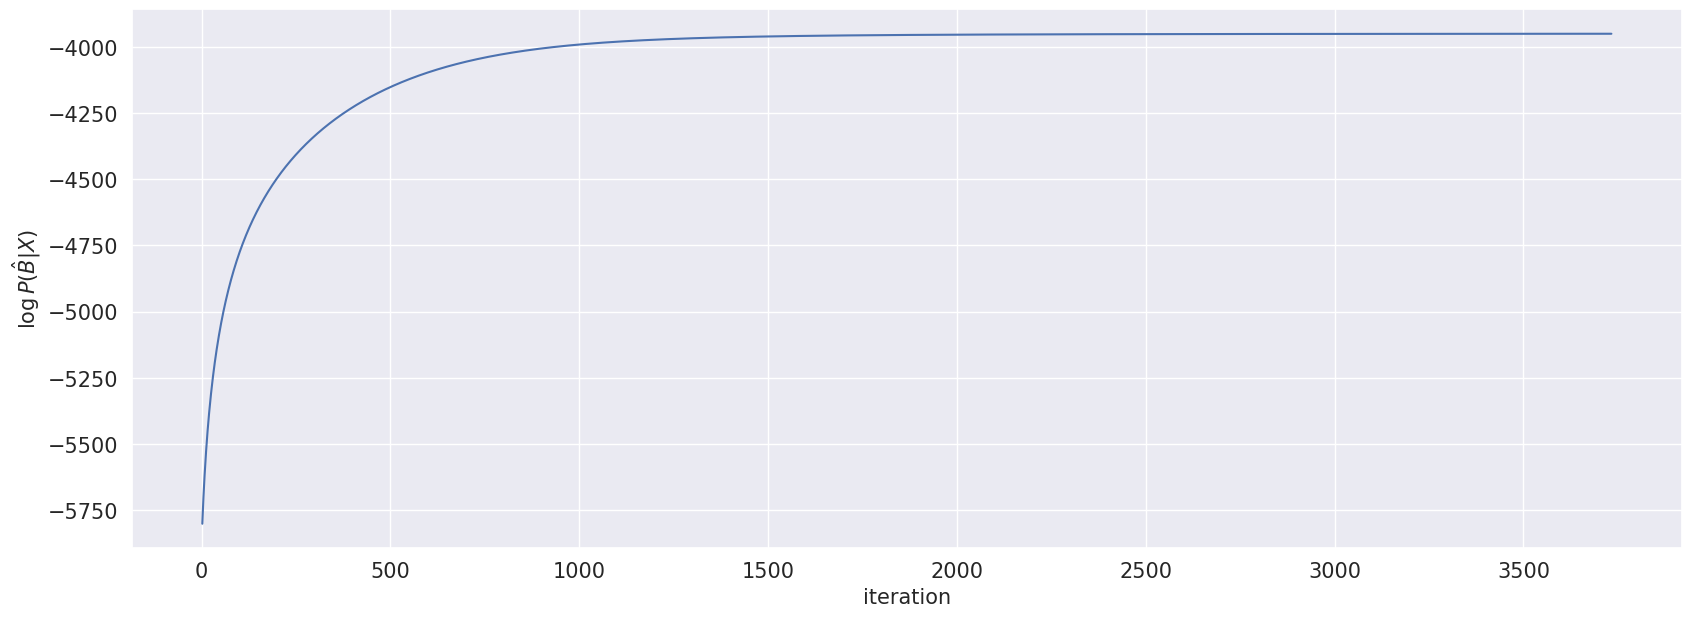

In [39]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 1.5.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


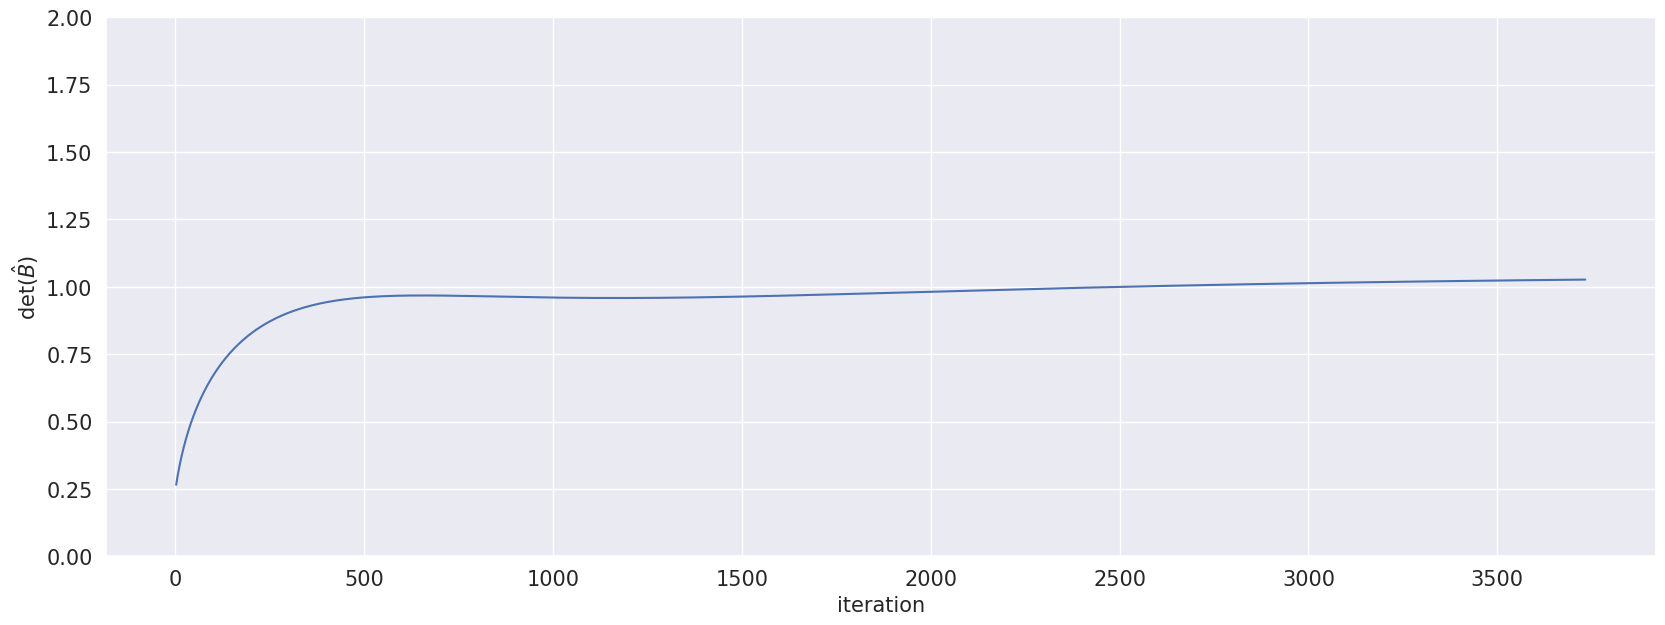

In [40]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=(0,2)
)

### 1.5.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


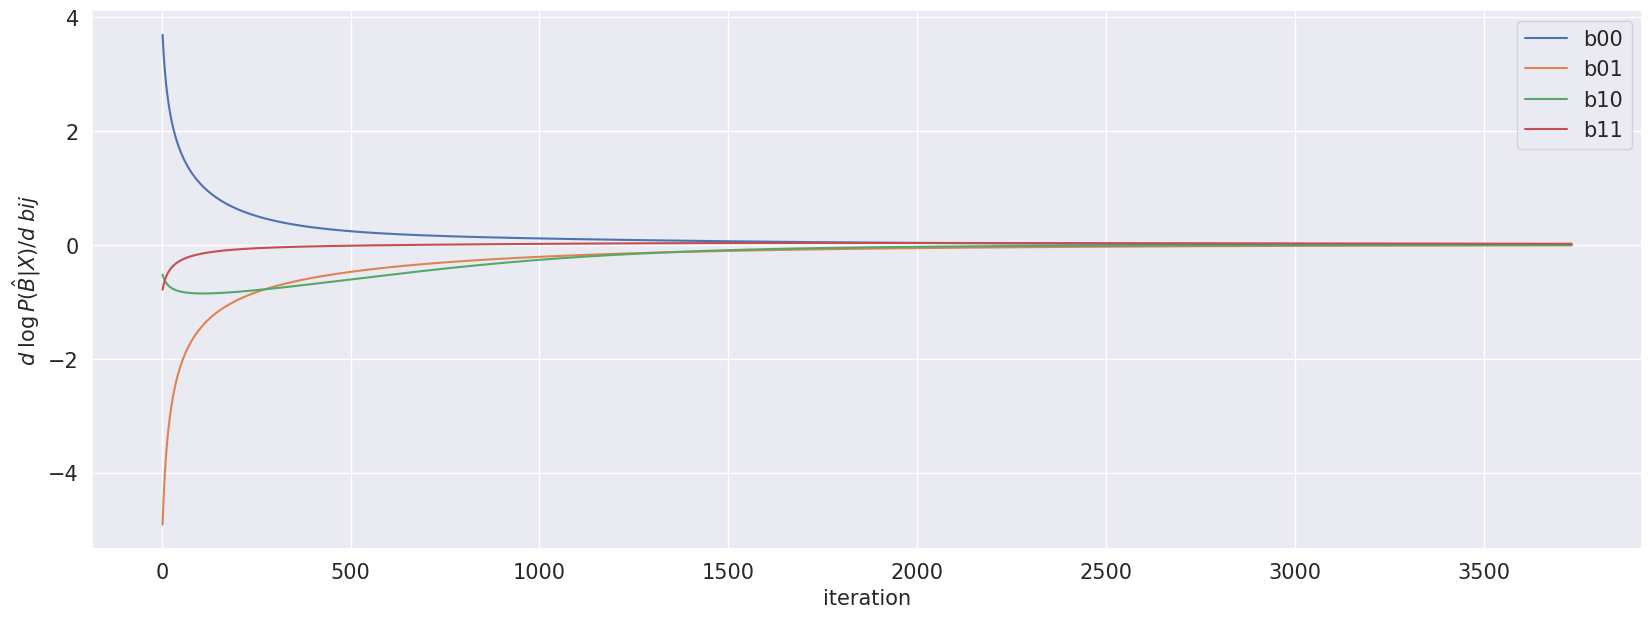

In [41]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 1.5.6. Plot source separation results

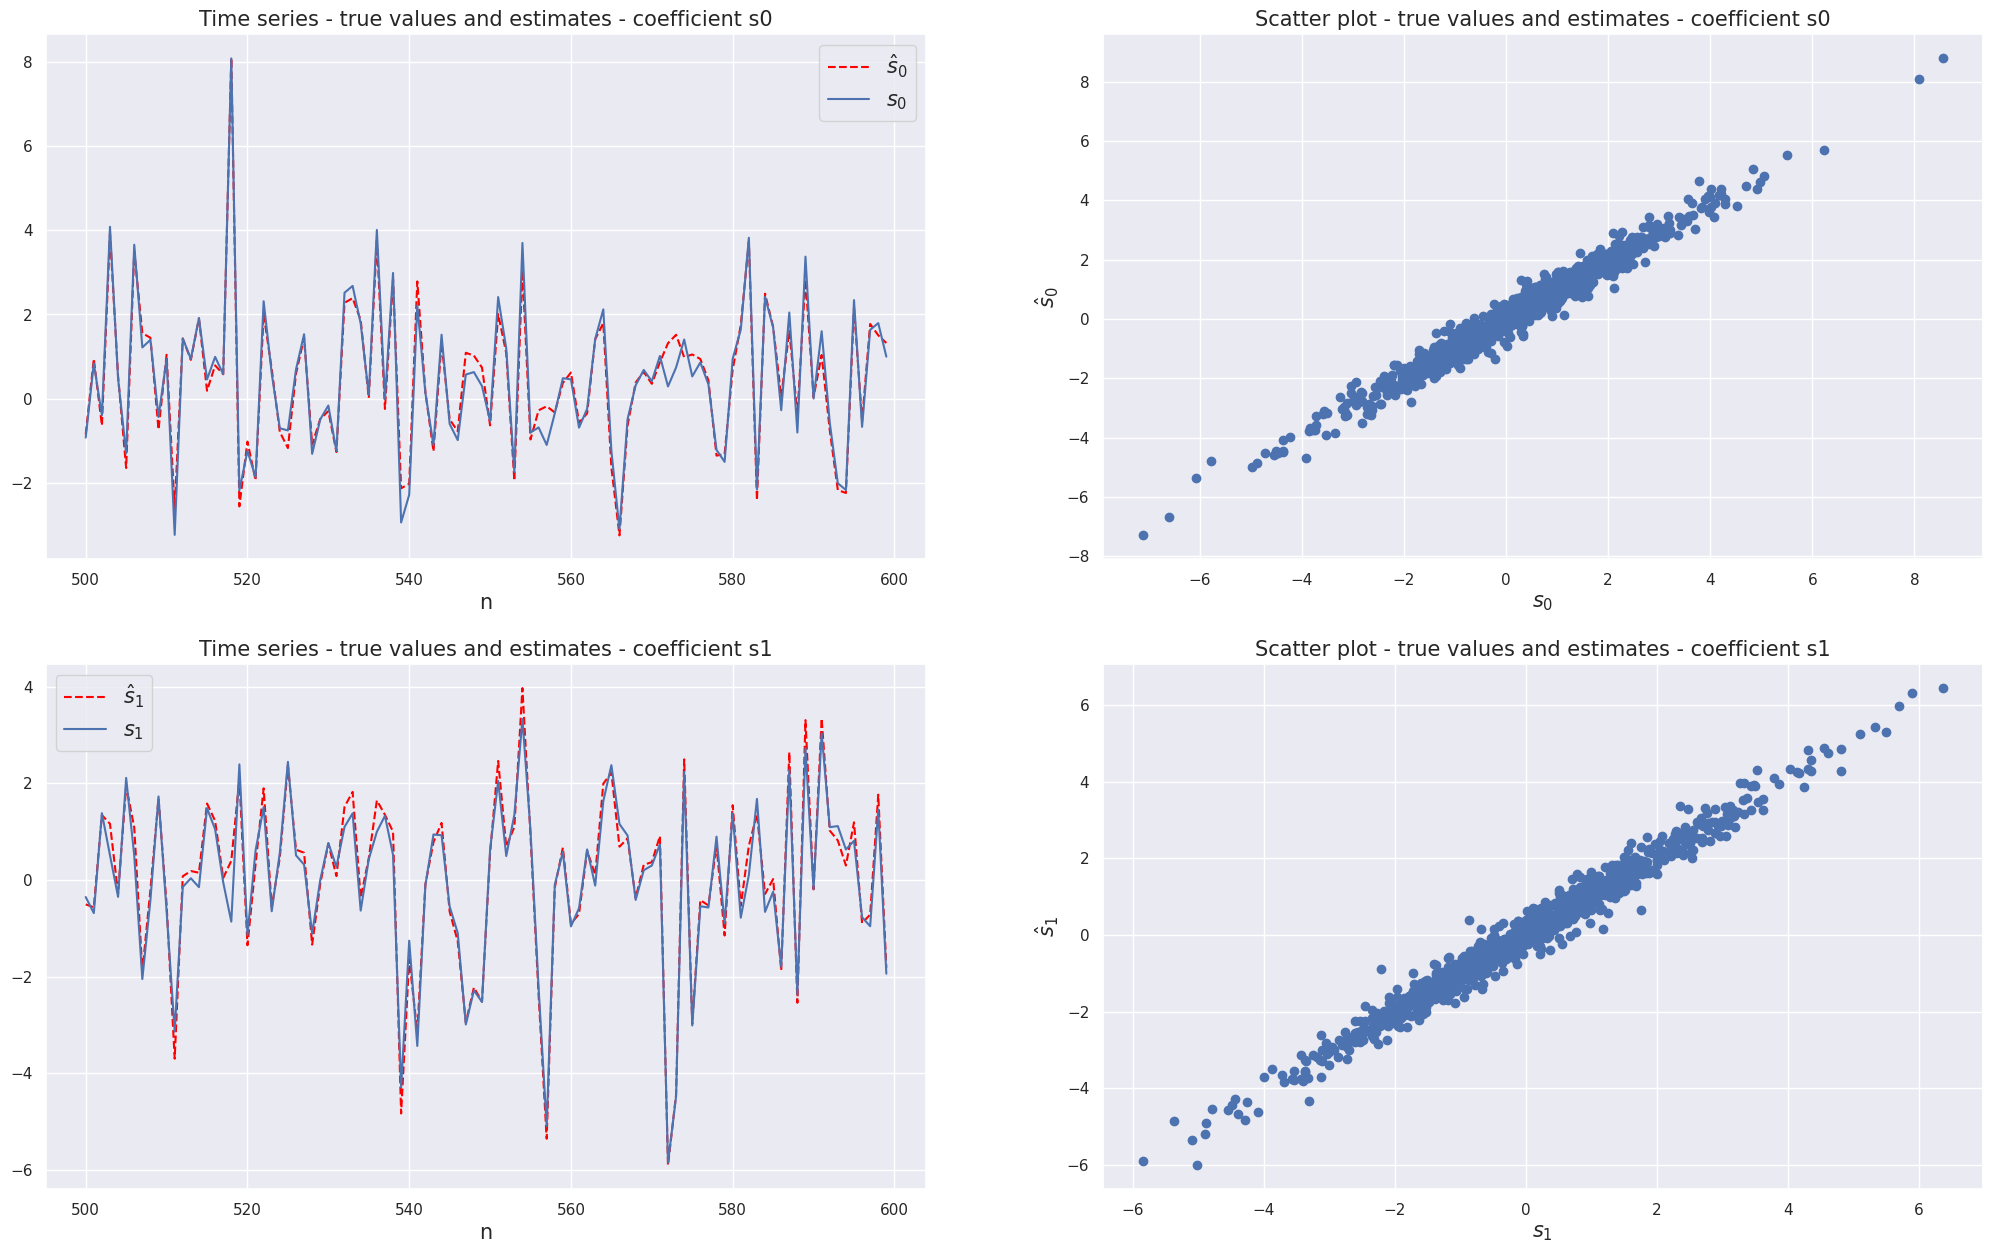

In [42]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [43]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.006628271542243459


# 2. SLIGHTLY MISSPECIFIED MODEL

In [44]:
model_dir = slightly_misspecified_model_dir

## 2.1. Initialize Sources

In [45]:
def source_cumulative(x):
    return 1/(1+np.exp(-x))

def source_pdf(x):
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_generator(
    nsources,
    nobs,
    mu,
    scale
):
    return np.random.logistic(
        loc=mu,
        scale=scale,
        size=(nsources, nobs)
    )

In [46]:
MU=0.1
SCALE=1.1

s = source_generator(
    nsources=NSOURCES,
    nobs=NOBS,
    mu=MU,
    scale=SCALE
)

print('-'*100)
print('NÚMERO DE FONTES: {}'.format(NSOURCES))
print('TAMANHO DOS SINAIS DAS FONTES: {}'.format(NOBS))
for i in range(s.shape[0]):
    print(
        'CURTOSE s{}: {}'.format(
            i,
            st.kurtosis(a=s[i,:])
        )
    )
    
print('-'*100)

----------------------------------------------------------------------------------------------------
NÚMERO DE FONTES: 2
TAMANHO DOS SINAIS DAS FONTES: 1000
CURTOSE s0: 0.8711506876905677
CURTOSE s1: 1.0637338814859367
----------------------------------------------------------------------------------------------------


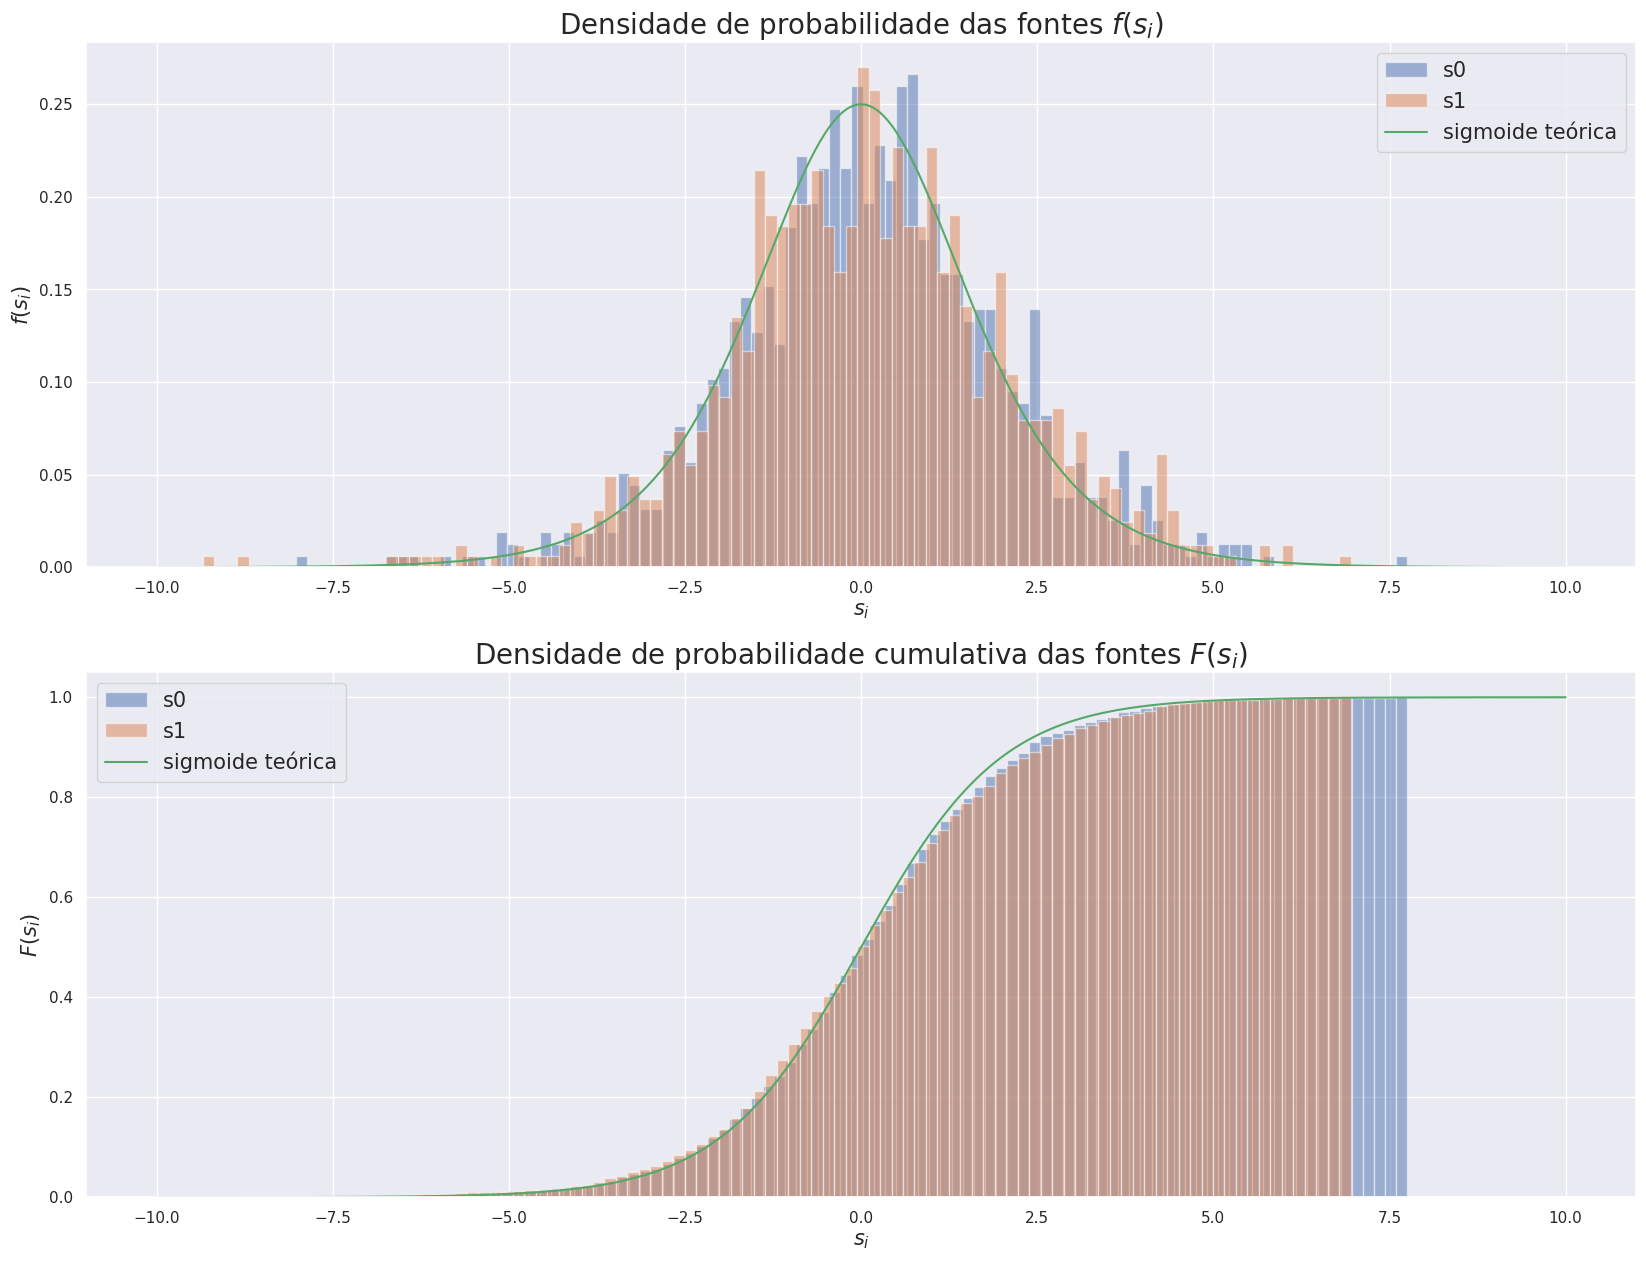

In [47]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)


for i in range(1, NSOURCES+1):
    ax1.hist(
        x=s[i-1,:],
        bins=100,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=s[i-1,:],
        bins=100,
        cumulative=True,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    
ax1.plot(
    np.linspace(-10,10,1000),
    [source_pdf(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)


ax2.plot(
    np.linspace(-10,10,1000),
    [source_cumulative(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)

ax1.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(s_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidade de probabilidade das fontes $f(s_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(s_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidade de probabilidade cumulativa das fontes $F(s_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

## 2.2. Mix sources and generate observations

In [48]:
print('MIXING MATRIX A:')
print(A)

MIXING MATRIX A:
[[ 1.   1. ]
 [-0.5  0.5]]


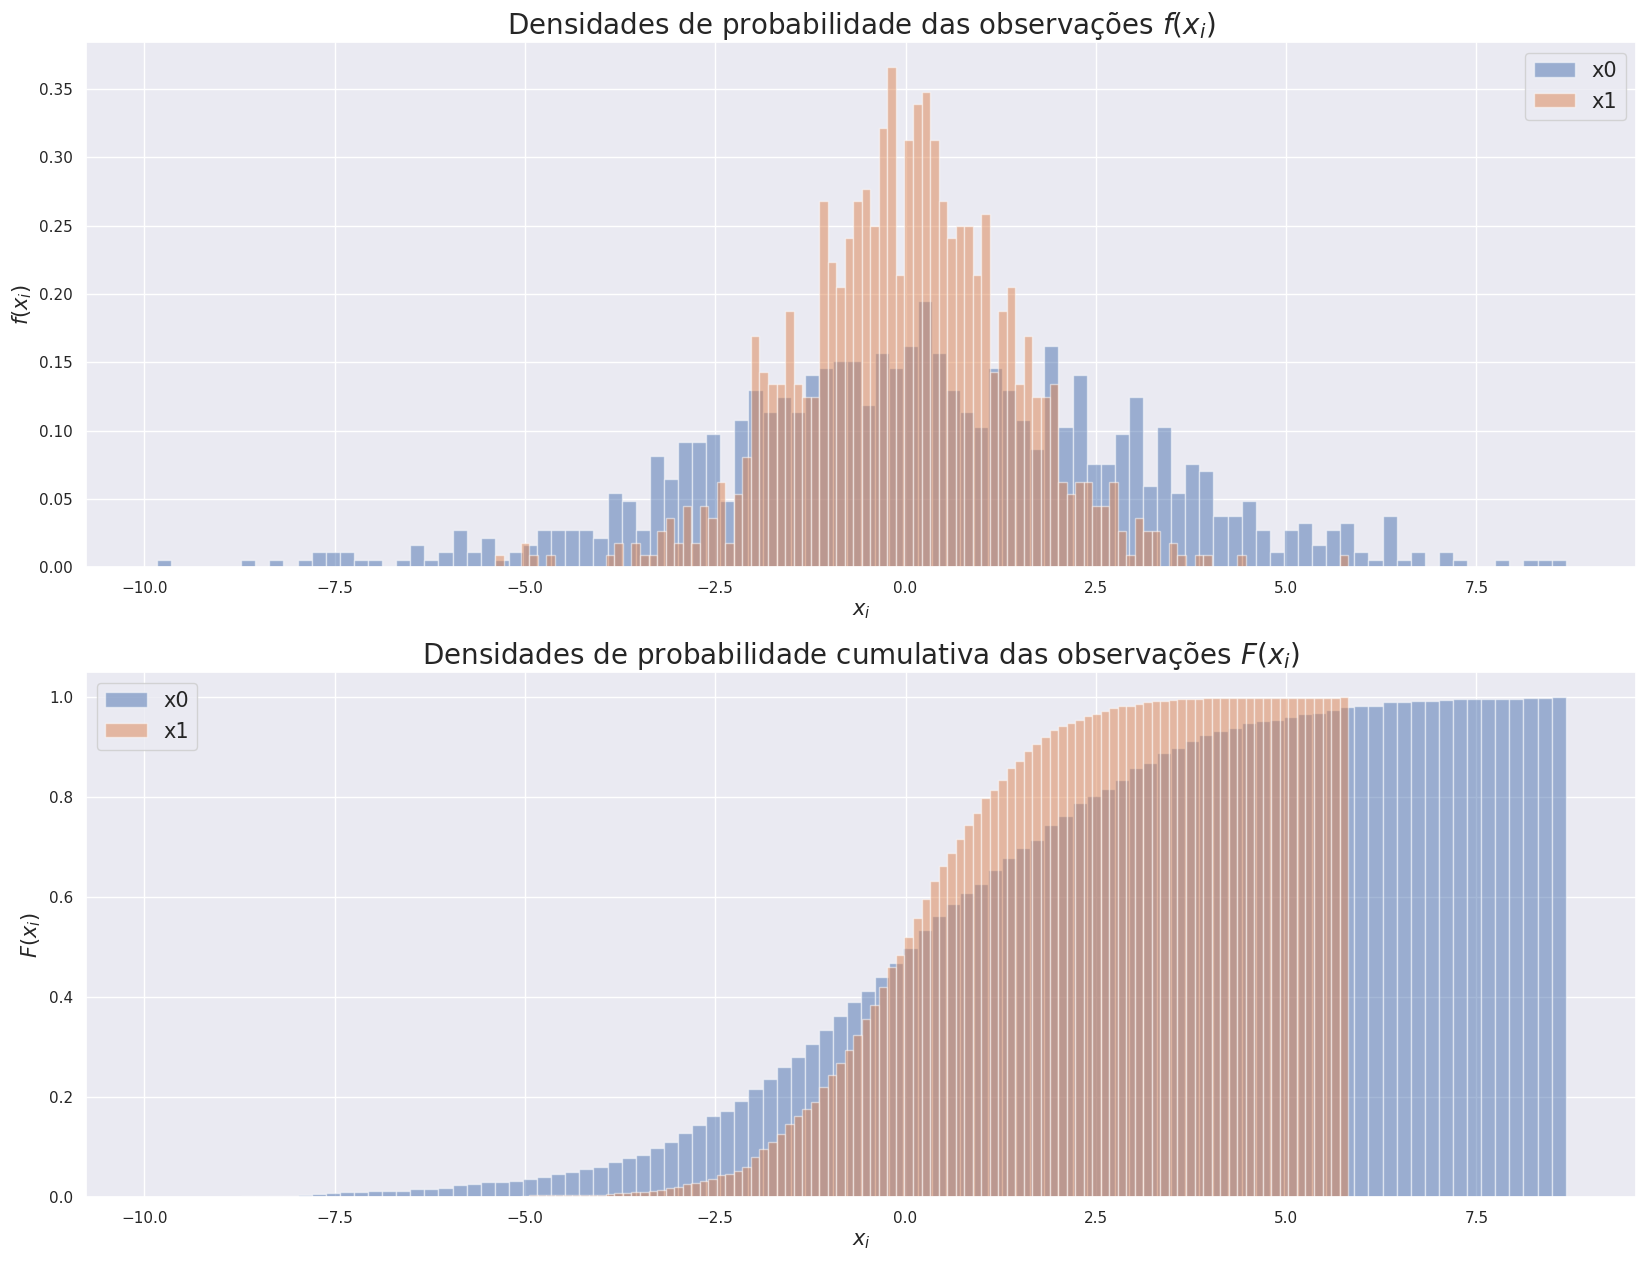

In [49]:
# Observed sources
x = A@s

fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)

for i in range(1, NSOURCES+1):
    ax1.hist(
        x=x[i-1,:],
        bins=100,
        density=True,
        label='x{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=x[i-1,:],
        bins=100,
        cumulative=True,
        density=True,
        label='x{}'.format(i-1),
        alpha=0.5
    )

ax1.set_xlabel(
    '$x_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(x_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidades de probabilidade das observações $f(x_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$x_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(x_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidades de probabilidade cumulativa das observações $F(x_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

In [50]:
if SAVE_SIGNALS:
    signal_save_dir = model_dir / 'signals'
    if not signal_save_dir.is_dir():
        signal_save_dir.mkdir()

    with (signal_save_dir / 'sources.pkl').open(mode='wb') as f:
        pickle.dump(s, f)

    with (signal_save_dir / 'mixtures.pkl').open(mode='wb') as f:
        pickle.dump(x, f)

## 2.3. Perform Analysis - LIKELIHOOD

#### Prior:
#### $p(\boldsymbol{B})=cte$

### 2.3.1 Execute Gradient Ascent Optimization

In [51]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))


def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])


def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    return 1

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    return np.zeros(
        shape=X.shape
    )

In [52]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'likelihood'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 392 ms, sys: 19.1 ms, total: 411 ms
Wall time: 16min 44s


### 2.3.2. Parse Optimization Results

In [53]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [54]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[ 0.32125686  1.1174358 ]
 [ 0.56114606 -0.68507347]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [55]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-4174.3329447213755,
 -4191.682291466148,
 -4191.150881899052,
 -4175.488175333216,
 -4192.122698220994,
 -4191.7001720565195,
 -4191.886680656152,
 -4175.543219791875,
 -4176.011874054251,
 -4176.011402907224]

In [56]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 0.32125686,  1.1174358 ],
        [ 0.56114606, -0.68507347]]),
 array([[ 0.15431103, -1.27380912],
        [-0.619496  , -0.24663516]]),
 array([[-0.16953613,  1.26588777],
        [-0.61558508, -0.27575984]]),
 array([[ 0.41804335, -1.0268074 ],
        [ 0.49280049,  0.77462709]]),
 array([[ 0.6373246 , -0.03222116],
        [ 0.00793323, -1.29945069]]),
 array([[-0.63746285,  0.06079316],
        [-0.0070533 , -1.29717851]]),
 array([[ 9.33610350e-04,  1.25627747e+00],
        [-6.37563628e-01,  4.68763170e-02]]),
 array([[-0.41728895,  1.02864476],
        [-0.49346872, -0.77288506]]),
 array([[-0.57797175,  0.60840408],
        [ 0.28487205,  1.14313615]]),
 array([[-0.28497916, -1.1439865 ],
        [ 0.57799443, -0.60883545]])]

### 2.3.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


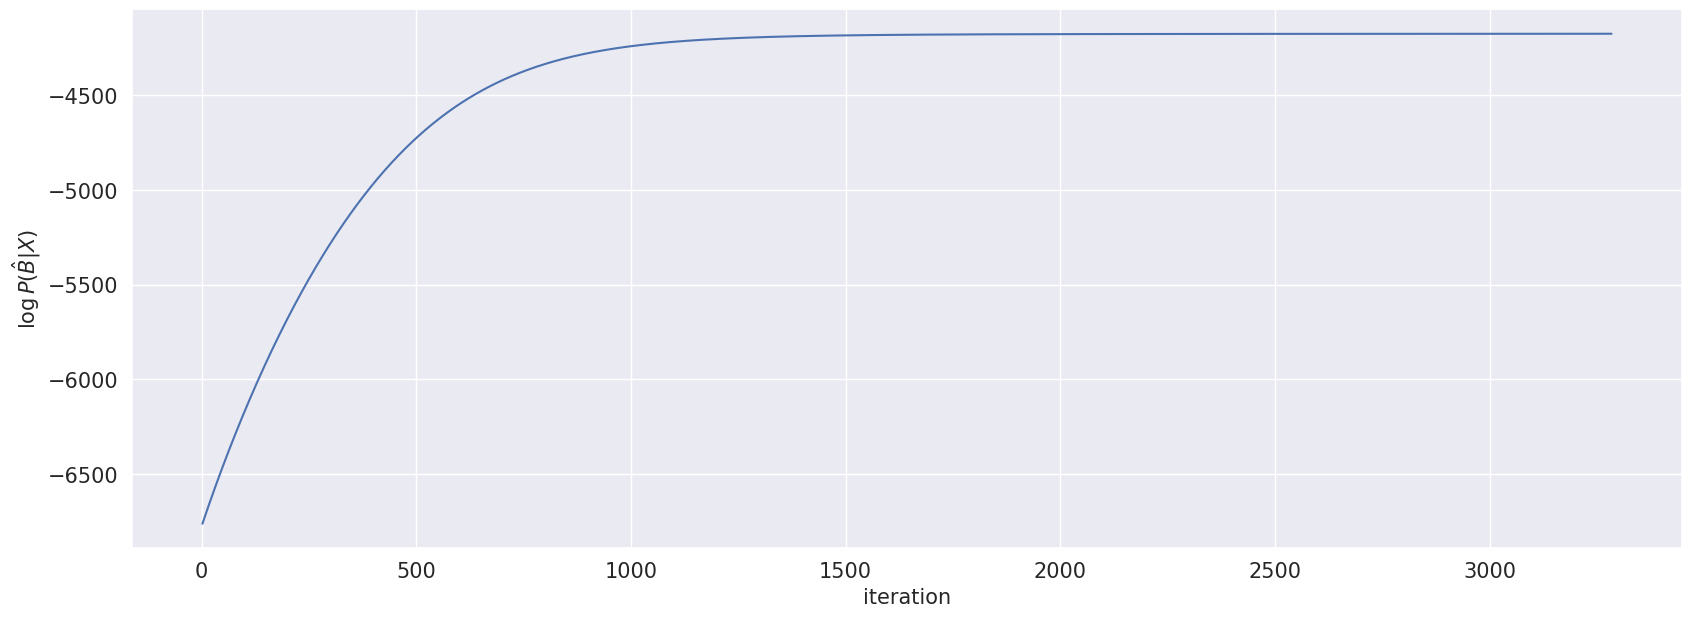

In [57]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 2.3.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


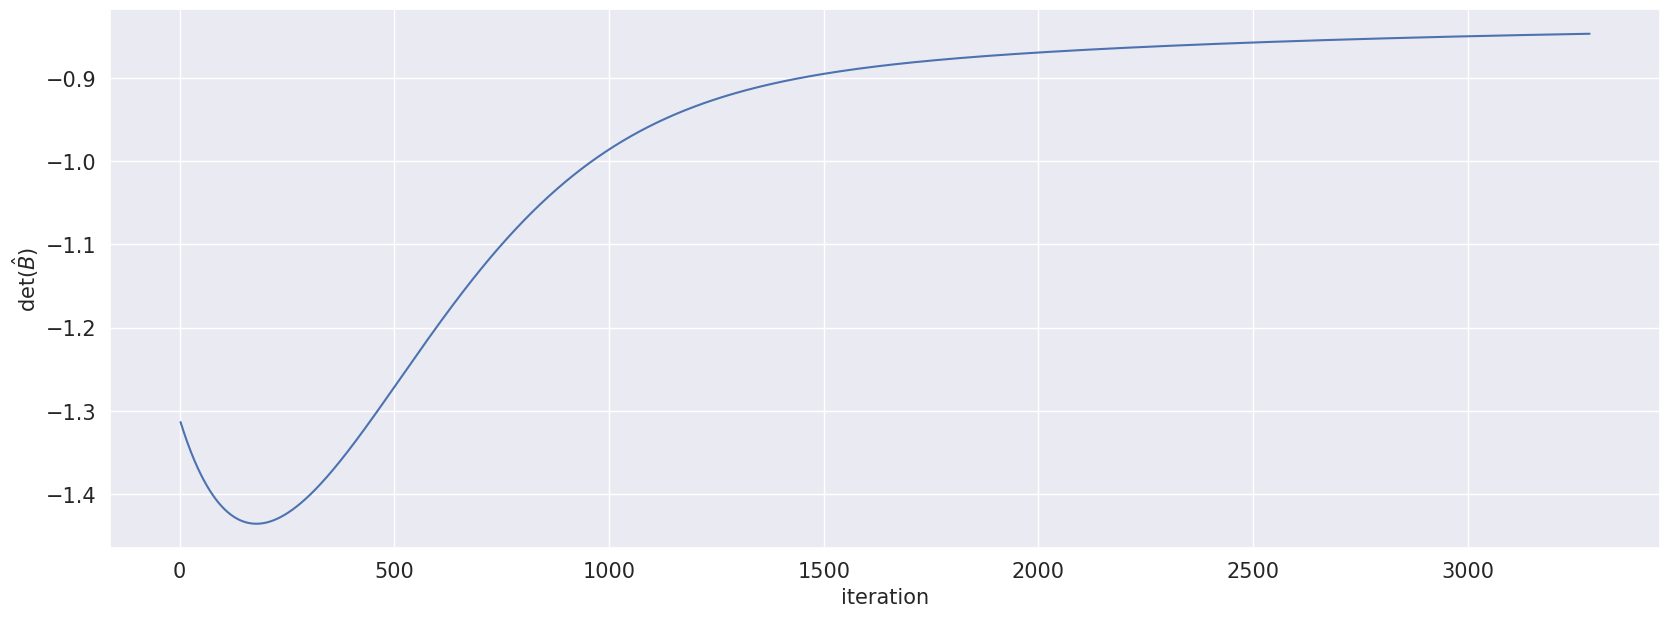

In [58]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 2.3.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


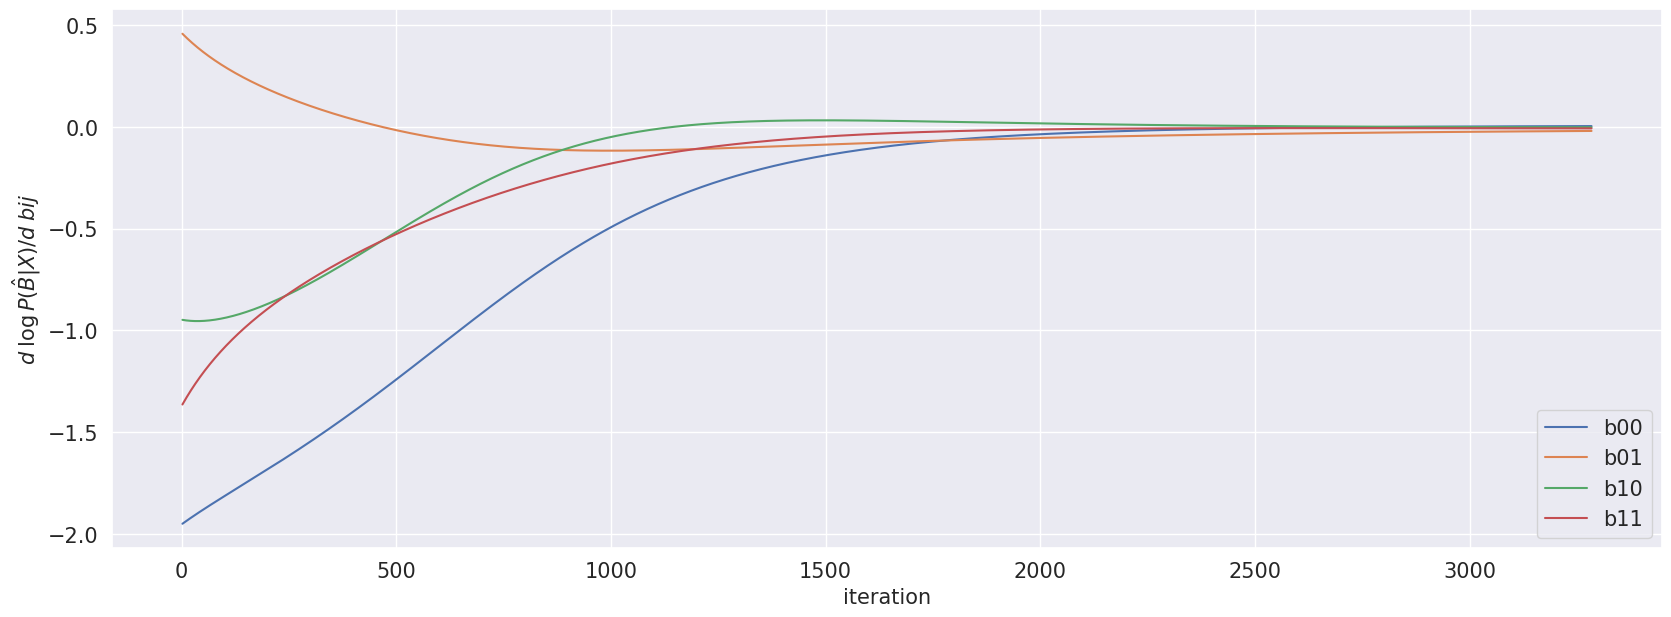

In [59]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 2.3.6. Plot source separation results

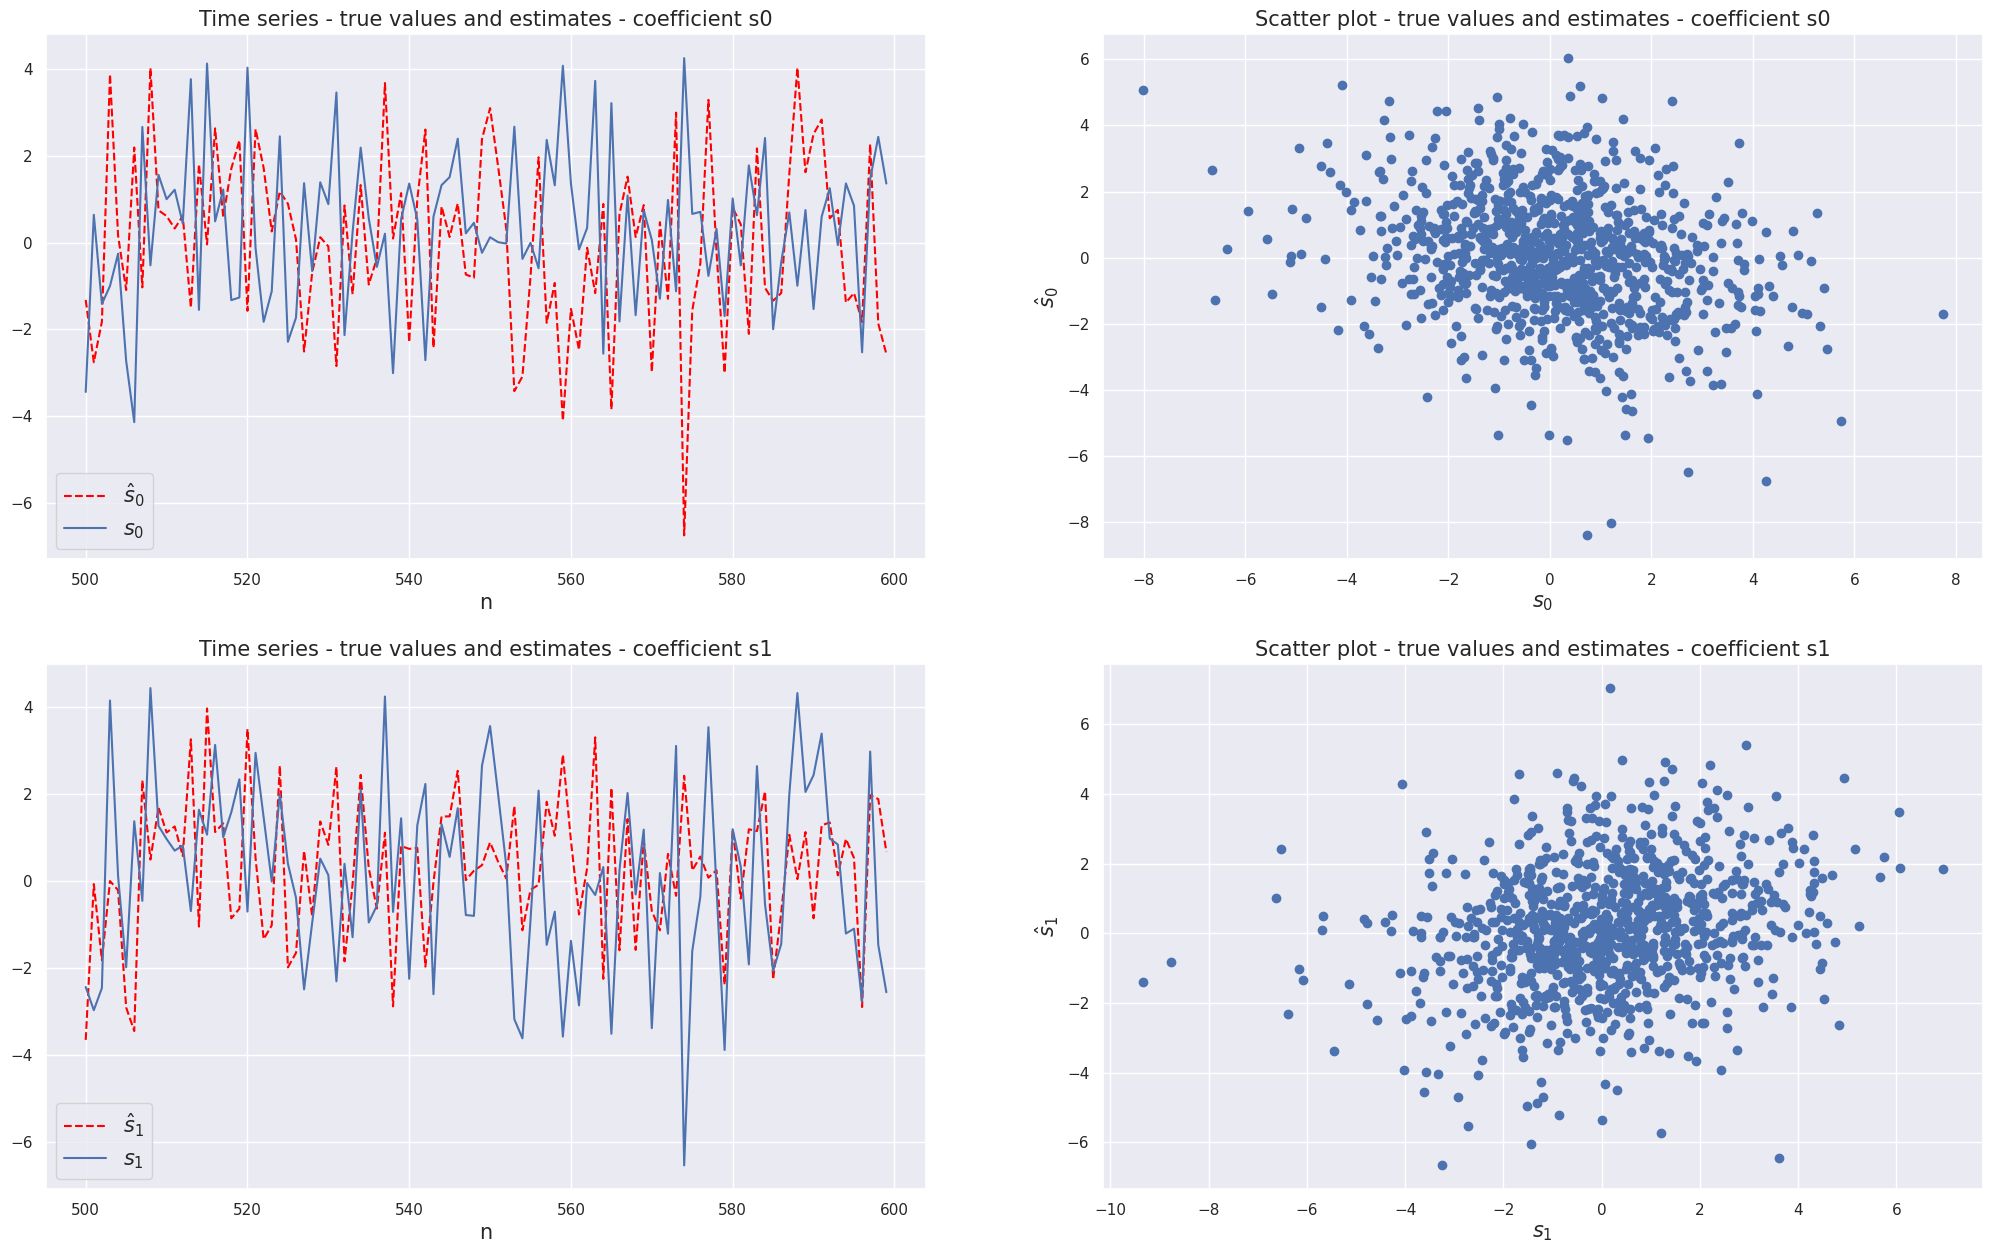

In [60]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [61]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.060012781937426665


## 2.4. Perform Analysis - DETERMINANT PRIOR
#### Prior:
$p(\boldsymbol{B}) \varpropto \exp \left[ -\frac{1}{2 \sigma^{2}} (det(\boldsymbol{B}) - 1)^2 \right]$

### 2.4.1 Execute Gradient Ascent Optimization

In [62]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])

def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    sig=1
    desired_det=1
    return (1/np.sqrt(2*np.pi*np.square(sig)))*np.exp(-np.square(np.linalg.det(X)-desired_det)/(2*np.square(sig)))

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    sig=1
    return -1*prior_pdf(X)*(np.linalg.det(X)-1)/np.square(sig)

In [63]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'determinant_prior'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 328 ms, sys: 20.4 ms, total: 348 ms
Wall time: 12min 24s


### 2.4.2. Parse Optimization Results

In [64]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [65]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[ 0.41944974 -1.02499127]
 [ 0.49189891  0.77768126]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [66]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-4180.521341688909,
 -4194.314773226165,
 -4192.084651236582,
 -4176.3358480029465,
 -4195.5013239092805,
 -inf,
 -4192.793767356117,
 -4176.580090779556,
 -4177.0834675900105,
 -4177.044747693256]

In [67]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 0.28262092,  1.19301857],
        [ 0.58977356, -0.5834637 ]]),
 array([[ 0.17092875, -1.23989135],
        [-0.6104539 , -0.24636515]]),
 array([[-0.16982177,  1.26633533],
        [-0.61537785, -0.27636142]]),
 array([[ 0.41944974, -1.02499127],
        [ 0.49189891,  0.77768126]]),
 array([[ 0.6412006 ,  0.07788732],
        [ 0.0699116 , -1.28891396]]),
 array([[nan, nan],
        [nan, nan]]),
 array([[ 0.00171371,  1.25691983],
        [-0.63741403,  0.04822799]]),
 array([[-0.41564678,  1.03108401],
        [-0.49458161, -0.76935671]]),
 array([[-0.54455574,  0.72880349],
        [ 0.34720472,  1.11895335]]),
 array([[-0.28306095, -1.14534308],
        [ 0.57891454, -0.60507634]])]

### 2.4.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


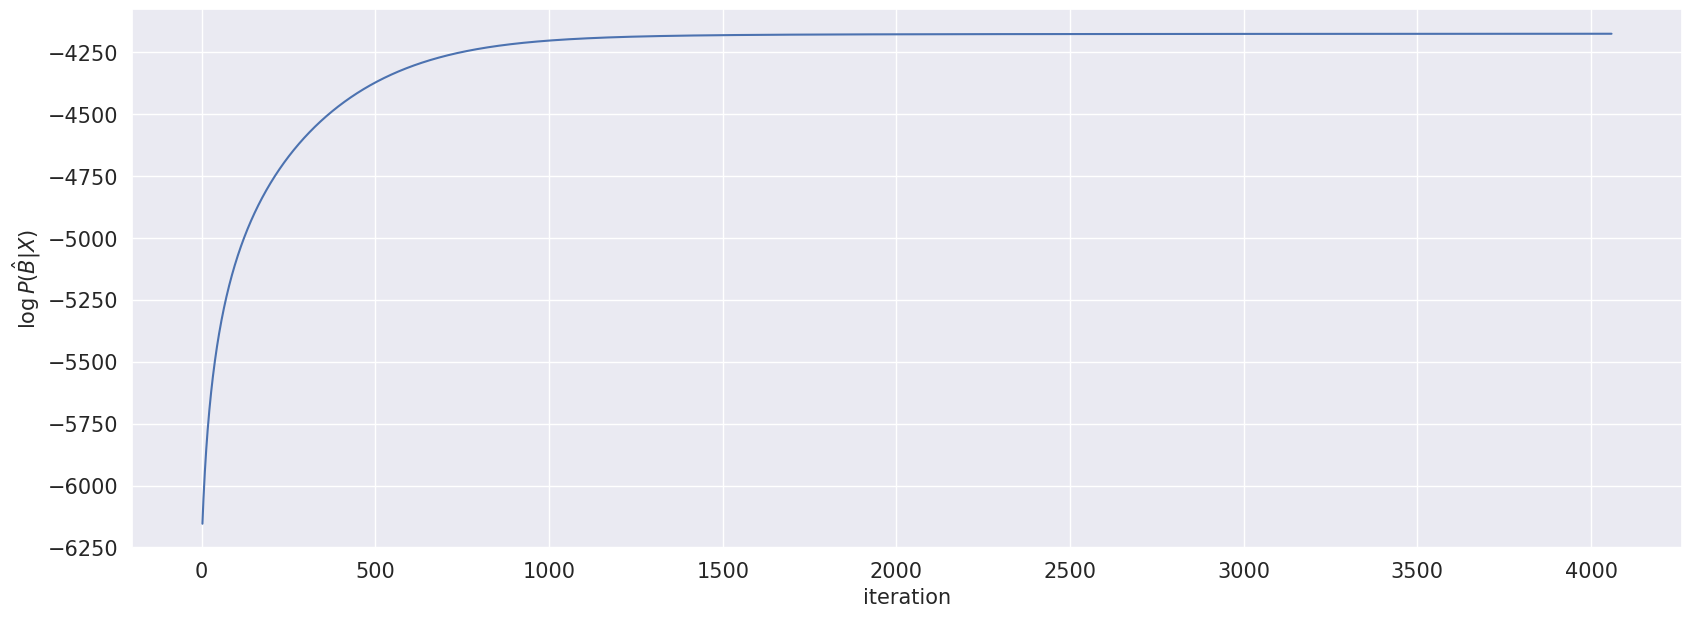

In [68]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 2.4.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


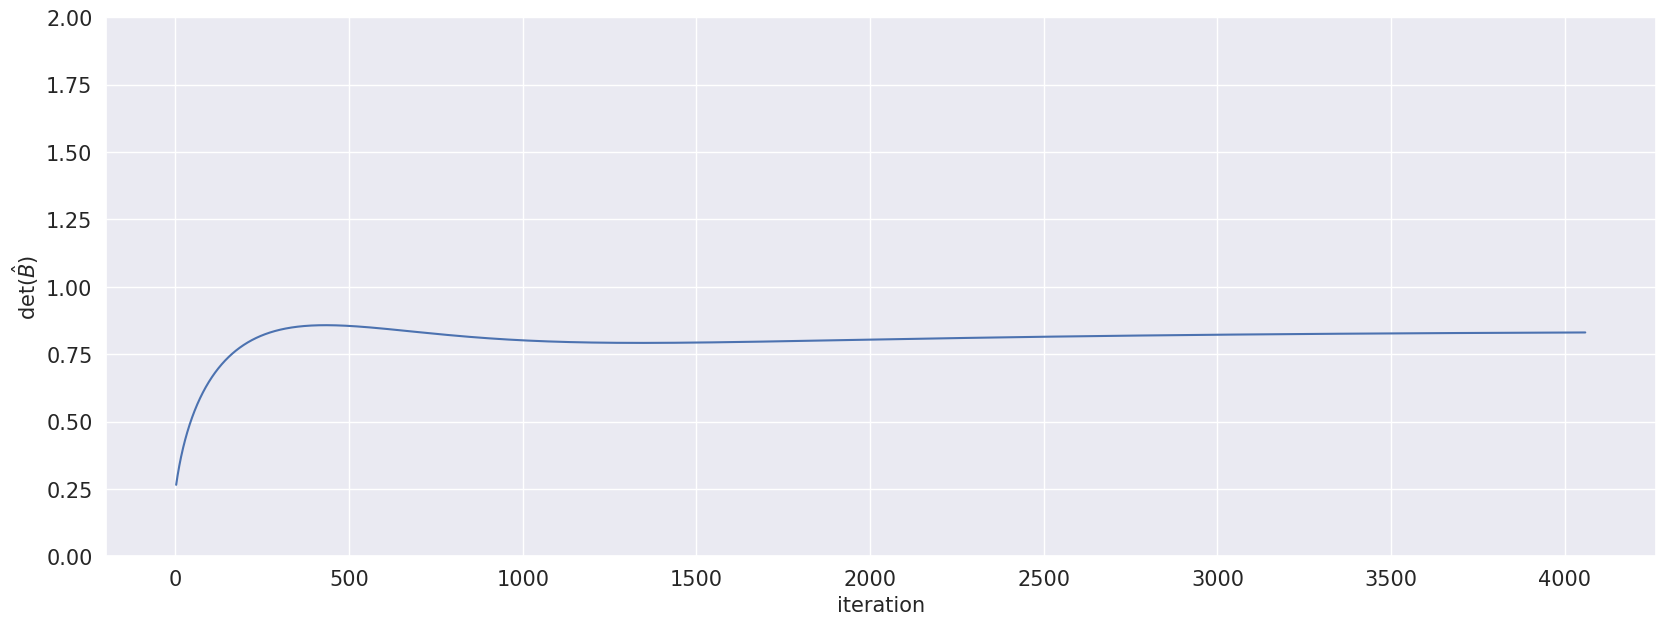

In [69]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=(0,2)
)

### 2.4.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


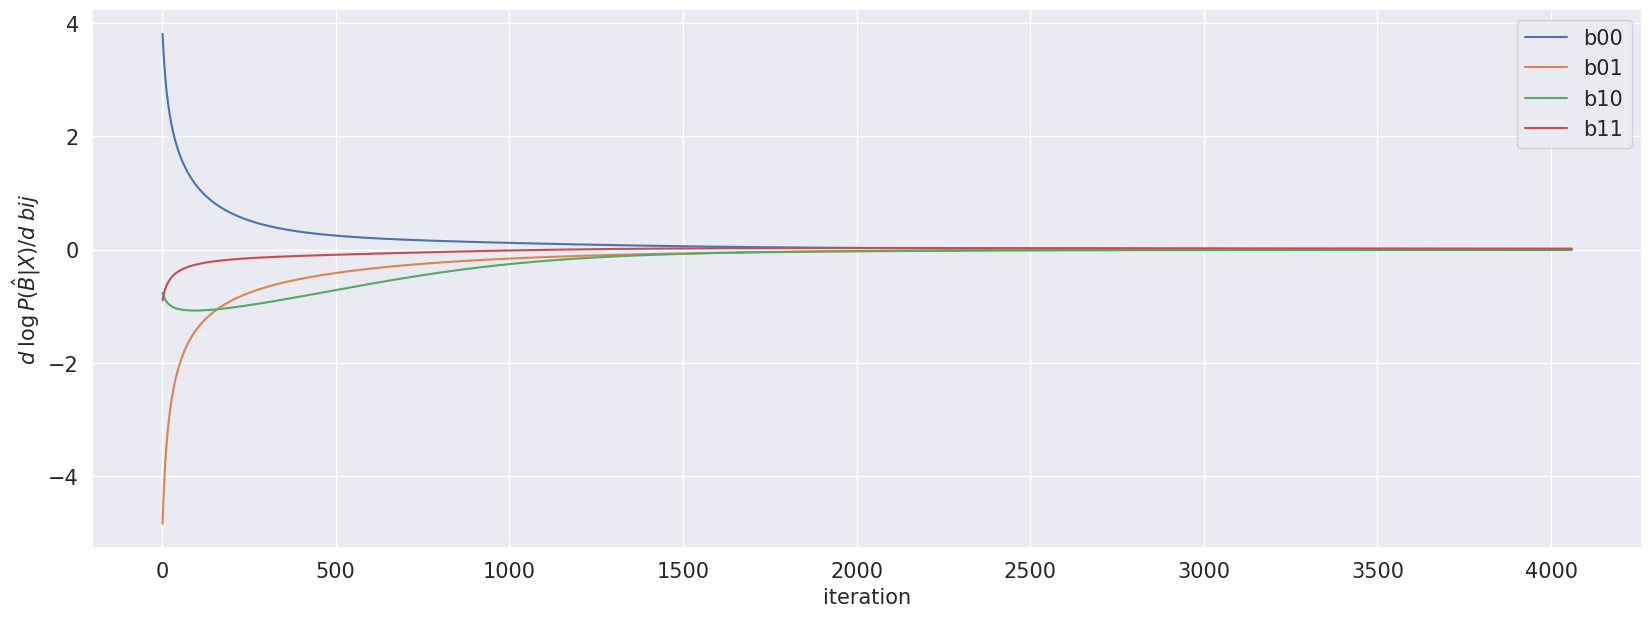

In [70]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 2.4.6. Plot source separation results

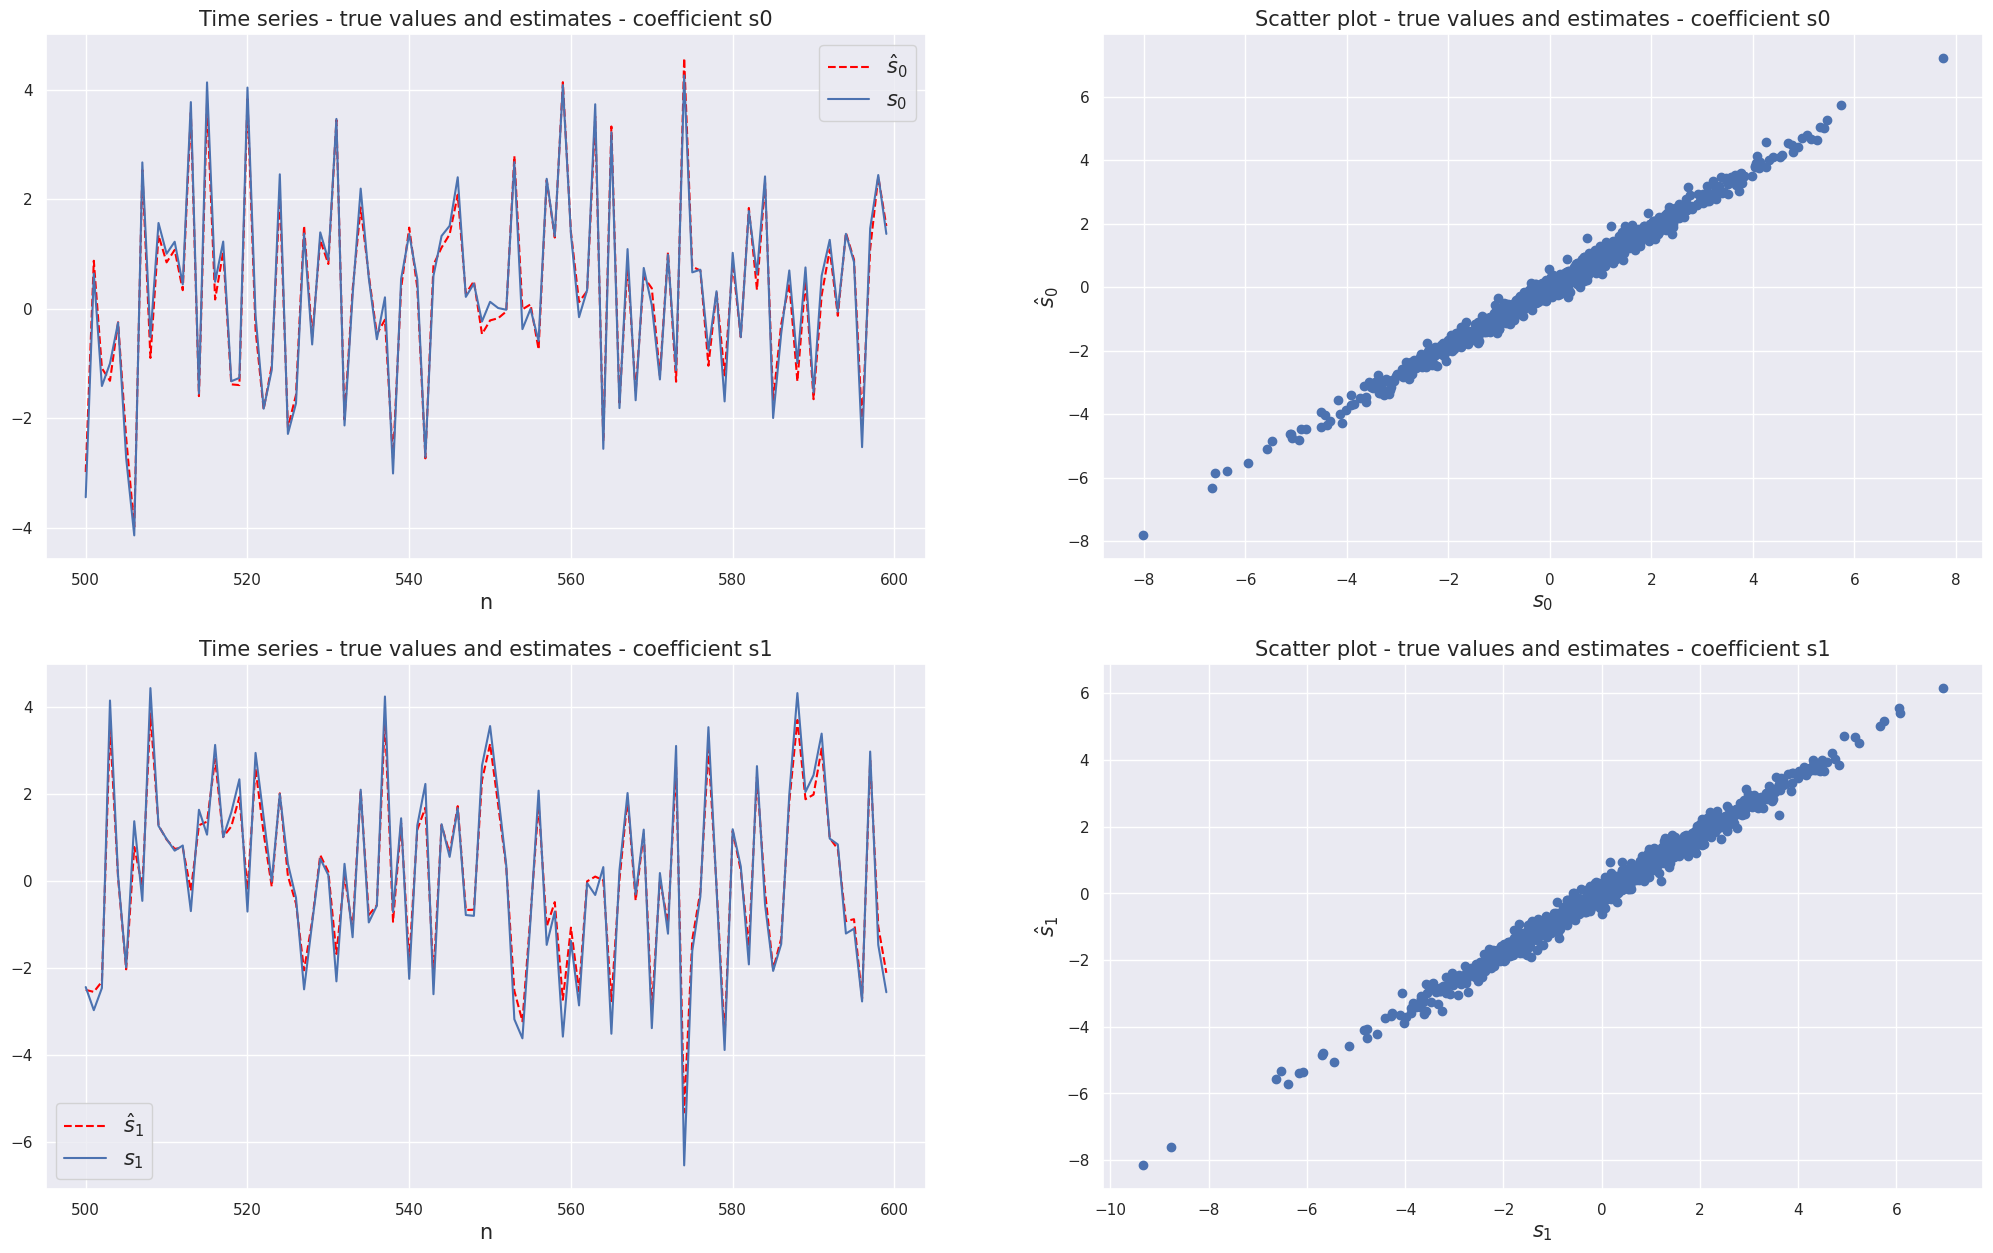

In [71]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [72]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.006116547945298515


## 2.5. Perform Analysis - near-identity transformation
#### Prior:
#### $p(\boldsymbol{B}) \varpropto \exp \left[ -\frac{1}{2 \sigma^{2}} ||\boldsymbol{B} - \boldsymbol{I}||^2 \right]$

### 2.5.1 Execute Gradient Ascent Optimization

In [73]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])

def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    sig=1
    return np.exp(
        (-1/2/np.square(sig))*np.linalg.norm(X-np.eye(X.shape[0]))
    )

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    sig=1
    der_X=np.empty(X.shape)
    I=np.eye(X.shape[0])
    for i, j in np.ndindex(X.shape):
        der_X[i, j] = prior_pdf(X)*(-1/np.square(sig))*(X[i,j]-I[i,j])
    return der_X

In [74]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'identity_transformation'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 423 ms, sys: 34 ms, total: 457 ms
Wall time: 16min 27s


### 2.5.2. Parse Optimization Results

In [75]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [76]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[ 0.32050128  1.11755477]
 [ 0.56090436 -0.67865902]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [77]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-4175.499328182527,
 -4192.767963889739,
 -4192.562478293368,
 -4175.798919287561,
 -4193.2362005877785,
 -4193.102241270464,
 -4192.701105109326,
 -4177.323142595956,
 -4177.033436633349,
 -4178.583201378456]

In [78]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 0.32050128,  1.11755477],
        [ 0.56090436, -0.67865902]]),
 array([[ 0.15291034, -1.27317422],
        [-0.61957195, -0.24065004]]),
 array([[-0.16079858,  1.26979144],
        [-0.61709118, -0.25890142]]),
 array([[ 0.42366569, -1.0190329 ],
        [ 0.48830196,  0.78609243]]),
 array([[ 0.63763067, -0.03020867],
        [ 0.00895296, -1.29535878]]),
 array([[-0.63558108,  0.05628708],
        [-0.00486105, -1.29250122]]),
 array([[ 0.00703025,  1.25635623],
        [-0.63700327,  0.05780836]]),
 array([[-0.40867909,  1.0327017 ],
        [-0.49812382, -0.75424055]]),
 array([[-0.5780126 ,  0.60195252],
        [ 0.28217498,  1.14512573]]),
 array([[-0.2610597 , -1.16405019],
        [ 0.58727869, -0.5605885 ]])]

### 2.5.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


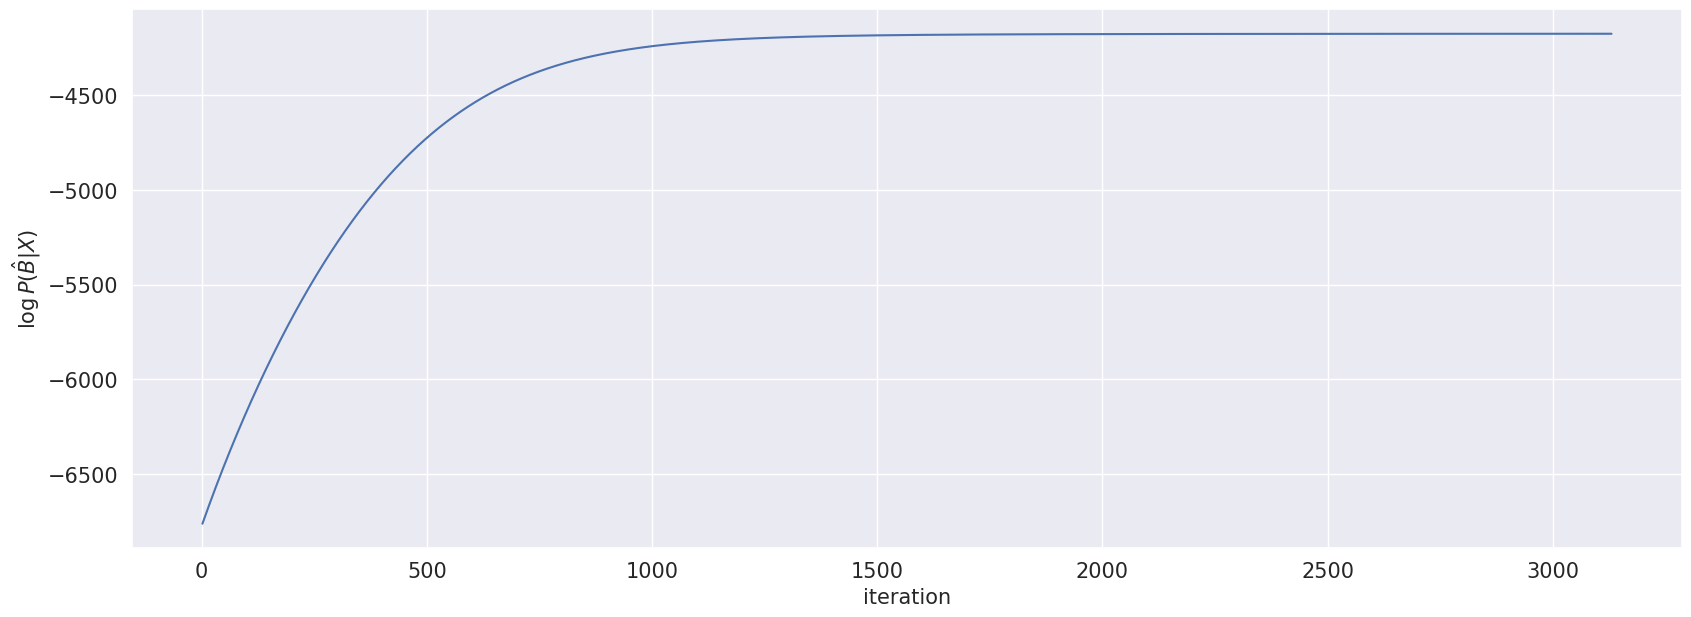

In [79]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 2.5.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


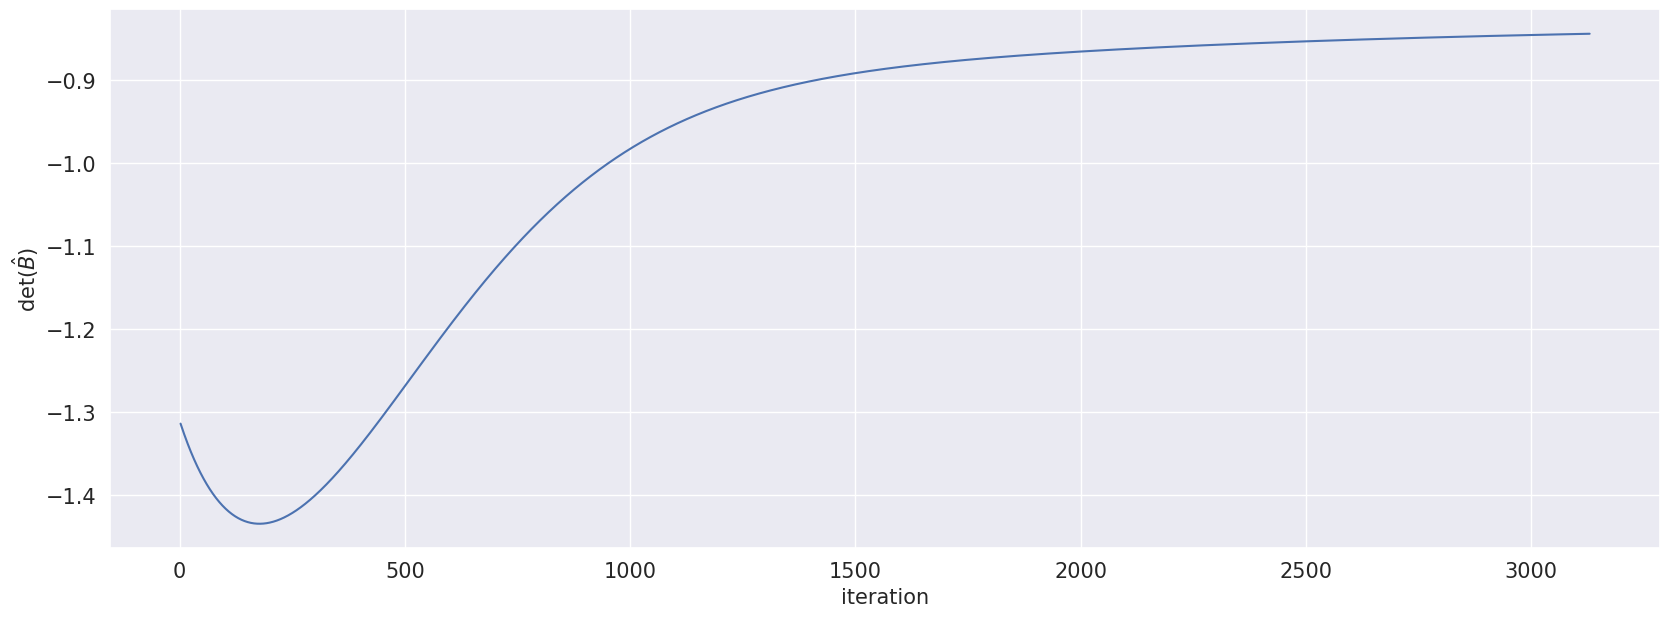

In [80]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 2.5.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


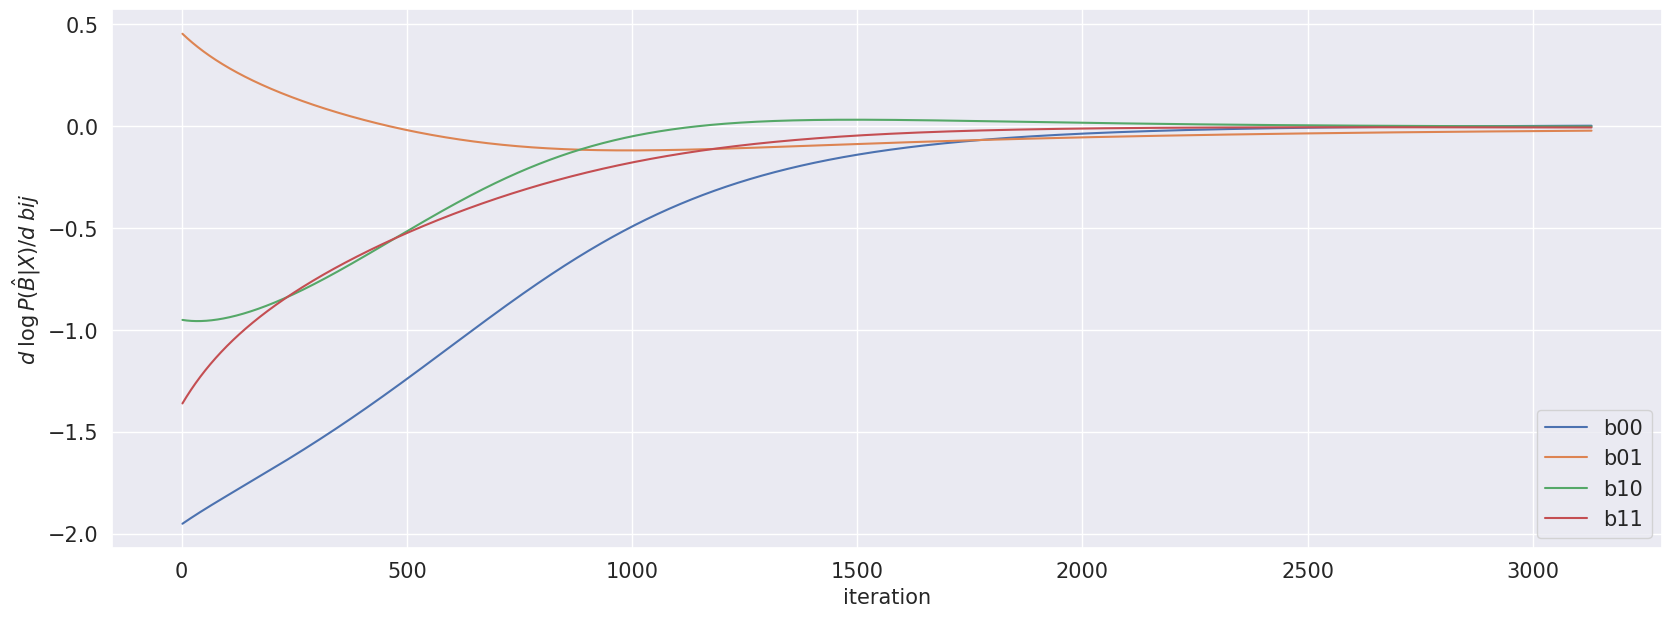

In [81]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 2.5.6. Plot source separation results

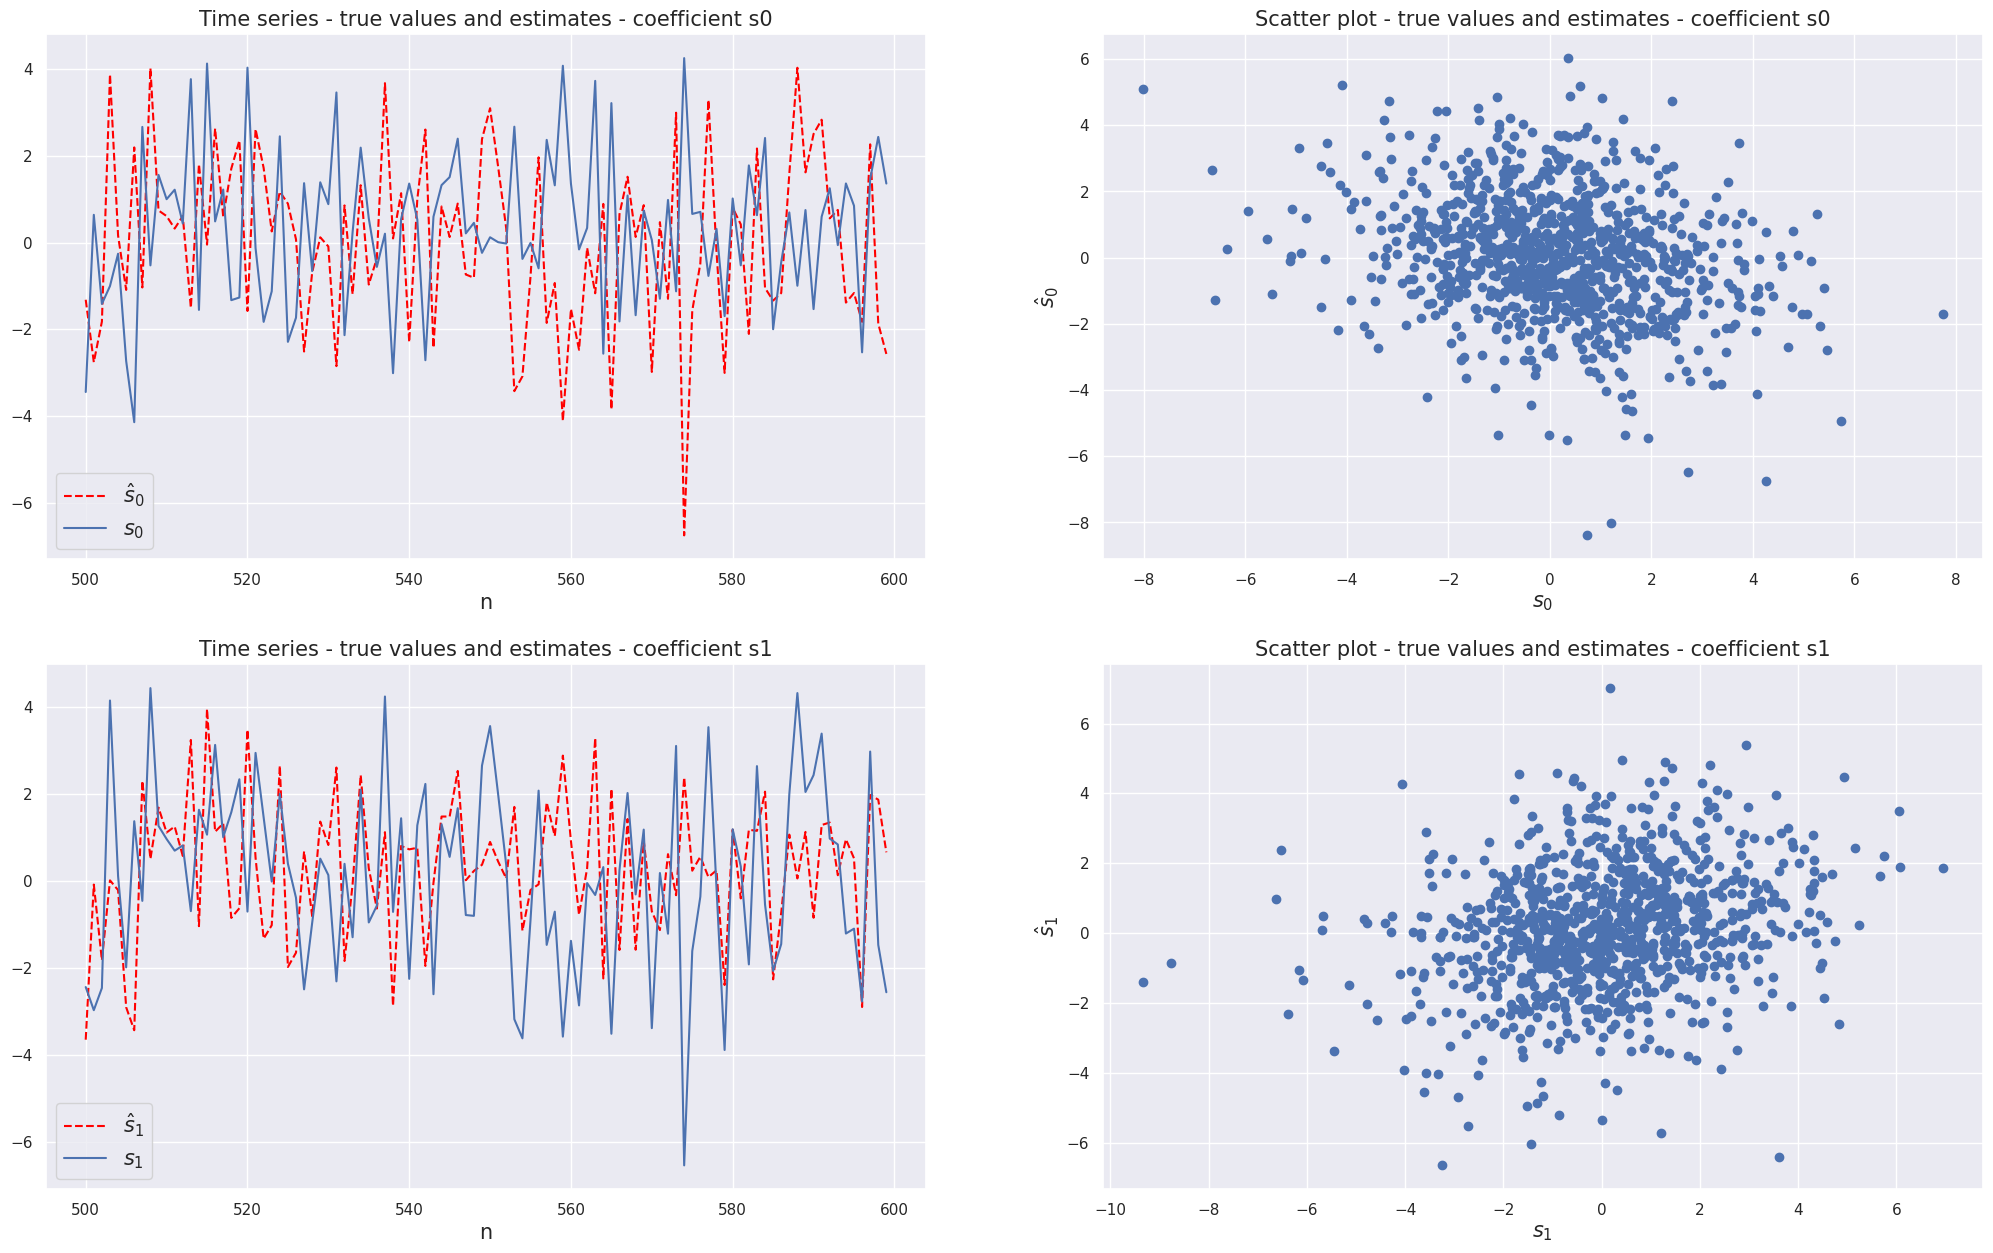

In [82]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [83]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.05993032391414406


# 3. LARGELY MISSPECIFIED MODEL - SUBGAUSSIAN

In [84]:
model_dir = largely_misspecified_model_dir

## 3.1. Initialize Sources

In [85]:
def source_cumulative(x):
    return 1/(1+np.exp(-x))

def source_pdf(x):
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_generator(
    nsources,
    nobs,
    mu,
    scale
):
    return np.random.triangular(
        left=-2,
        mode=0,
        right=2,
        size=(nsources, nobs)
    )

In [86]:
MU=0
SCALE=1

s = source_generator(
    nsources=NSOURCES,
    nobs=NOBS,
    mu=MU,
    scale=SCALE
)

print('-'*100)
print('NÚMERO DE FONTES: {}'.format(NSOURCES))
print('TAMANHO DOS SINAIS DAS FONTES: {}'.format(NOBS))
for i in range(s.shape[0]):
    print(
        'CURTOSE s{}: {}'.format(
            i,
            st.kurtosis(a=s[i,:])
        )
    )
    
print('-'*100)

----------------------------------------------------------------------------------------------------
NÚMERO DE FONTES: 2
TAMANHO DOS SINAIS DAS FONTES: 1000
CURTOSE s0: -0.6674591824616818
CURTOSE s1: -0.5617245012952297
----------------------------------------------------------------------------------------------------


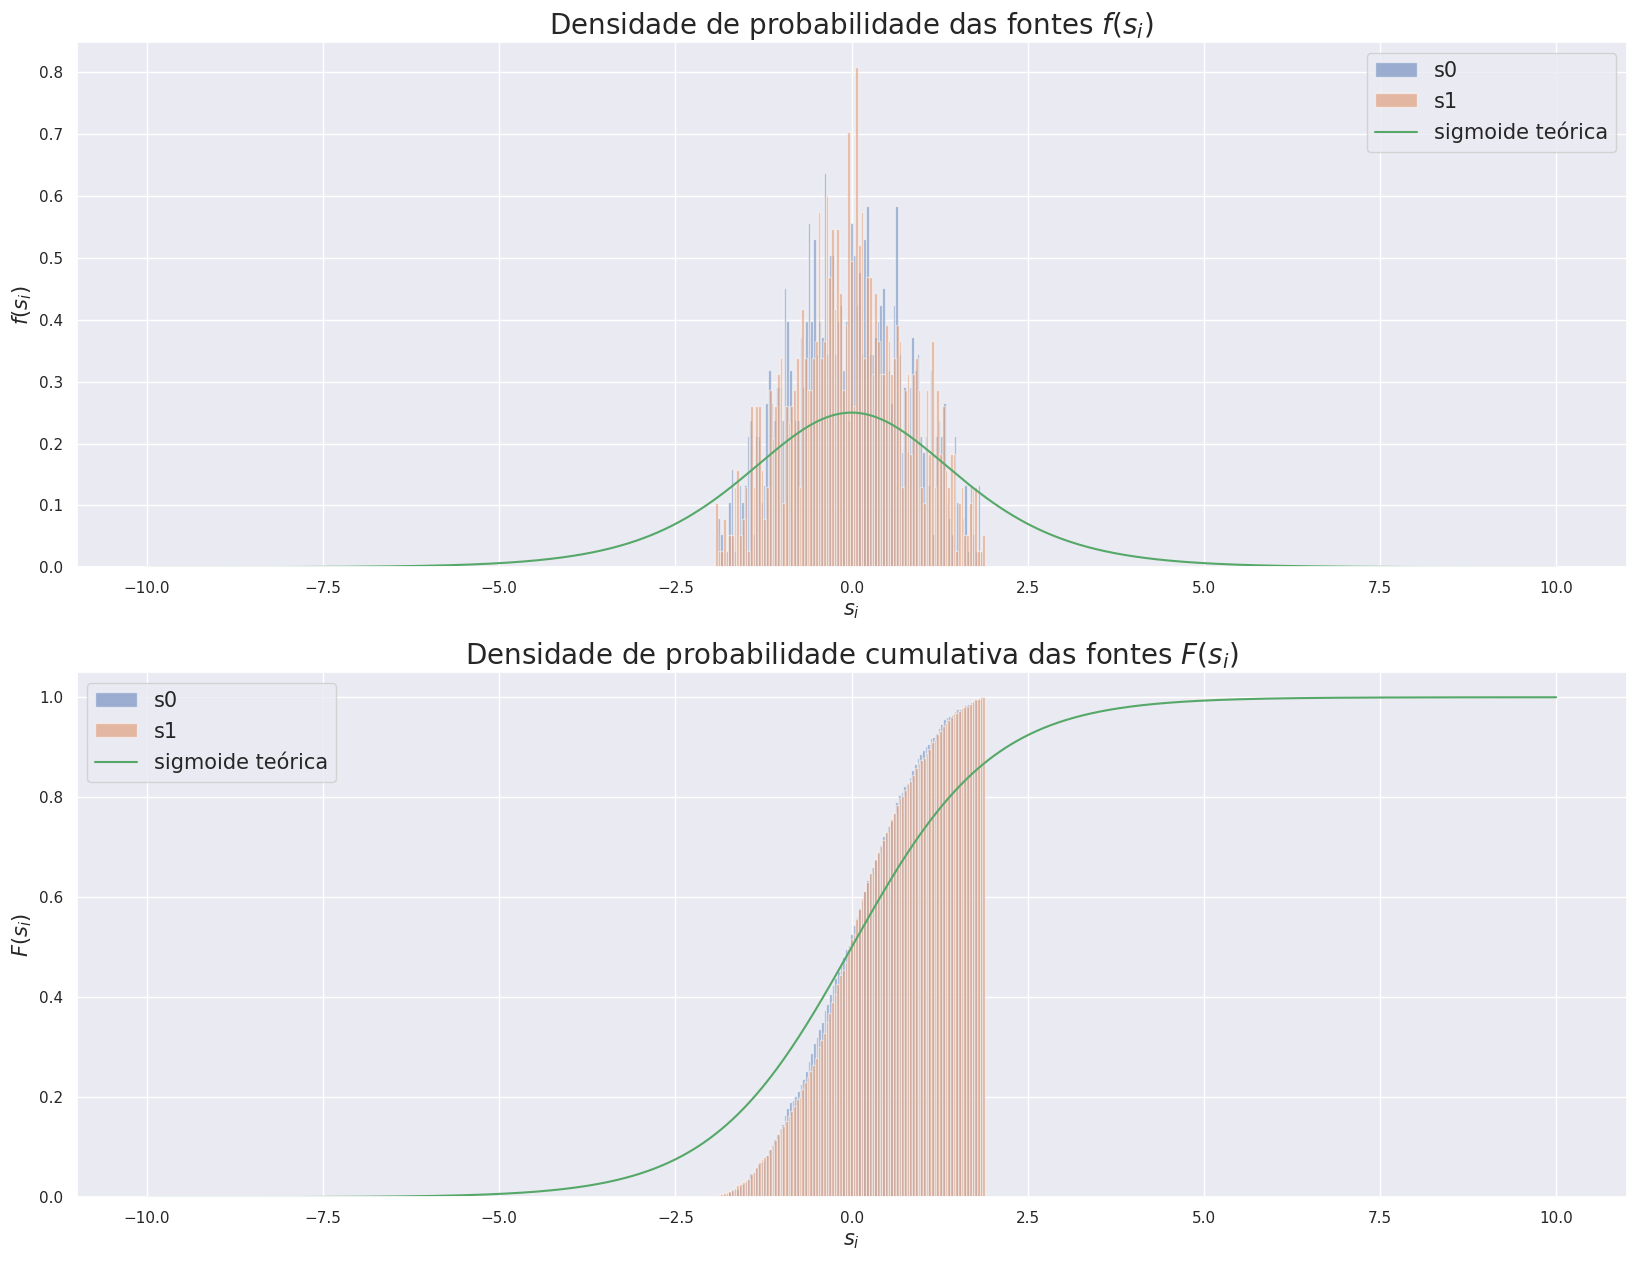

In [87]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)


for i in range(1, NSOURCES+1):
    ax1.hist(
        x=s[i-1,:],
        bins=100,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=s[i-1,:],
        bins=100,
        cumulative=True,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    
ax1.plot(
    np.linspace(-10,10,1000),
    [source_pdf(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)


ax2.plot(
    np.linspace(-10,10,1000),
    [source_cumulative(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)

ax1.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(s_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidade de probabilidade das fontes $f(s_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(s_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidade de probabilidade cumulativa das fontes $F(s_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

## 3.2. Mix sources and generate observations

In [88]:
print('MIXING MATRIX A:')
print(A)

MIXING MATRIX A:
[[ 1.   1. ]
 [-0.5  0.5]]


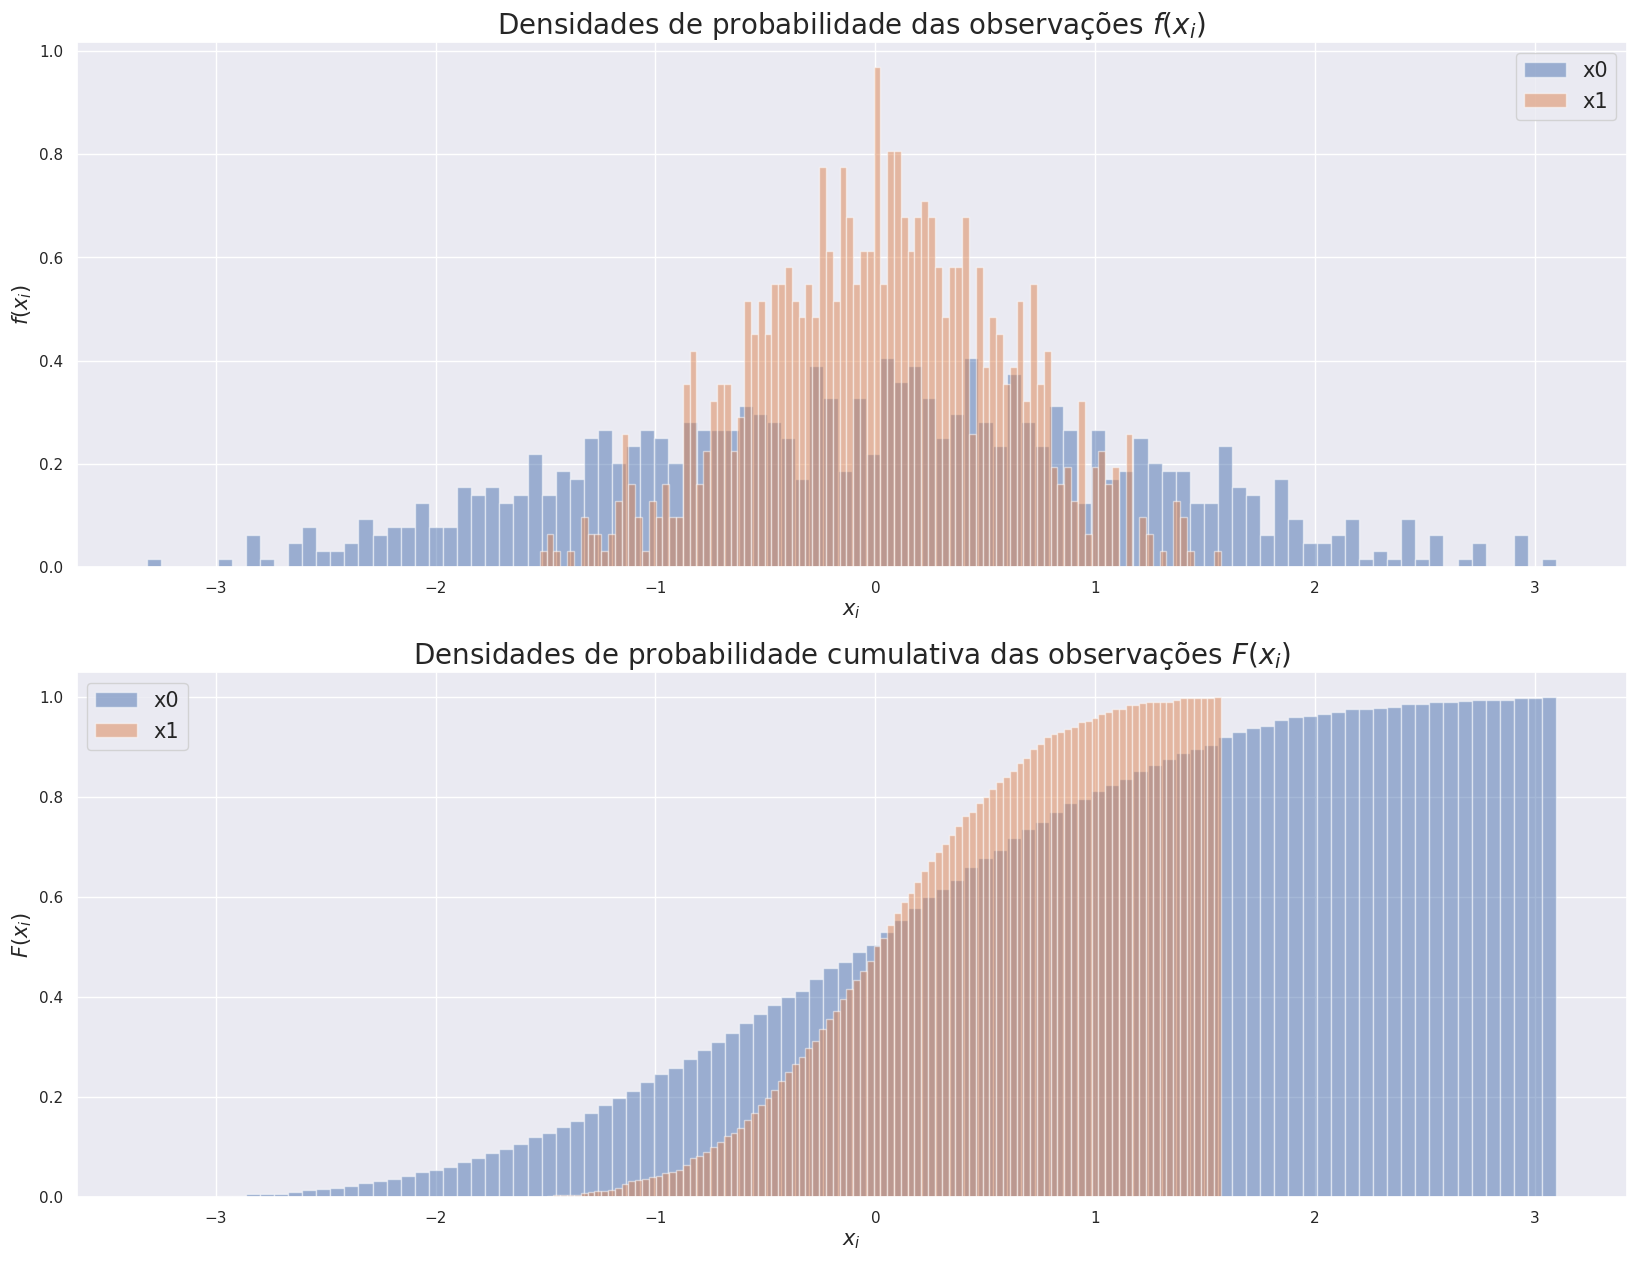

In [89]:
# Observed sources
x = A@s

fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)

for i in range(1, NSOURCES+1):
    ax1.hist(
        x=x[i-1,:],
        bins=100,
        density=True,
        label='x{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=x[i-1,:],
        bins=100,
        cumulative=True,
        density=True,
        label='x{}'.format(i-1),
        alpha=0.5
    )

ax1.set_xlabel(
    '$x_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(x_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidades de probabilidade das observações $f(x_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$x_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(x_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidades de probabilidade cumulativa das observações $F(x_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

In [90]:
if SAVE_SIGNALS:
    signal_save_dir = model_dir / 'signals'
    if not signal_save_dir.is_dir():
        signal_save_dir.mkdir()

    with (signal_save_dir / 'sources.pkl').open(mode='wb') as f:
        pickle.dump(s, f)

    with (signal_save_dir / 'mixtures.pkl').open(mode='wb') as f:
        pickle.dump(x, f)

## 3.3. Perform Analysis - LIKELIHOOD

#### Prior:
#### $p(\boldsymbol{B})=cte$

### 3.3.1 Execute Gradient Ascent Optimization

In [91]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))


def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])


def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    return 1

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    return np.zeros(
        shape=X.shape
    )

In [92]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'likelihood'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 885 ms, sys: 52.2 ms, total: 937 ms
Wall time: 29min 57s


### 3.3.2. Parse Optimization Results

In [93]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [94]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[-1.47070816  0.00832933]
 [-0.02886646 -3.00404191]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [95]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-2486.2303578484516,
 -2482.658766308161,
 -2483.311792879073,
 -2487.056770854405,
 -2478.3757744655513,
 -2477.2622146265576,
 -2478.1109383996095,
 -2489.545172988385,
 -2478.9897957336048,
 -2482.355085234258]

In [96]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 0.728167  ,  2.50310423],
        [ 1.23253334, -1.50224493]]),
 array([[ 0.36845301, -2.80931451],
        [-1.39265164, -0.79495026]]),
 array([[-0.40568428,  2.78533831],
        [-1.3810997 , -0.8719238 ]]),
 array([[ 0.6158368 , -2.60391586],
        [ 1.29441008,  1.302953  ]]),
 array([[ 1.4453281 ,  0.06686298],
        [ 0.02568633, -2.92402951]]),
 array([[-1.47070816,  0.00832933],
        [-0.02886646, -3.00404191]]),
 array([[ 0.0397056 ,  2.92443185],
        [-1.44521231,  0.07307085]]),
 array([[-0.80401873,  2.37673168],
        [-1.18013693, -1.67346509]]),
 array([[-1.41615771,  0.58632135],
        [ 0.28052953,  2.86791286]]),
 array([[-0.51937522, -2.71792415],
        [ 1.34097104, -1.08355267]])]

### 3.3.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


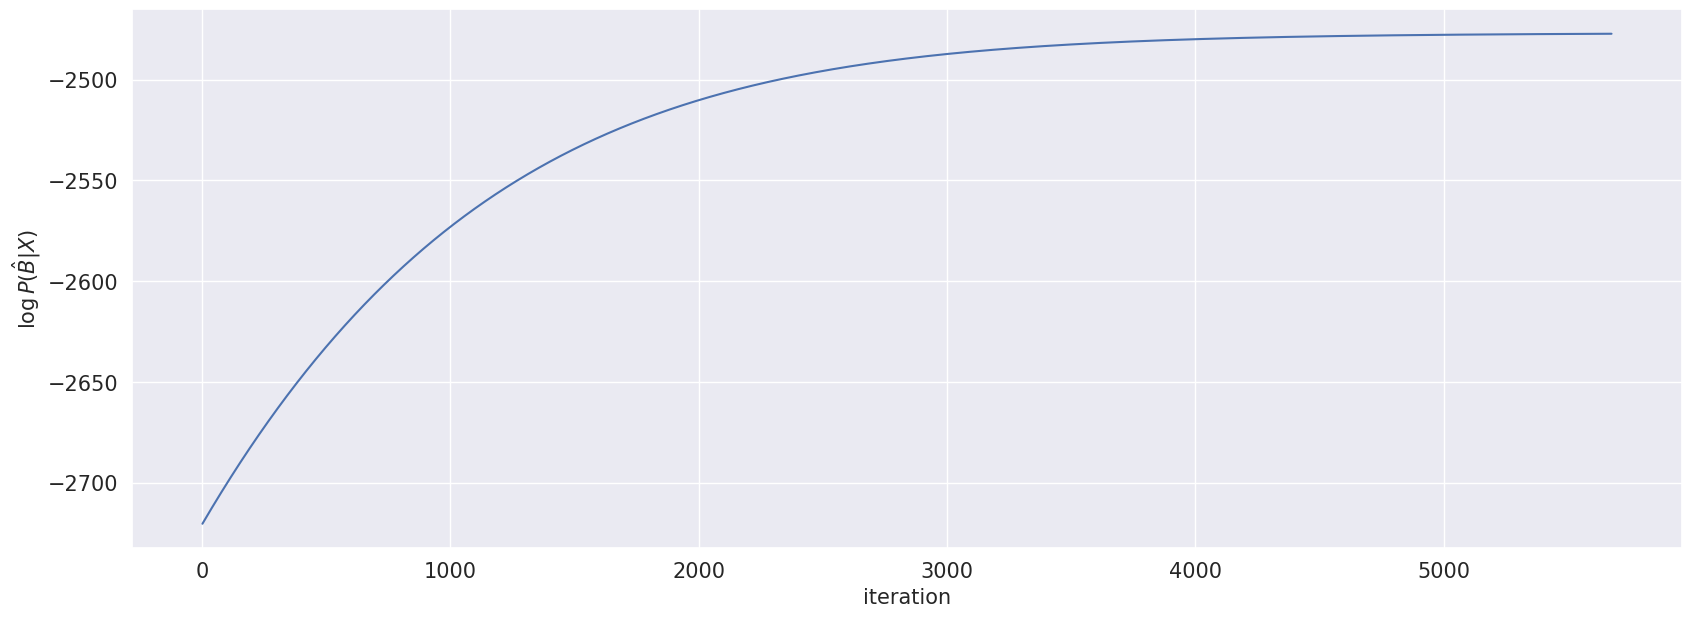

In [97]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 3.3.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


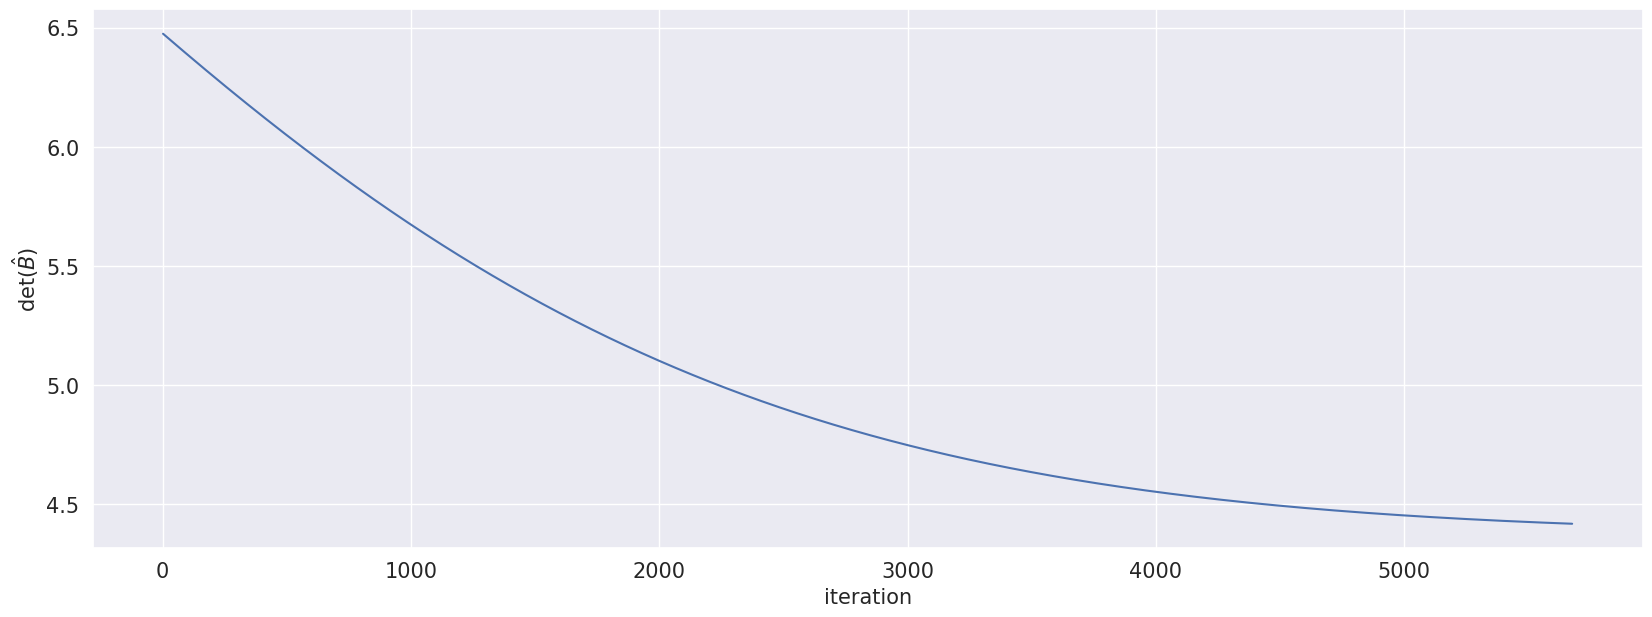

In [98]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 3.3.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


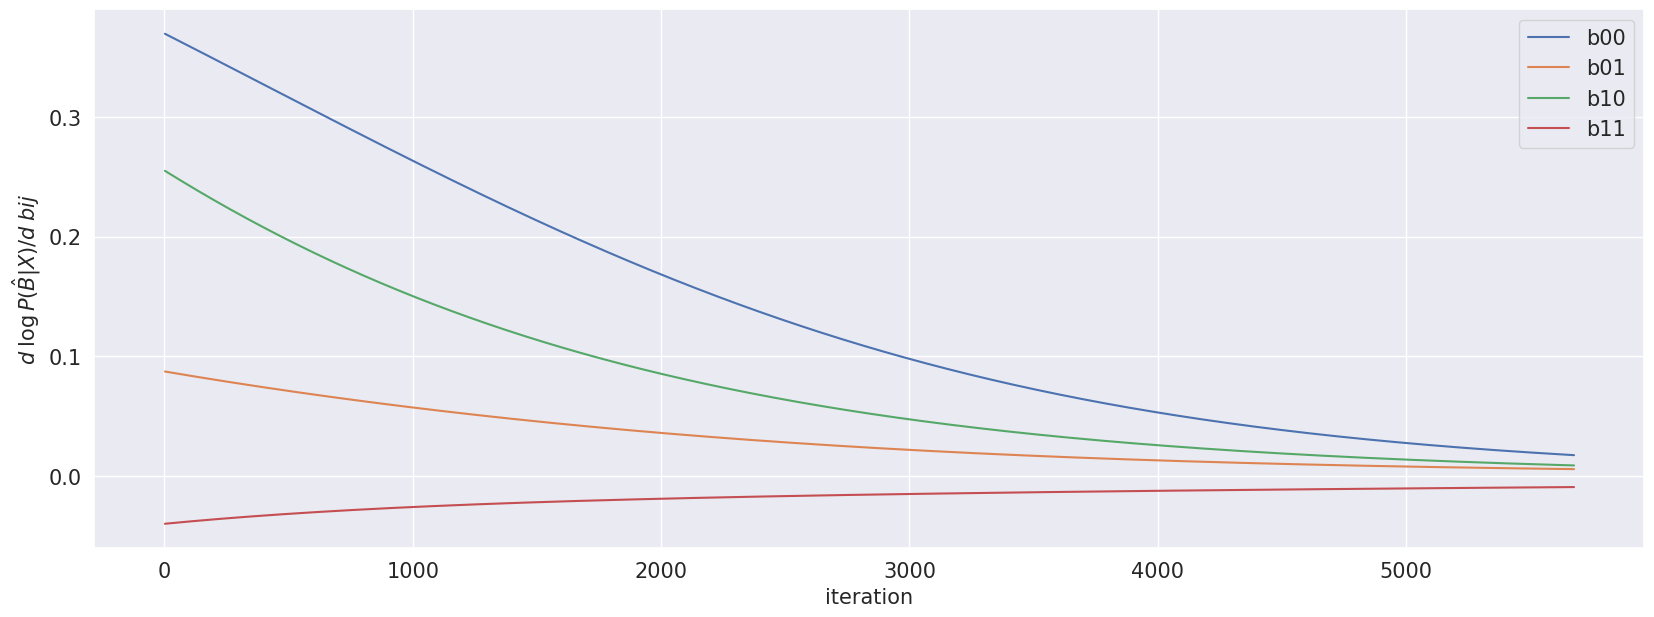

In [99]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 3.3.6. Plot source separation results

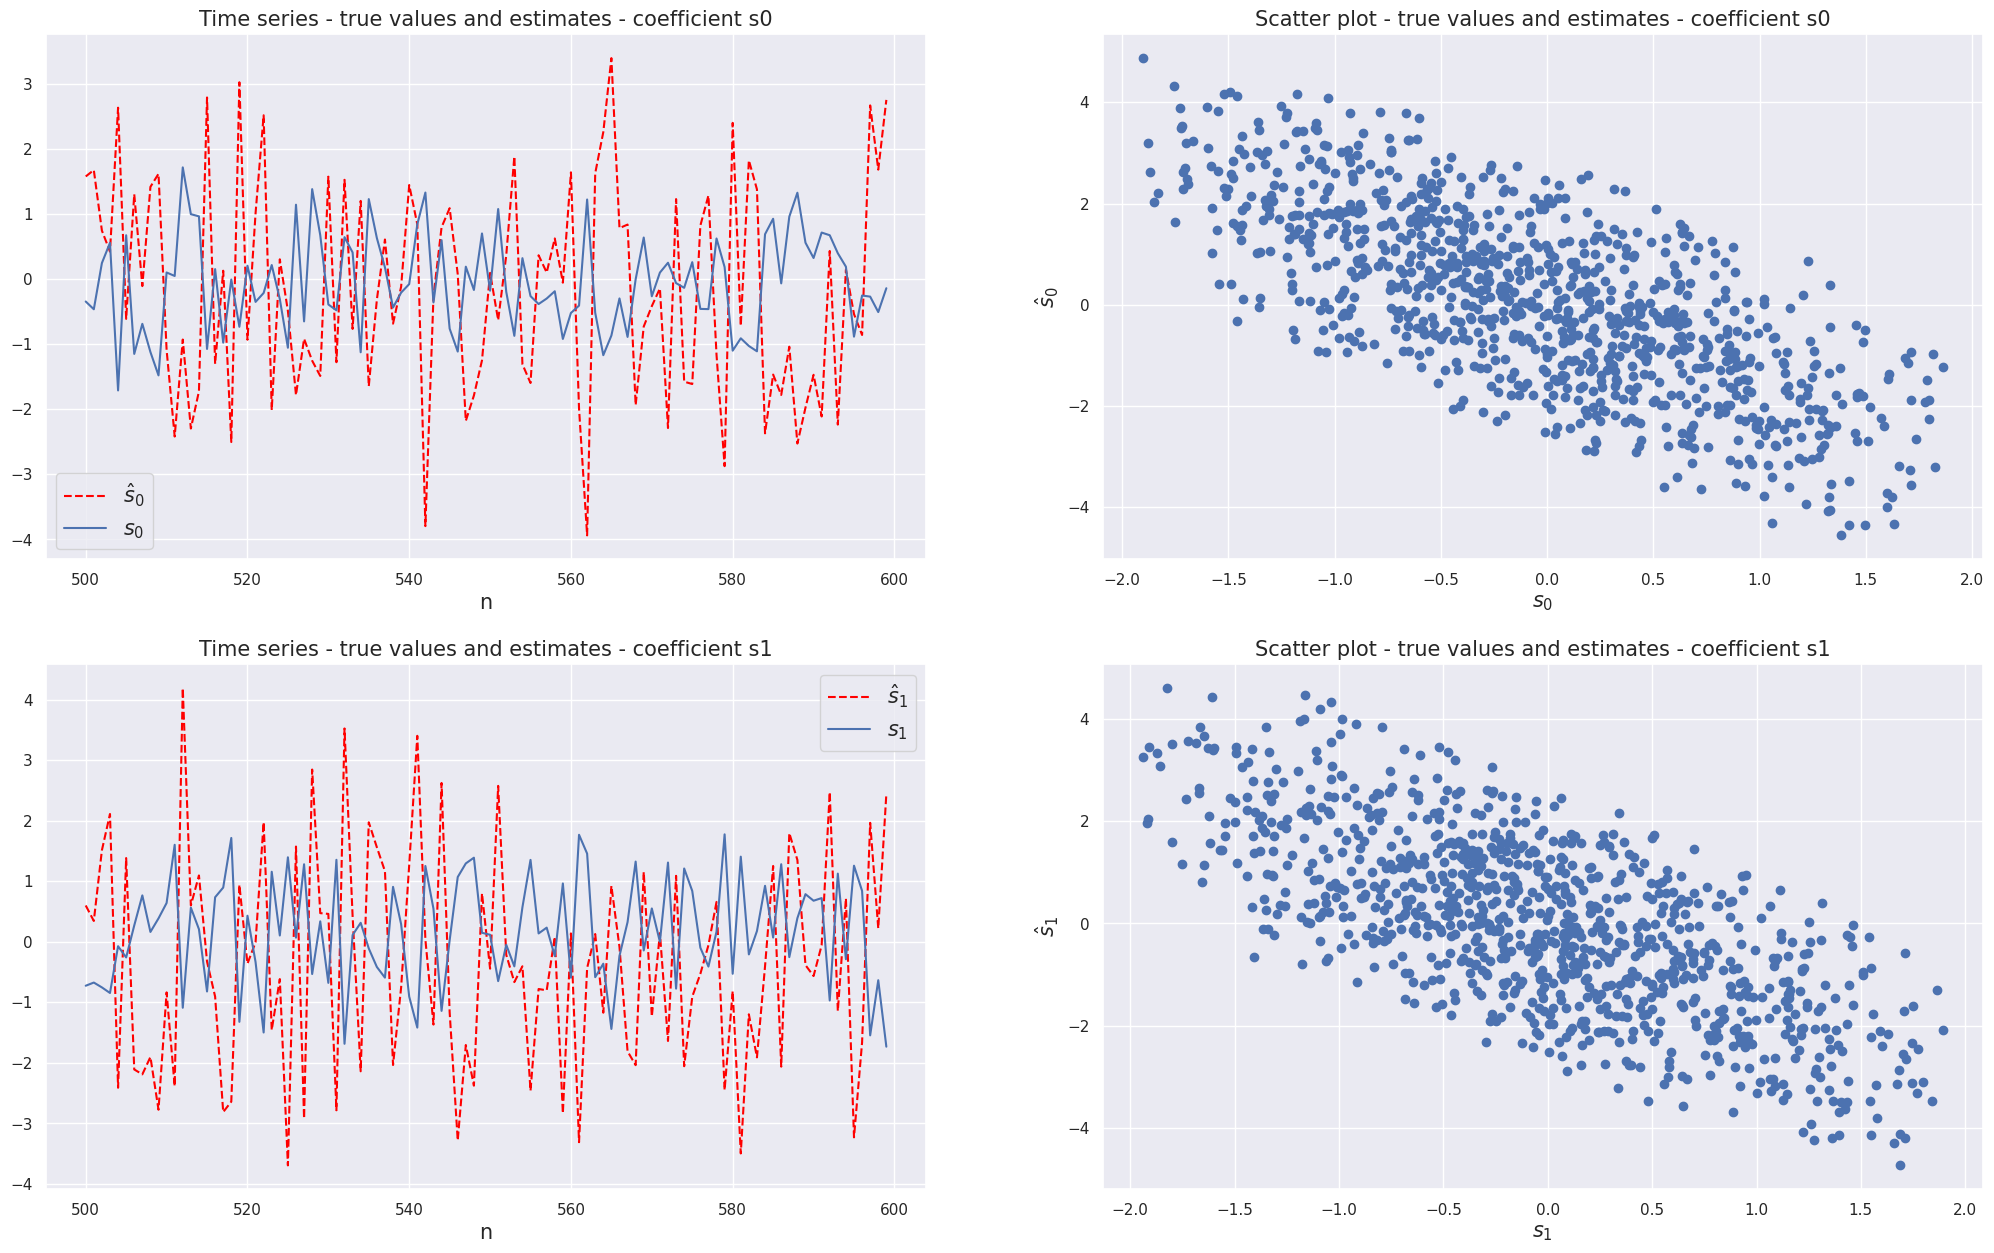

In [100]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [101]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.05319839292003338


## 3.4. Perform Analysis - DETERMINANT PRIOR
#### Prior:
$p(\boldsymbol{B}) \varpropto \exp \left[ -\frac{1}{2 \sigma^{2}} (det(\boldsymbol{B}) - 1)^2 \right]$

### 3.4.1 Execute Gradient Ascent Optimization

In [102]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])

def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    sig=1
    desired_det=1
    return (1/np.sqrt(2*np.pi*np.square(sig)))*np.exp(-np.square(np.linalg.det(X)-desired_det)/(2*np.square(sig)))

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    sig=1
    return -1*prior_pdf(X)*(np.linalg.det(X)-1)/np.square(sig)

In [103]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'determinant_prior'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 231 ms, sys: 14 ms, total: 245 ms
Wall time: 8min 23s


### 3.4.2. Parse Optimization Results

In [104]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [105]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[ 0.29511323 -2.73782585]
 [ 1.21490083  0.73262365]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [106]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-3323.4494909617474,
 -3163.2611262302885,
 -2771.853662809276,
 -2503.5153005945713,
 -2729.3070914048576,
 -inf,
 -2540.2493630003546,
 -2542.1152885571473,
 -2702.7118777308515,
 -2505.1293032324697]

In [107]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 1.66855619,  1.5042846 ],
        [ 1.23964237, -0.19026173]]),
 array([[ 1.83697653, -0.92141764],
        [-0.48947219, -0.81483795]]),
 array([[-1.03864945,  1.7577573 ],
        [-1.71416658, -0.80692392]]),
 array([[ 0.29511323, -2.73782585],
        [ 1.21490083,  0.73262365]]),
 array([[4.65577642e+56, 4.65577642e+56],
        [4.65577642e+56, 4.65577642e+56]]),
 array([[-inf, -inf],
        [-inf, -inf]]),
 array([[-0.09429903,  2.27508415],
        [-1.51594531, -0.11845665]]),
 array([[-0.90231864,  1.79844011],
        [-1.20553333, -1.55485091]]),
 array([[551.68704852, 553.41391698],
        [553.4499911 , 554.76916976]]),
 array([[-0.74281071, -2.49919274],
        [ 1.11890762, -1.22018083]])]

### 3.4.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


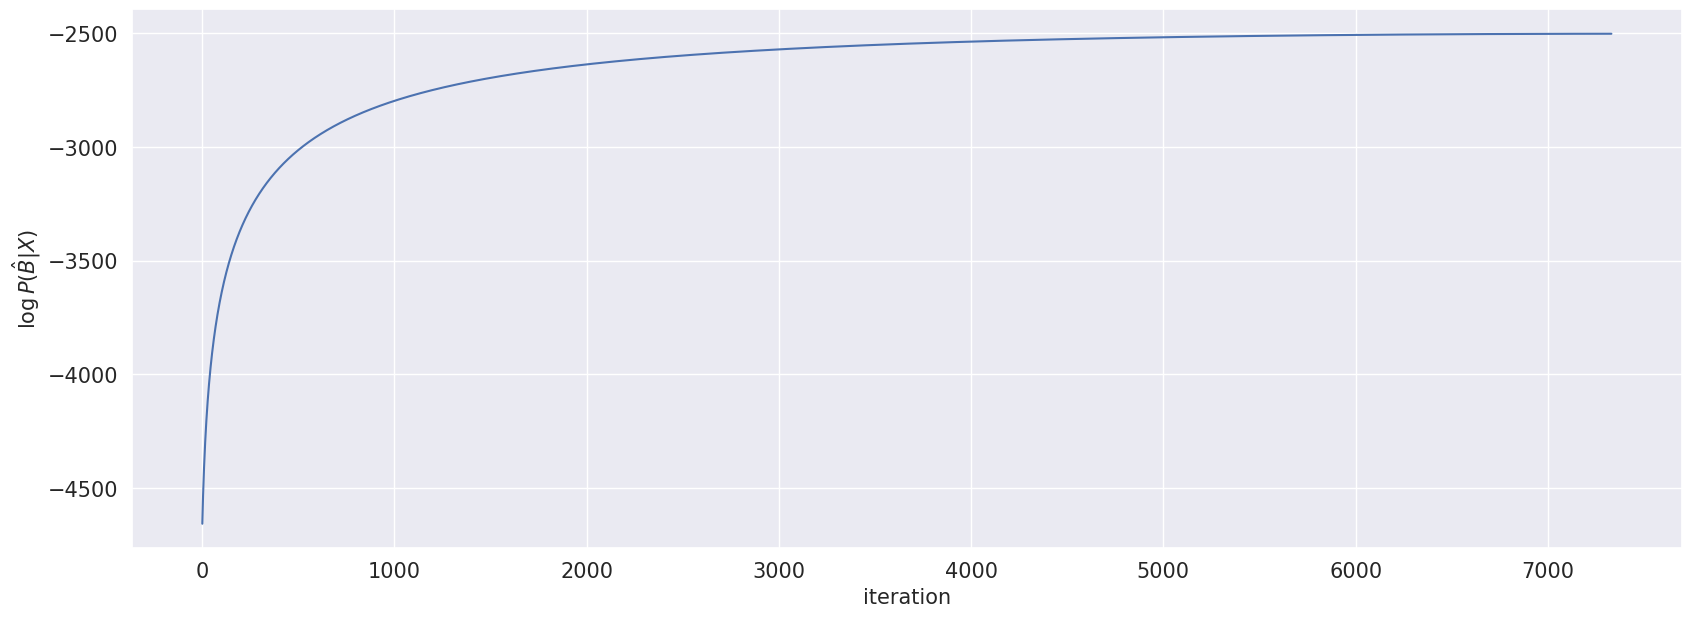

In [108]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 3.4.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


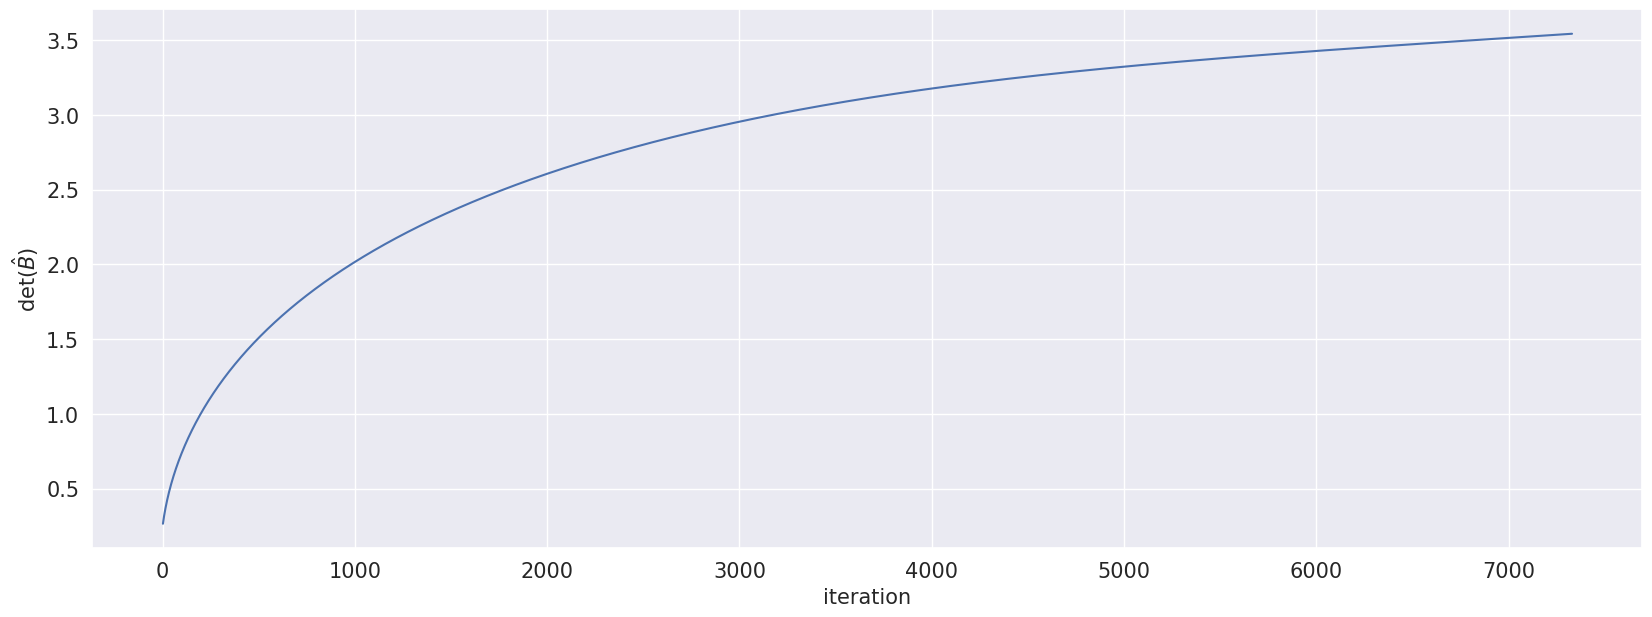

In [109]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 3.4.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


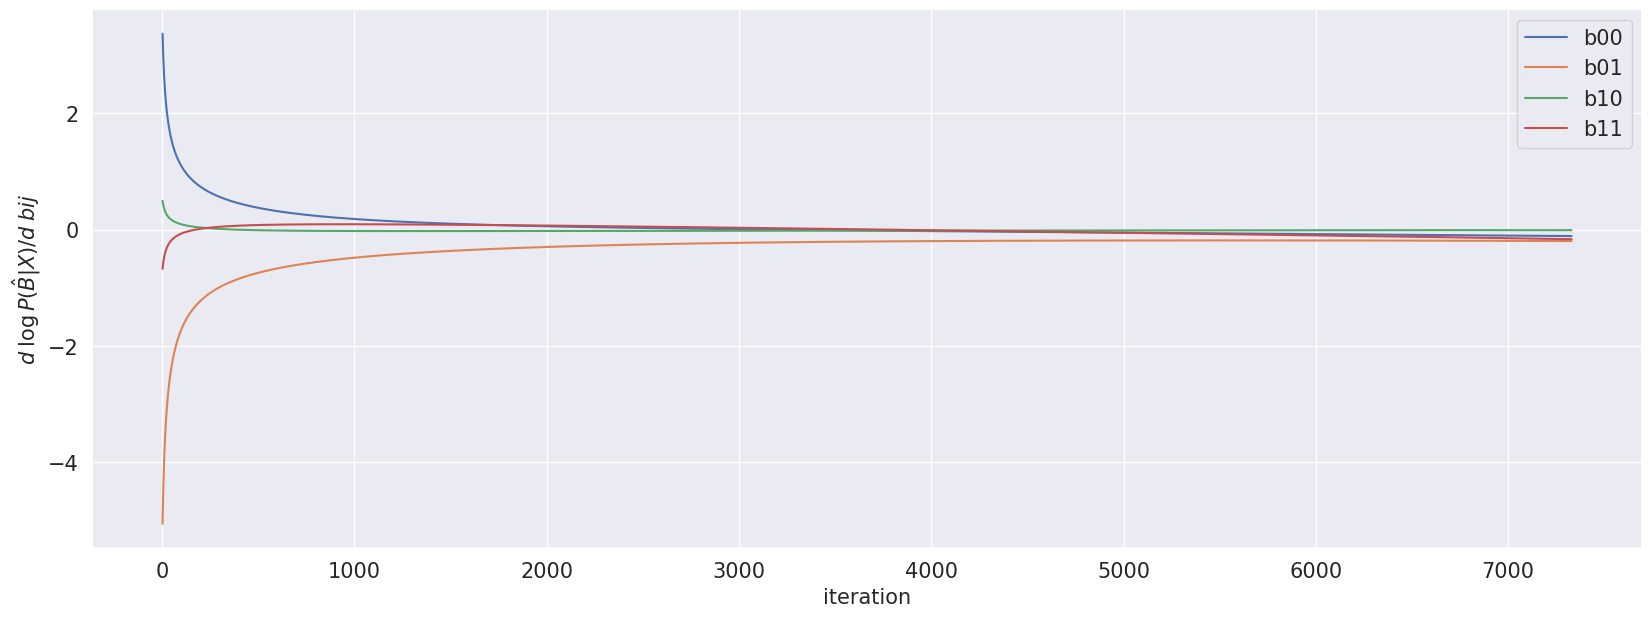

In [110]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 3.4.6. Plot source separation results

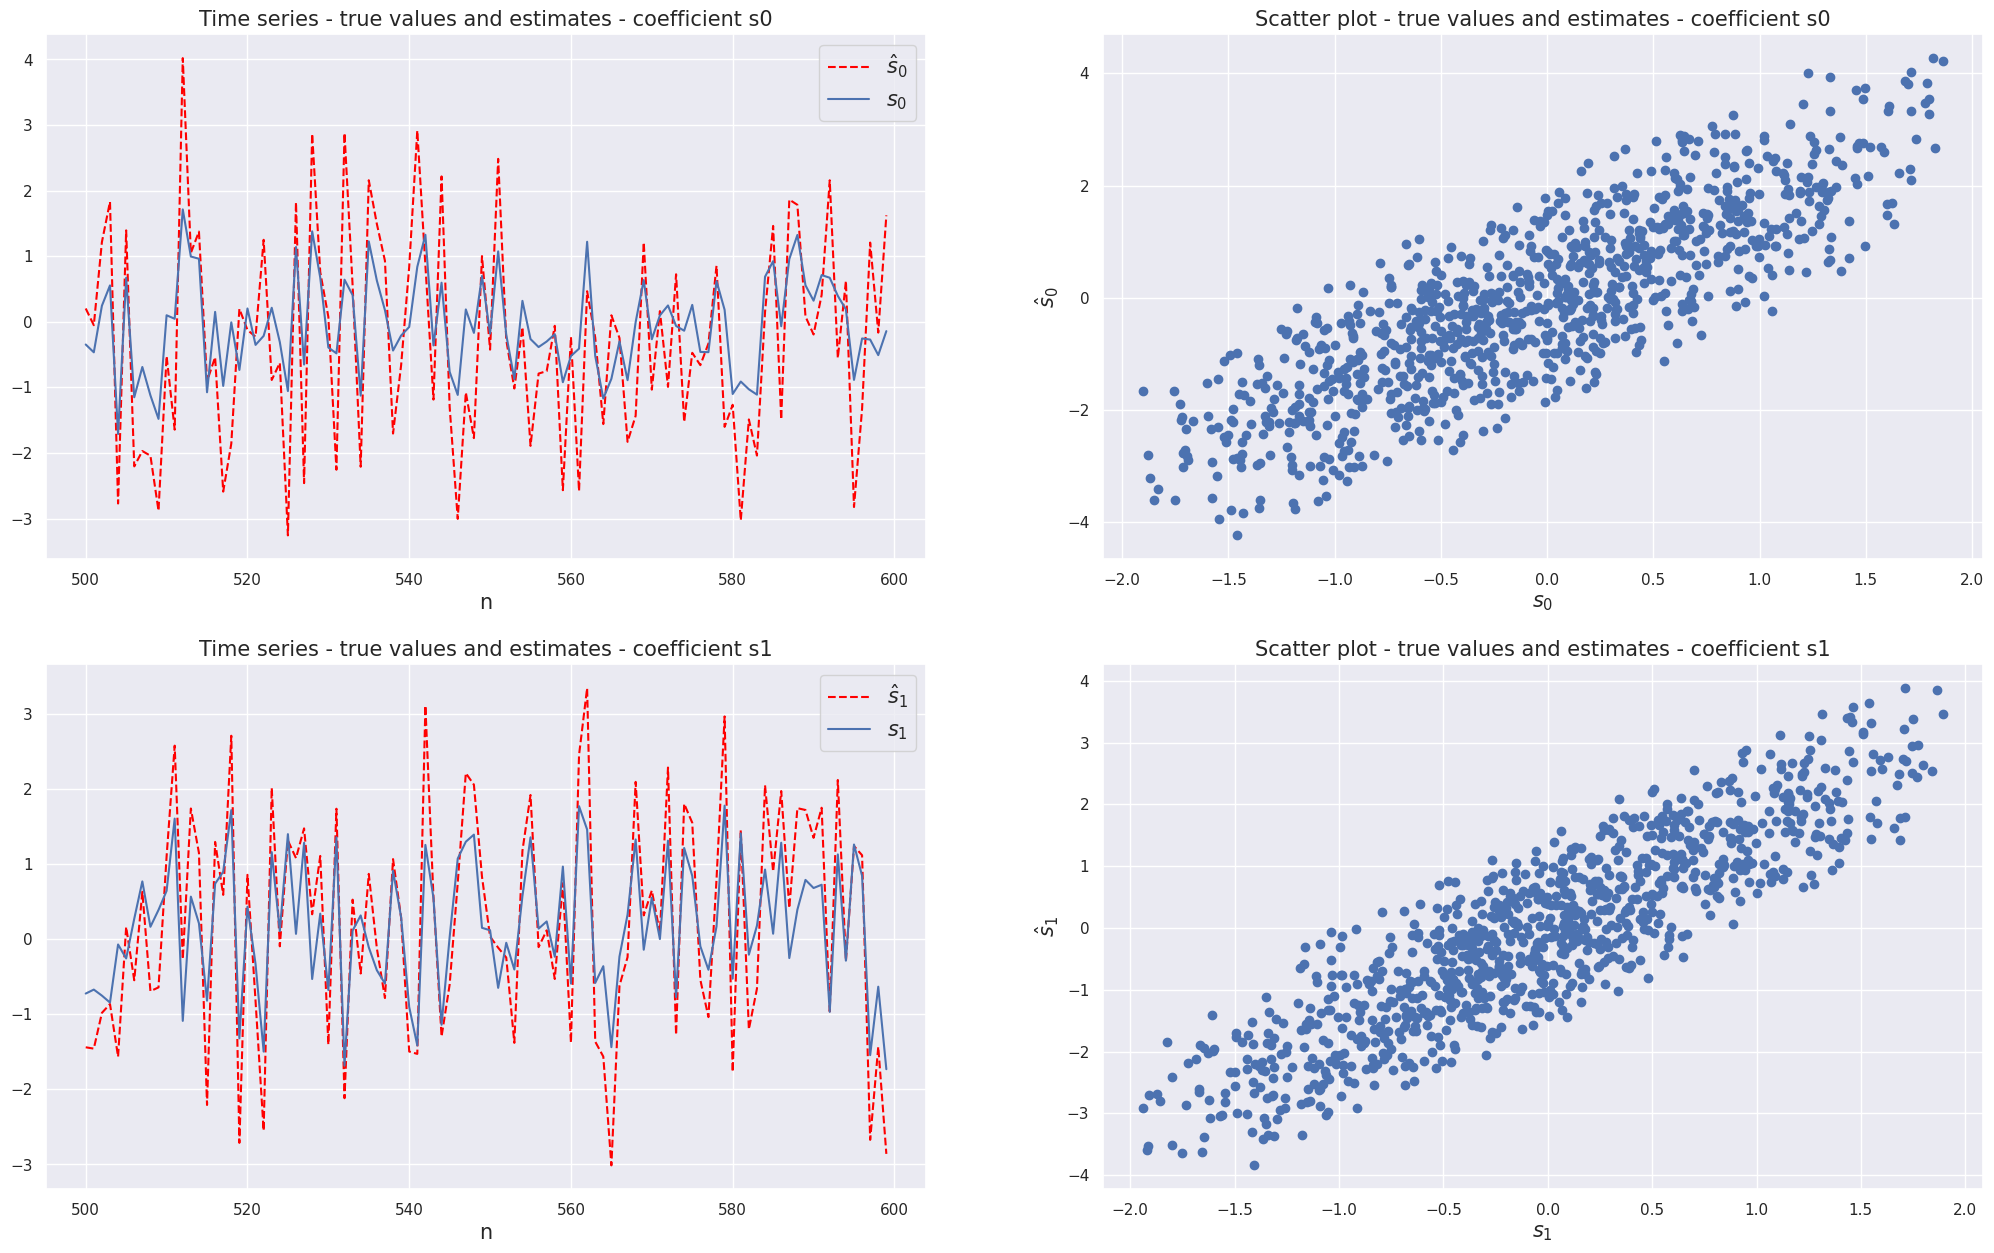

In [111]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [112]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.021025489828434073


## 3.5. Perform Analysis - near-identity transformation
#### Prior:
#### $p(\boldsymbol{B}) \varpropto \exp \left[ -\frac{1}{2 \sigma^{2}} ||\boldsymbol{B} - \boldsymbol{I}||^2 \right]$

### 3.5.1 Execute Gradient Ascent Optimization

In [113]:
def source_pdf(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
    """
    return np.exp(-x)/np.square(1+np.exp(-x))

def source_pdf_derivative(x):
    """
        This method takes SCALAR value x and return SCALAR source pdf derivative evaluated at x.
    """
    return (2*np.exp(-2*x)*(1+np.exp(-x)) - np.exp(-x)*np.square(1+np.exp(-x)))/np.power([1+np.exp(-x)],[4])

def prior_pdf(X):
    """
        This method takes VECTOR value X and return SCALAR prior pdf evaluated at X.
    """
    sig=1
    return np.exp(
        (-1/2/np.square(sig))*np.linalg.norm(X-np.eye(X.shape[0]))
    )

def prior_pdf_derivative(X):
    """
        This method takes VECTOR value x and return VECTOR prior pdf derivative evaluated at X.
    """
    sig=1
    der_X=np.empty(X.shape)
    I=np.eye(X.shape[0])
    for i, j in np.ndindex(X.shape):
        der_X[i, j] = prior_pdf(X)*(-1/np.square(sig))*(X[i,j]-I[i,j])
    return der_X

In [114]:
%%time

# Create folder for combination of model specification + prior
combination_dir = model_dir / 'identity_transformation'
if CREATE_FOLDER_STRUCTURE:
    if not combination_dir.is_dir():
        combination_dir.mkdir()

if EXECUTE_OPTIMIZATION:
    # Initialize estimator
    estimator = MAPGradientAscentEstimator(
        learning_rate=LEARNING_RATE,
        thresh=STOPPING_THRESH,
        max_it=MAX_IT,
        source_pdf=source_pdf,
        source_pdf_derivative=source_pdf_derivative,
        prior_pdf=prior_pdf,
        prior_pdf_derivative=prior_pdf_derivative,
        is_natural_gradient=False
    )

    # Run optimization
    estimator.fit(
        s=s,
        x=x,
        initial_condition=initial_B,
        n_jobs=N_WORKERS
    )

    # Save artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('wb') as f:
        pickle.dump(estimator, f)
else:
    # Read artifact
    with (combination_dir / 'GradientAscent_Estimator.pkl').open('rb') as f:
        estimator=pickle.load(f)
    

CPU times: user 1.09 s, sys: 35.3 ms, total: 1.12 s
Wall time: 33min 4s


### 3.5.2. Parse Optimization Results

In [115]:
# Get results for analyzed model (best model by default)
analyzed_model_idx = estimator.B_est_idx
# analyzed_model_idx=0
B_est = estimator.gradient_ascent_results[analyzed_model_idx]['B_est']
s_est = B_est@x
logs = estimator.gradient_ascent_results[analyzed_model_idx]['logs']

In [116]:
print('-'*100)
print('Estimated B:\n{}'.format(B_est))
print('True B:\n{}'.format(np.linalg.inv(A)))
print('-'*100)

----------------------------------------------------------------------------------------------------
Estimated B:
[[ 0.08485474  2.86756549]
 [-1.43238719  0.15918144]]
True B:
[[ 0.5 -1. ]
 [ 0.5  1. ]]
----------------------------------------------------------------------------------------------------


In [117]:
# Posteriors
[r['max_posterior'] for r in estimator.gradient_ascent_results]

[-2489.7415789011275,
 -2485.8882578790603,
 -2486.023028867276,
 -2489.8155852257073,
 -2483.251740993305,
 -2482.5531477817253,
 -2481.2673869598066,
 -2493.621995843914,
 -2481.3153567614204,
 -2485.447413175001]

In [118]:
[r['B_est'] for r in estimator.gradient_ascent_results]

[array([[ 0.71820119,  2.46557601],
        [ 1.22636124, -1.43549168]]),
 array([[ 0.35873646, -2.76195568],
        [-1.3835823 , -0.73644317]]),
 array([[-0.33845646,  2.75917507],
        [-1.38490748, -0.73411245]]),
 array([[ 0.64181955, -2.54514995],
        [ 1.27338395,  1.33890984]]),
 array([[ 1.44115546,  0.06416648],
        [ 0.02509995, -2.82781585]]),
 array([[-1.45810775,  0.00357454],
        [-0.04017719, -2.86240136]]),
 array([[ 0.08485474,  2.86756549],
        [-1.43238719,  0.15918144]]),
 array([[-0.73389102,  2.37946535],
        [-1.20215586, -1.52300378]]),
 array([[-1.4008863 ,  0.57364618],
        [ 0.27700357,  2.84069549]]),
 array([[-0.45542313, -2.69266385],
        [ 1.347834  , -0.95247243]])]

### 3.5.3. Plot log-posterior evolution

----------------------------------------------------------------------------------------------------
Evolution of log-posterior
----------------------------------------------------------------------------------------------------


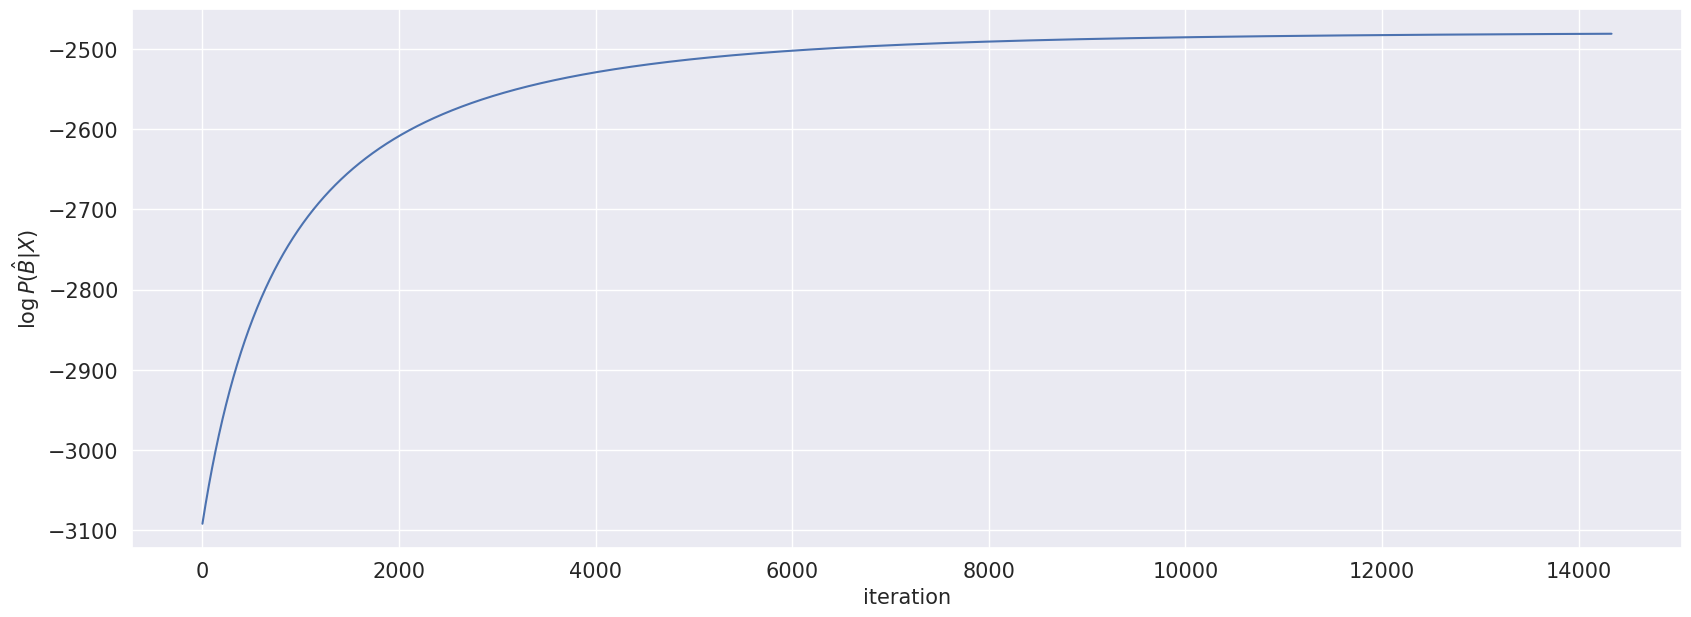

In [119]:
MAPGradientAscentGraphPlotter.evolution_log_posterior(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 3.5.4. Plot evolution of estimated B determinant

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


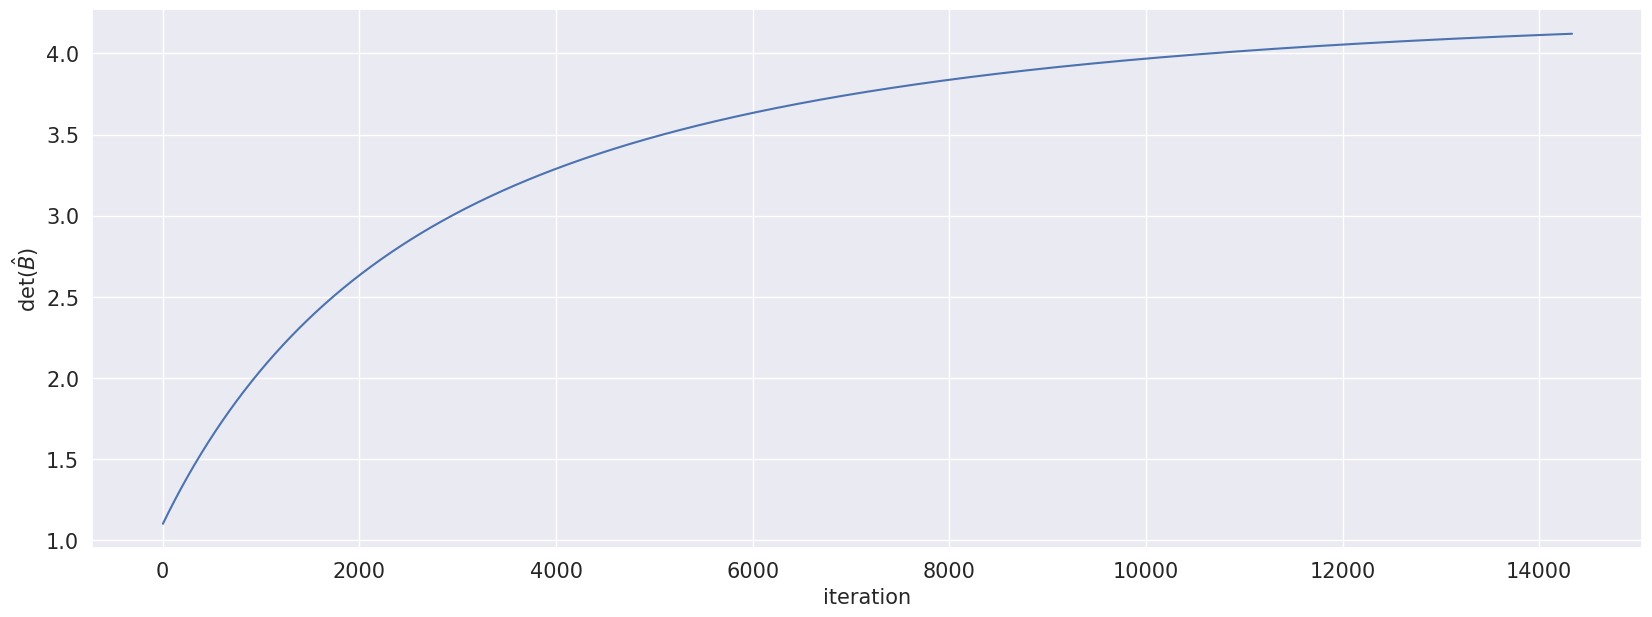

In [120]:
MAPGradientAscentGraphPlotter.evolution_Best_determinant(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
)

### 3.5.5. Plot evolution of derivative matrix

----------------------------------------------------------------------------------------------------
Evolução do determinante de B ao longo das iterações
----------------------------------------------------------------------------------------------------


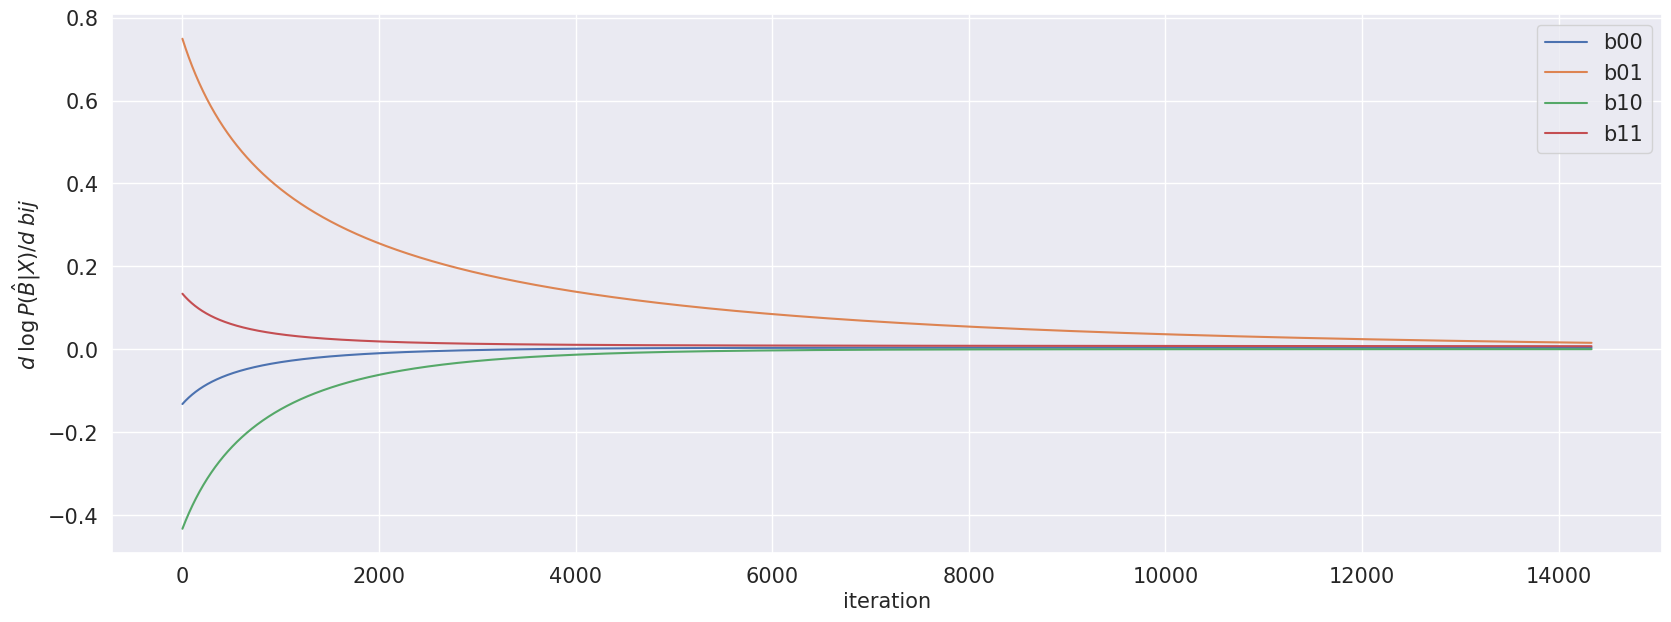

In [121]:
MAPGradientAscentGraphPlotter.evolution_Best_derivative(
    logs=logs,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    B_est=B_est
)

### 3.5.6. Plot source separation results

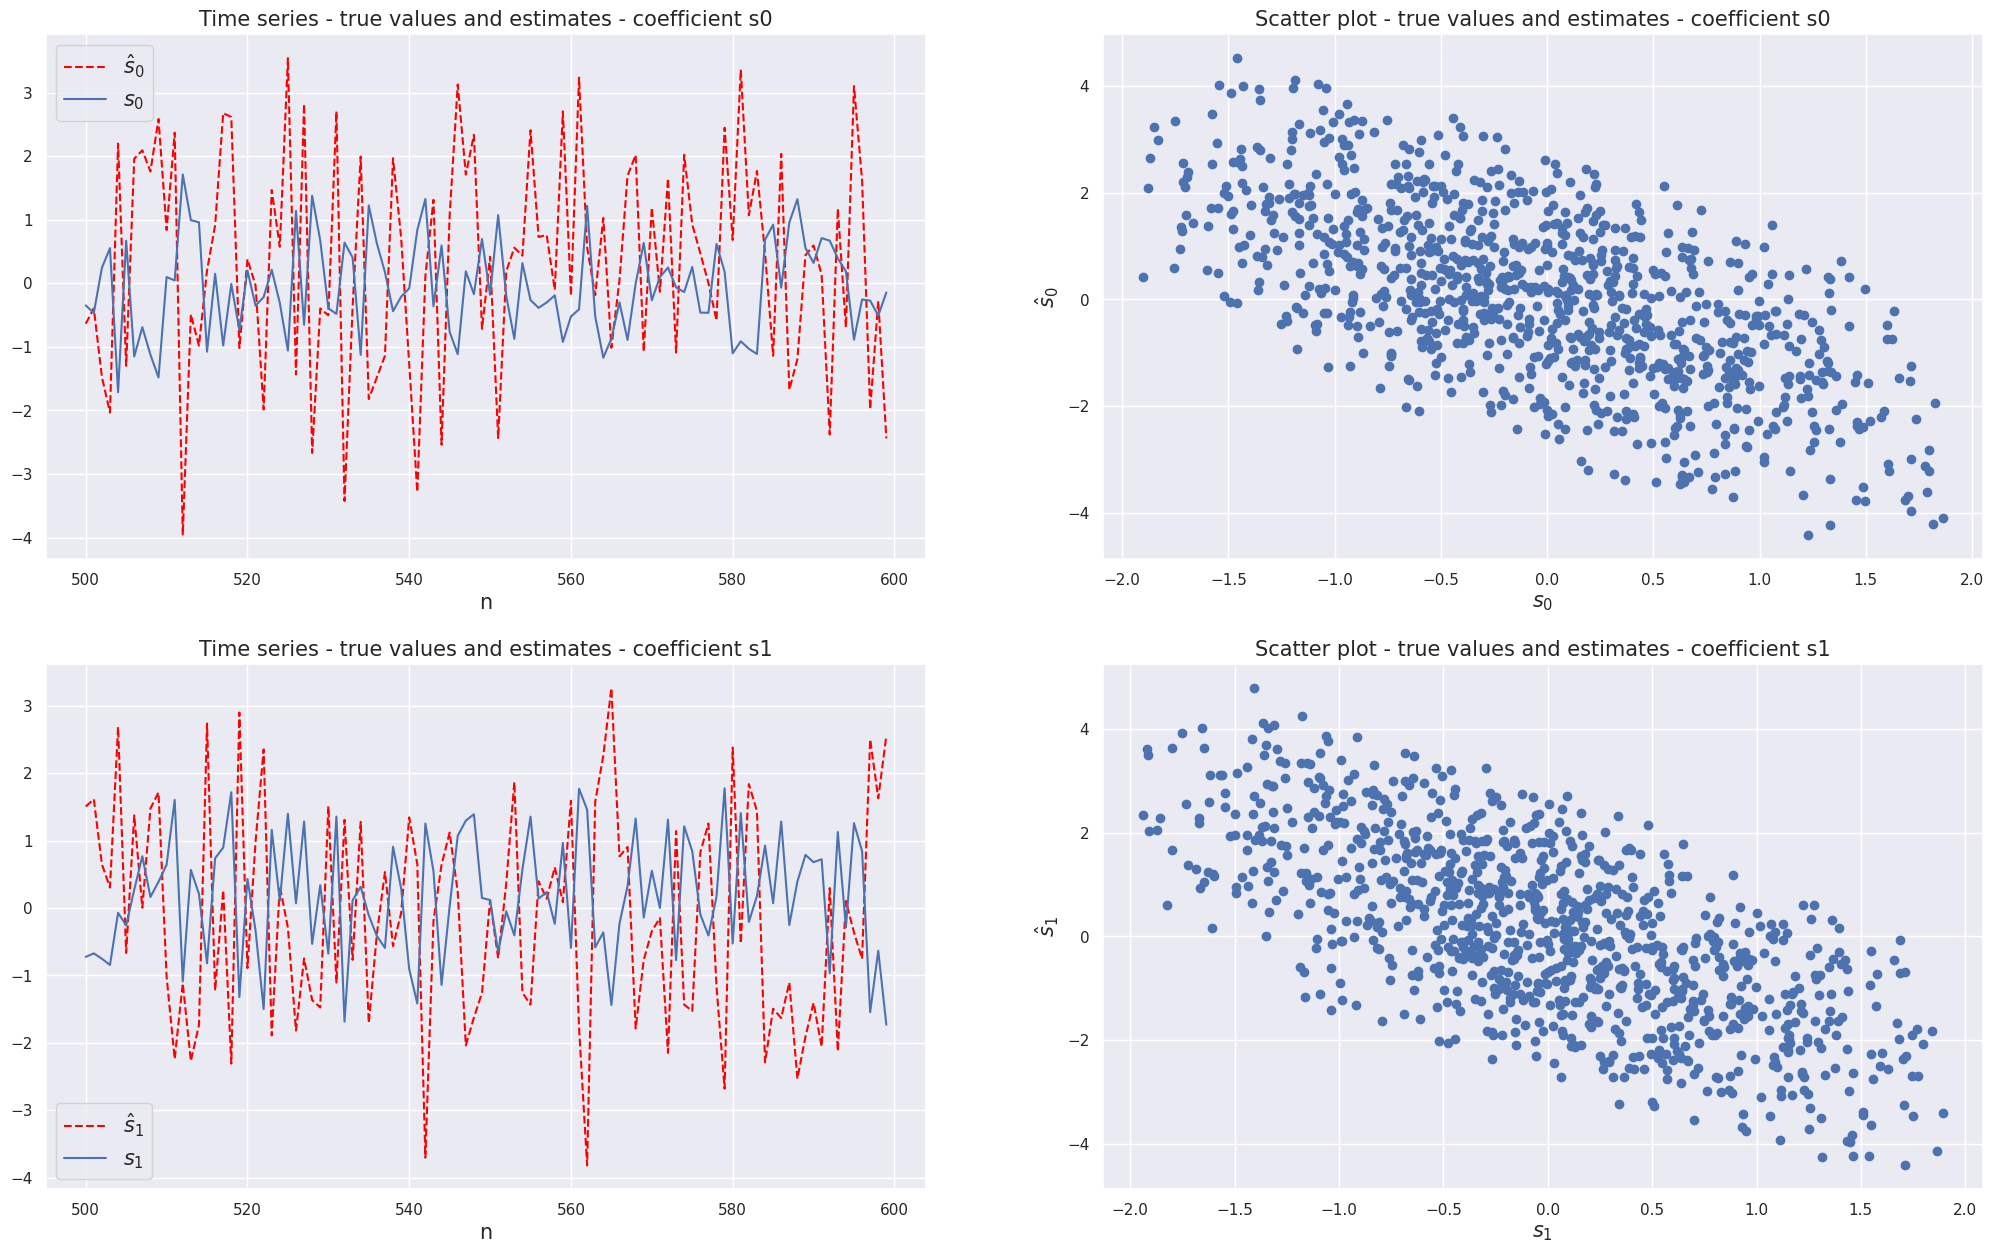

In [122]:
NPOINTS=100
PLOT_START=NOBS//2
PLOT_END=PLOT_START+NPOINTS

MAPGradientAscentGraphPlotter.source_separation_results(
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    B_est=B_est,
    s=s,
    s_est=s_est,
    x=x,
    nobs=NOBS,
    save_dir=combination_dir if SAVE_GRAPHS else None,
    ylims=None,
    label_size=15,
    tick_size=15,
    legend_size=15
)

In [123]:
# Error norm
err=np.linalg.norm(
    np.subtract(s,s_est)
)/np.size(s)

# Log error
errors['perfect_model']['likelihood'] = err

print('Norma do erro de estimação: {}'.format(err))

Norma do erro de estimação: 0.05127238984776549


# 4. SAVE ERRORS ARTIFACT

In [124]:
# Save errors, if new execution was made
if EXECUTE_OPTIMIZATION:
    with (experiment_dir / 'errors.pkl').open('wb') as f:
        pickle.dump(errors, f)
errors

{'perfect_model': {'likelihood': 0.05127238984776549},
 'slightly_misspecified_model': {}}